### Packages

In [371]:
import numpy as np
import pandas as pd
import datetime
import pandas_datareader.data as web
import re
from arch import arch_model
from typing import Union

# R packages
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, r, globalenv, default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.vectors import StrVector

base = importr('base')
methods = importr('methods')
rugarch = importr('rugarch')
rmgarch = importr('rmgarch')

Matplotlib settings

In [372]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False

mpl.rcParams.update({
    # Fonts + sizes
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # Lines / axes / legend
    "axes.linewidth": 0.7,
    "lines.linewidth": 0.6,
    "legend.frameon": True,
    "axes.xmargin":(0.02),

    # Grid style (but not on/off)
    "axes.grid": False,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
})

# Output folder (created once)
FIG_DIR = Path("./Outputs/Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Canonical sizes for your LaTeX document
FIG_FULL = (6.5, 3.2)   # ~ \textwidth
FIG_HALF = (3.2, 2.4)   # ~ 0.49\textwidth (two side-by-side)

%config InlineBackend.figure_format = 'retina'
mpl.rcParams["figure.dpi"] = 160      # bigger/sharper in notebook
mpl.rcParams["savefig.dpi"] = 300     # only affects PNG exports, PDF unaffected

### Data collection & initial visualization

Collect G-SIBs, O-SIIs and MSCI World/Europe Banks data from Data request file.

In [373]:
# Load the Excel file with multiple sheets from the Data folder
excel_file = pd.ExcelFile('./Data GSIBs OSIIs fase 1.xlsx', engine='openpyxl')

# Display the sheet names to understand the structure of the file
print("Sheet names:", excel_file.sheet_names)

# Load all sheets into separate DataFrames
GSIBs = excel_file.parse('G-SIBs')
OSIIs = excel_file.parse('O-SIIs')
GSIBs_prices = excel_file.parse('G-SIBs Price')
GSIBs_equity = excel_file.parse('G-SIBs Marktwaarde')
GSIBs_liabilities = excel_file.parse('G-SIBs Liabilities')
GSIBs_assets = excel_file.parse('G-SIBs Assets')
OSIIs_prices = excel_file.parse('O-SIIs Price')
OSIIs_equity = excel_file.parse('O-SIIs Marktwaarde')
OSIIs_liabilities = excel_file.parse('O-SIIs Liabilities')
OSIIs_assets = excel_file.parse('O-SIIs Assets')
MSCI_indices = excel_file.parse('MSCI Indices')

# Set 'DATE' as the index for prices, equity, and MSCI Indices dataframes
GSIBs_prices.set_index('DATE', inplace=True)
GSIBs_equity.set_index('DATE', inplace=True)
OSIIs_prices.set_index('DATE', inplace=True)
OSIIs_equity.set_index('DATE', inplace=True)
MSCI_indices.set_index('DATE', inplace=True)

# For the sheets with the first column 'PERIOD', convert 'PERIOD' to datetime
def period_to_quarter_end(s: str) -> Union[pd.Timestamp, pd.NaT]:
    """
    Parse strings like 'Q1 2008' → quarter-end timestamp.
    Assumes calendar quarters (Q-DEC). If your data uses fiscal quarters,
    adjust freq (e.g., 'Q-MAR' or 'Q-JUN').
    """
    if not isinstance(s, str):
        return pd.NaT
    m = re.match(r'^Q([1-4])\s+(\d{4})$', s.strip())
    if not m:
        return pd.NaT
    q = int(m.group(1))
    y = int(m.group(2))
    # Calendar year with quarter ending in Dec (Mar/Jun/Sep/Dec quarters):
    p = pd.Period(f'{y}Q{q}', freq='Q-DEC')
    return p.to_timestamp(how='end')  # quarter end (e.g., 2008-03-31)

# Apply the conversion to the 'PERIOD' column and set it as the index for liabilities and assets dataframes
GSIBs_liabilities['PERIOD'] = GSIBs_liabilities['PERIOD'].apply(period_to_quarter_end)
GSIBs_liabilities.set_index('PERIOD', inplace=True)

GSIBs_assets['PERIOD'] = GSIBs_assets['PERIOD'].apply(period_to_quarter_end)
GSIBs_assets.set_index('PERIOD', inplace=True)

OSIIs_liabilities['PERIOD'] = OSIIs_liabilities['PERIOD'].apply(period_to_quarter_end)
OSIIs_liabilities.set_index('PERIOD', inplace=True)

OSIIs_assets['PERIOD'] = OSIIs_assets['PERIOD'].apply(period_to_quarter_end)
OSIIs_assets.set_index('PERIOD', inplace=True)

# Convert liabilities and assets from thousands to millions to match equity values
for df_name in ["GSIBs_liabilities", "GSIBs_assets", "OSIIs_liabilities", "OSIIs_assets"]:
    df = globals()[df_name]

    # ensure numeric where possible; non-numeric becomes NaN
    df = df.apply(pd.to_numeric, errors="coerce") / 1000

    globals()[df_name] = df

# Convert prices for UK banks from GBp to GBP by dividing by 100, banks in columns 14, 15, and 16
GSIBs_prices.iloc[:, 13:16] = GSIBs_prices.iloc[:, 13:16] / 100

# Reverse the dataframes to have the most recent dates first
GSIBs = GSIBs.iloc[::-1]
OSIIs = OSIIs.iloc[::-1]
GSIBs_prices = GSIBs_prices.iloc[::-1]
GSIBs_equity = GSIBs_equity.iloc[::-1]
GSIBs_liabilities = GSIBs_liabilities.iloc[::-1]
GSIBs_assets = GSIBs_assets.iloc[::-1]
OSIIs_prices = OSIIs_prices.iloc[::-1]
OSIIs_equity = OSIIs_equity.iloc[::-1]
OSIIs_liabilities = OSIIs_liabilities.iloc[::-1]
OSIIs_assets = OSIIs_assets.iloc[::-1]
MSCI_indices = MSCI_indices.iloc[::-1]

# Display the first few rows and columns of the GSIBs_prices dataframe
print("GSIBs_prices DataFrame (first 5 rows and columns):")
print(GSIBs_prices.iloc[:5, :5])

Sheet names: ['G-SIBs', 'O-SIIs', 'G-SIBs Price', 'G-SIBs Marktwaarde', 'G-SIBs Liabilities', 'G-SIBs Assets', 'O-SIIs Price', 'O-SIIs Marktwaarde', 'O-SIIs Liabilities', 'O-SIIs Assets', 'MSCI Indices']
GSIBs_prices DataFrame (first 5 rows and columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  \
DATE                                                            
2025-11-07                204.01            113.58      30.35   
2025-11-06                205.25            113.54      30.78   
2025-11-05                205.64            113.85      31.18   
2025-11-04                205.40            113.56      30.54   
2025-11-03                207.22            115.18      30.63   

            AGRICULTURAL BK.OF CHIN  BANK OF CHINA  
DATE                                                
2025-11-07                     6.09           4.58  
2025-11-06                     6.08           4.57  
2025-11-05                     6.11           4.53  
2025-11-04              

Visualize some of the data, specifically 10 relevant G-SIBs 

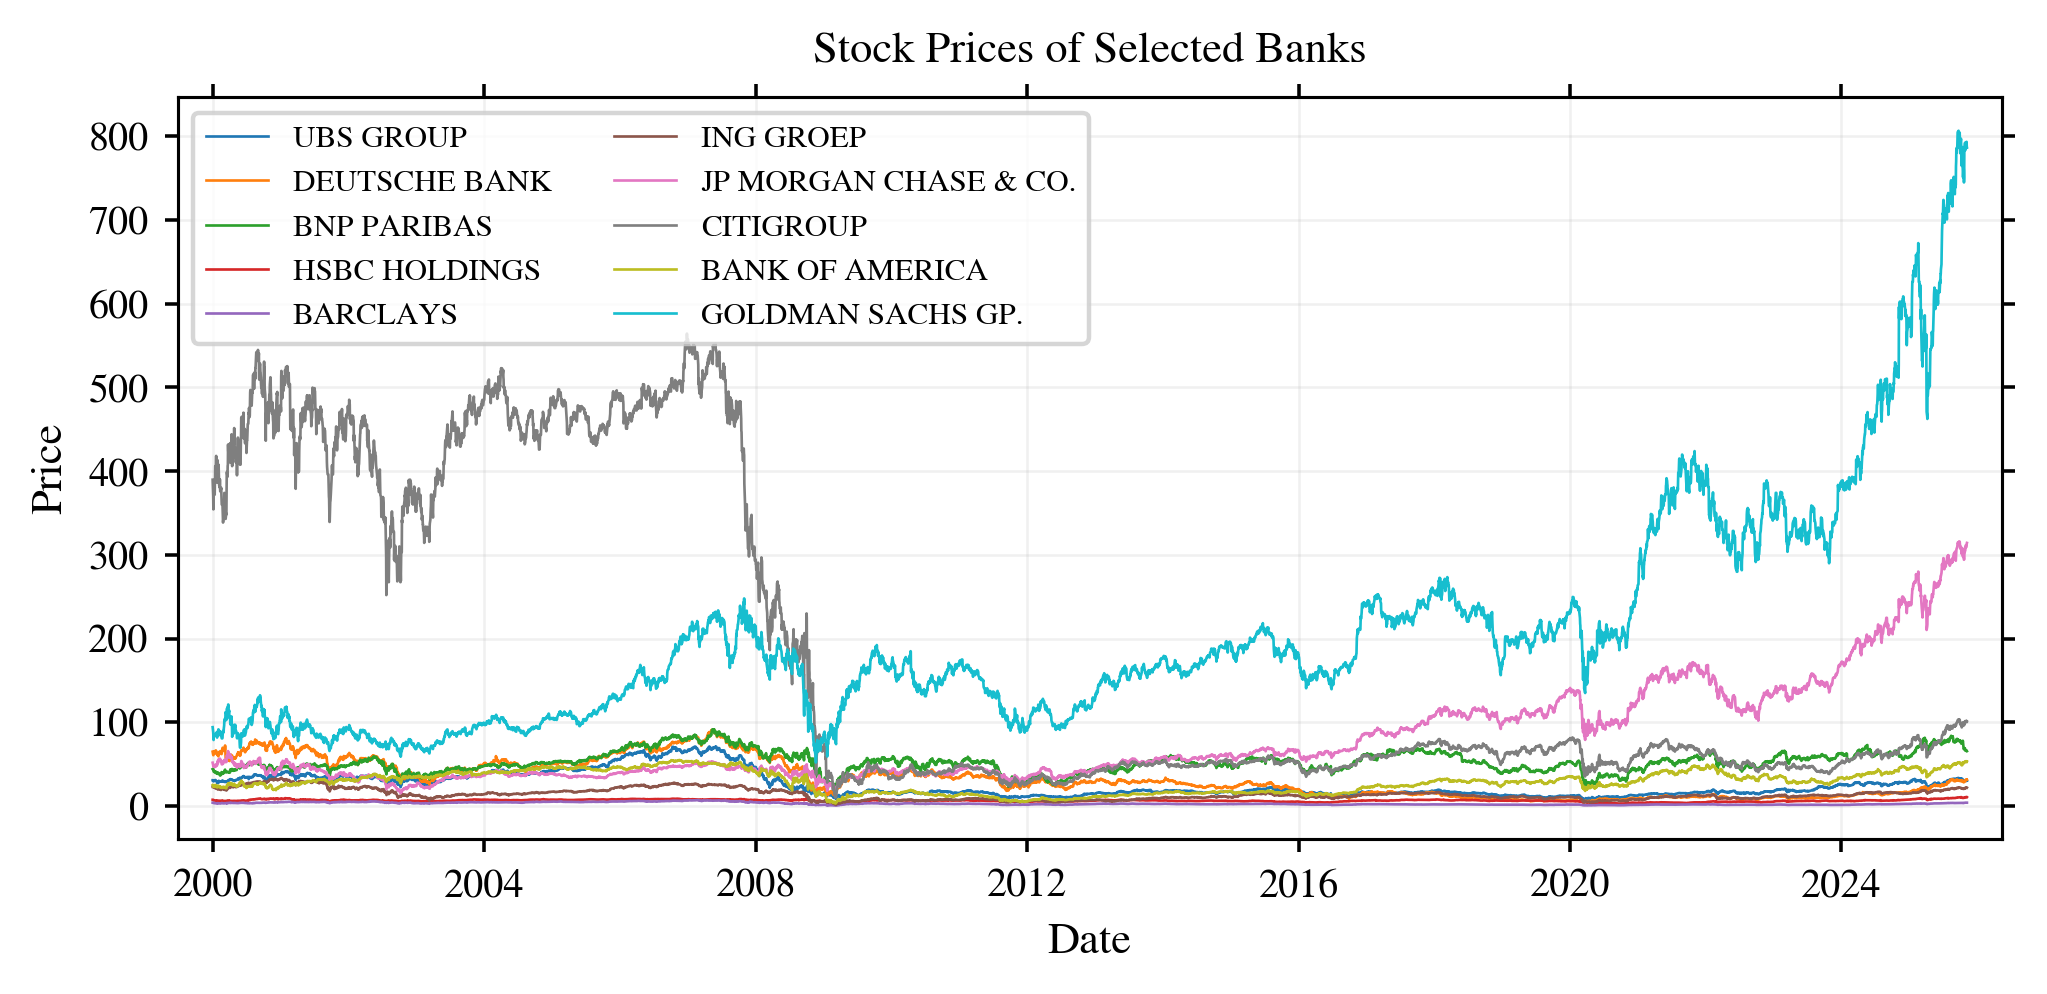

In [374]:
# Plot stock prices of selected banks
fig, ax = plt.subplots(figsize=FIG_FULL)

columns_to_plot = [2, 8, 10, 13, 14, 19, 20, 21, 22, 23]  # 0-based indexing

for col in columns_to_plot:
    ax.plot(
        GSIBs_prices.index,
        GSIBs_prices.iloc[:, col],
        label=GSIBs_prices.columns[col]
    )

ax.set_title("Stock Prices of Selected Banks", pad=8)
ax.set_xlabel("Date")
ax.set_ylabel("Price")

ax.legend(
    loc="upper left", fontsize=7,
    ncol=2,                 # helps with many banks
    frameon=True
)

# Explicit, intentional grid
ax.grid(True, axis="both", which="major")

ax.margins(x=0.02)

fig.tight_layout()
# fig.savefig(FIG_DIR / "fig_stock_prices_selected_banks.pdf")
plt.show()


### Data processing

Omit missing values and/or certain timeframes 

In [375]:
price_cols = set(GSIBs_prices.columns)

print("Missing in equity:", sorted(price_cols - set(GSIBs_equity.columns))[:50])
print("Missing in liabilities:", sorted(price_cols - set(GSIBs_liabilities.columns))[:50])

print("Extra in equity:", sorted(set(GSIBs_equity.columns) - price_cols)[:50])
print("Extra in liabilities:", sorted(set(GSIBs_liabilities.columns) - price_cols)[:50])



Missing in equity: []
Missing in liabilities: []
Extra in equity: []
Extra in liabilities: []


In [376]:
# Exclude GSIBs where the first observation is after 2008-01-01 or contains #N/A after 2008-01-01
initial_date = pd.Timestamp('2008-01-01')

# Replace '#N/A' with NaN for proper handling
GSIBs_prices.replace('#N/A', np.nan, inplace=True)

# Identify columns with #N/A (now NaN) after the initial_date
columns_with_na_after_date = GSIBs_prices.loc[GSIBs_prices.index > initial_date].isna().any()

# Exclude columns with #N/A after the initial_date
GSIBs_prices_omitted = GSIBs_prices.loc[:, ~columns_with_na_after_date]

# Omit the rows with any missing values across the GSIBs_prices_omitted dataframe
GSIBs_prices = GSIBs_prices_omitted.dropna(axis=0, how='any')

# Show the row numbers that were dropped
dropped_rows = GSIBs_prices_omitted.index.difference(GSIBs_prices.index)
print("Dropped row indices due to missing values:")
print(dropped_rows)

# Make sure the same columns are dropped from the related equity and liabilities dataframes
GSIBs_equity = GSIBs_equity[GSIBs_prices.columns]
GSIBs_liabilities = GSIBs_liabilities[GSIBs_prices.columns]

Dropped row indices due to missing values:
DatetimeIndex(['1999-12-31', '2000-01-03', '2000-01-04', '2000-01-05',
               '2000-01-06', '2000-01-07', '2000-01-10', '2000-01-11',
               '2000-01-12', '2000-01-13',
               ...
               '2006-10-13', '2006-10-16', '2006-10-17', '2006-10-18',
               '2006-10-19', '2006-10-20', '2006-10-23', '2006-10-24',
               '2006-10-25', '2006-10-26'],
              dtype='datetime64[ns]', name='DATE', length=1780, freq=None)


Add the MSCI World Banks Index to the start of the G-SIBs dataframe

In [377]:
# Extract the MSCI World index from the MSCI_indices dataframe
MSCI_World = MSCI_indices.iloc[:, 1] # Assuming the second column is MSCI World

# Drop the same rows from MSCI_World to align with GSIBs_prices
MSCI_World = MSCI_World.drop(index=dropped_rows)

# Verify alignment
assert GSIBs_prices.index.equals(MSCI_World.index), "Indices are not aligned!"
print("Indices are aligned after dropping rows.")

# Add MSCI_World to the first column of the GSIBs_prices dataframe if it doesn't already exist
if 'MSCI World' not in GSIBs_prices.columns:
    GSIBs_prices.insert(0, 'MSCI World', MSCI_World)

# Display the first few rows and columns of the cleaned GSIBs_prices dataframe
print("Cleaned GSIBs_prices DataFrame (first 10 rows and 4 columns):")
print(GSIBs_prices.iloc[:10, :4])

Indices are aligned after dropping rows.
Cleaned GSIBs_prices DataFrame (first 10 rows and 4 columns):
            MSCI World  ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP
DATE                                                                     
2025-11-07      179.74                204.01            113.58      30.35
2025-11-06      180.34                205.25            113.54      30.78
2025-11-05      179.48                205.64            113.85      31.18
2025-11-04      179.38                205.40            113.56      30.54
2025-11-03      179.59                207.22            115.18      30.63
2025-10-31      179.14                205.47            115.16      30.73
2025-10-30      178.33                204.12            114.64      30.68
2025-10-29      177.53                204.55            114.03      30.60
2025-10-28      177.72                207.80            115.29      30.92
2025-10-27      176.89                207.45            114.26      30.74


Compute returns

In [378]:
# Function to calculate percentage log returns for all columns in a DataFrame
def calculate_log_returns(df):
    return 100 * np.log(df / df.shift(1)).dropna()

# Calculate log returns for GSIBs and OSIIs including the MSCI indices
gsibs_returns = calculate_log_returns(GSIBs_prices)
osiis_returns = calculate_log_returns(OSIIs_prices)

Visualize some log returns

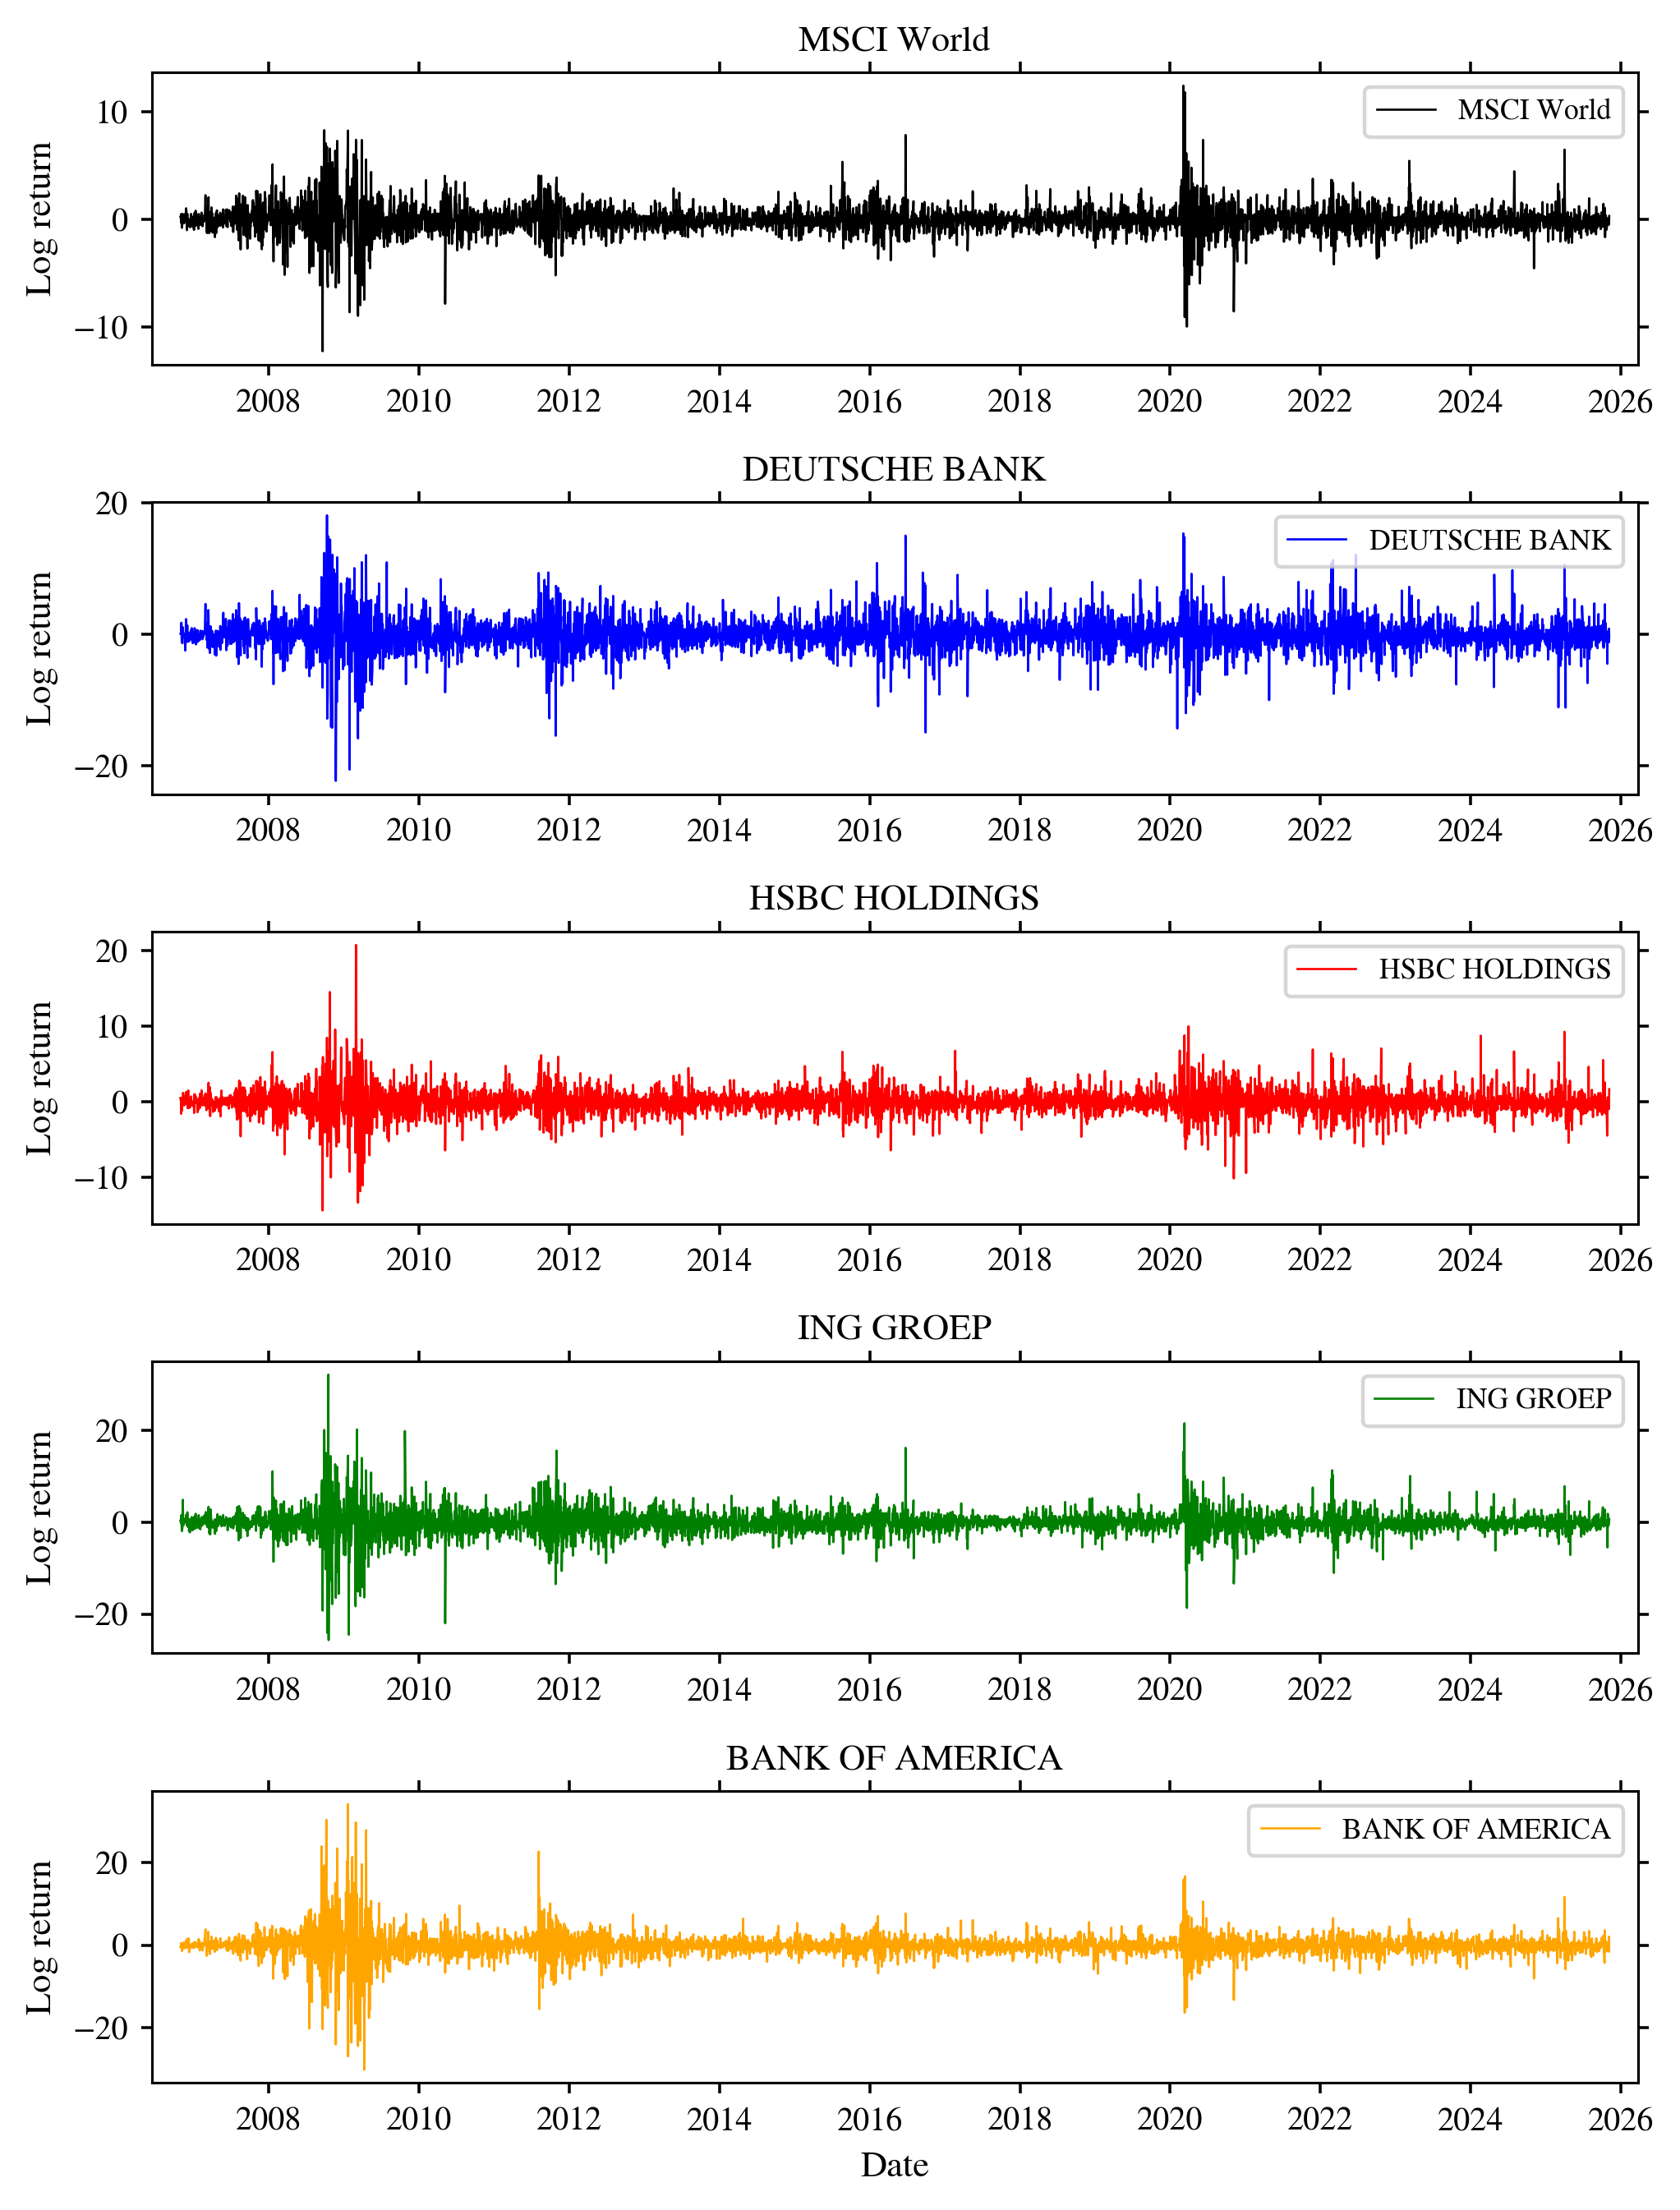

In [379]:
# Select the specified columns from gsibs_returns
columns_to_plot = [0, 8, 13, 19, 22]
selected_returns = gsibs_returns.iloc[:, columns_to_plot]

# 5 stacked panels (share x-axis)
fig, axes = plt.subplots(
    nrows=selected_returns.shape[1],
    ncols=1,
    figsize=(6.5, 8.5),          # stacked panels need height
    sharex=False
)

for ax, col, color in zip(axes, selected_returns.columns, ['black', 'blue', 'red', 'green', 'orange']):
    ax.plot(selected_returns.index, selected_returns[col], color=color, label=col)
    ax.set_title(col, pad=6)
    ax.set_ylabel("Log return")

    # Grid: choose one
    ax.grid(False)  # cleaner for stacked plots
    # ax.grid(True, axis="y", which="major")  # if you want soft y-grid

    ax.legend(loc="upper right", frameon=True, fontsize=8)

# Only bottom axis gets the x-label
axes[-1].set_xlabel("Date")

fig.tight_layout()
#fig.savefig(FIG_DIR / "fig_selected_bank_log_returns_panels.pdf")
plt.show()


### GPR index

In [380]:
# Load the GPR index data
gpr_data = pd.read_excel('./gpr_index_data.xlsx', engine='openpyxl')

# Convert 'DATE' column from yyyy-dd-mm to yyyy-mm-dd and set as index
gpr_data['DATE'] = pd.to_datetime(gpr_data['DATE'], format='%Y-%d-%m', errors='coerce', dayfirst=True)
gpr_data.dropna(subset=['DATE'], inplace=True)  # Drop rows where 'DATE' could not be converted
gpr_data.set_index('DATE', inplace=True)

# Resample the data to ensure consistent frequency (e.g., daily) and fill missing values
gpr_data = gpr_data.resample('D').interpolate(method='linear')

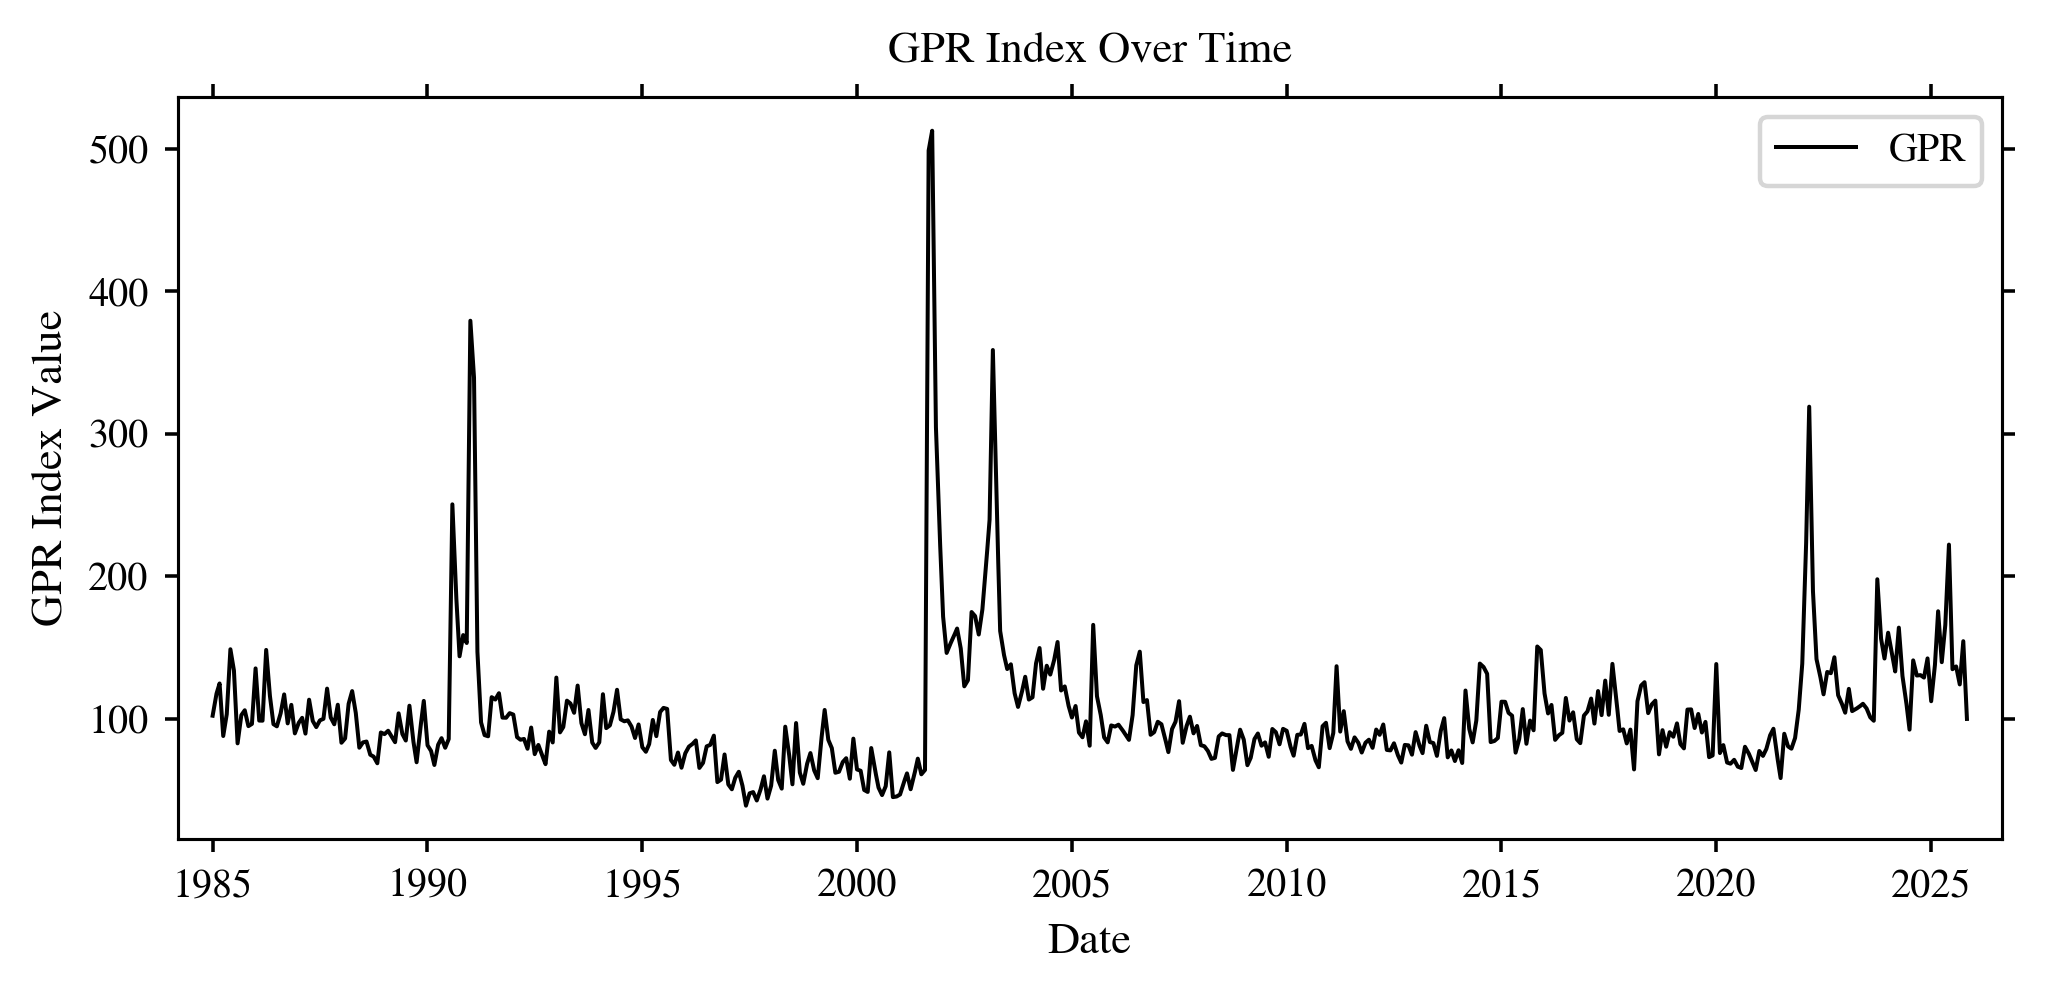

In [381]:
# Plot the GPR index over time
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(gpr_data.index, gpr_data.iloc[:, 0], color="black", label="GPR", linewidth=0.9)

ax.set_title("GPR Index Over Time", pad=8)
ax.set_xlabel("Date")
ax.set_ylabel("GPR Index Value")
ax.legend(loc="best")

ax.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "GPR_over_time.pdf")
plt.show()


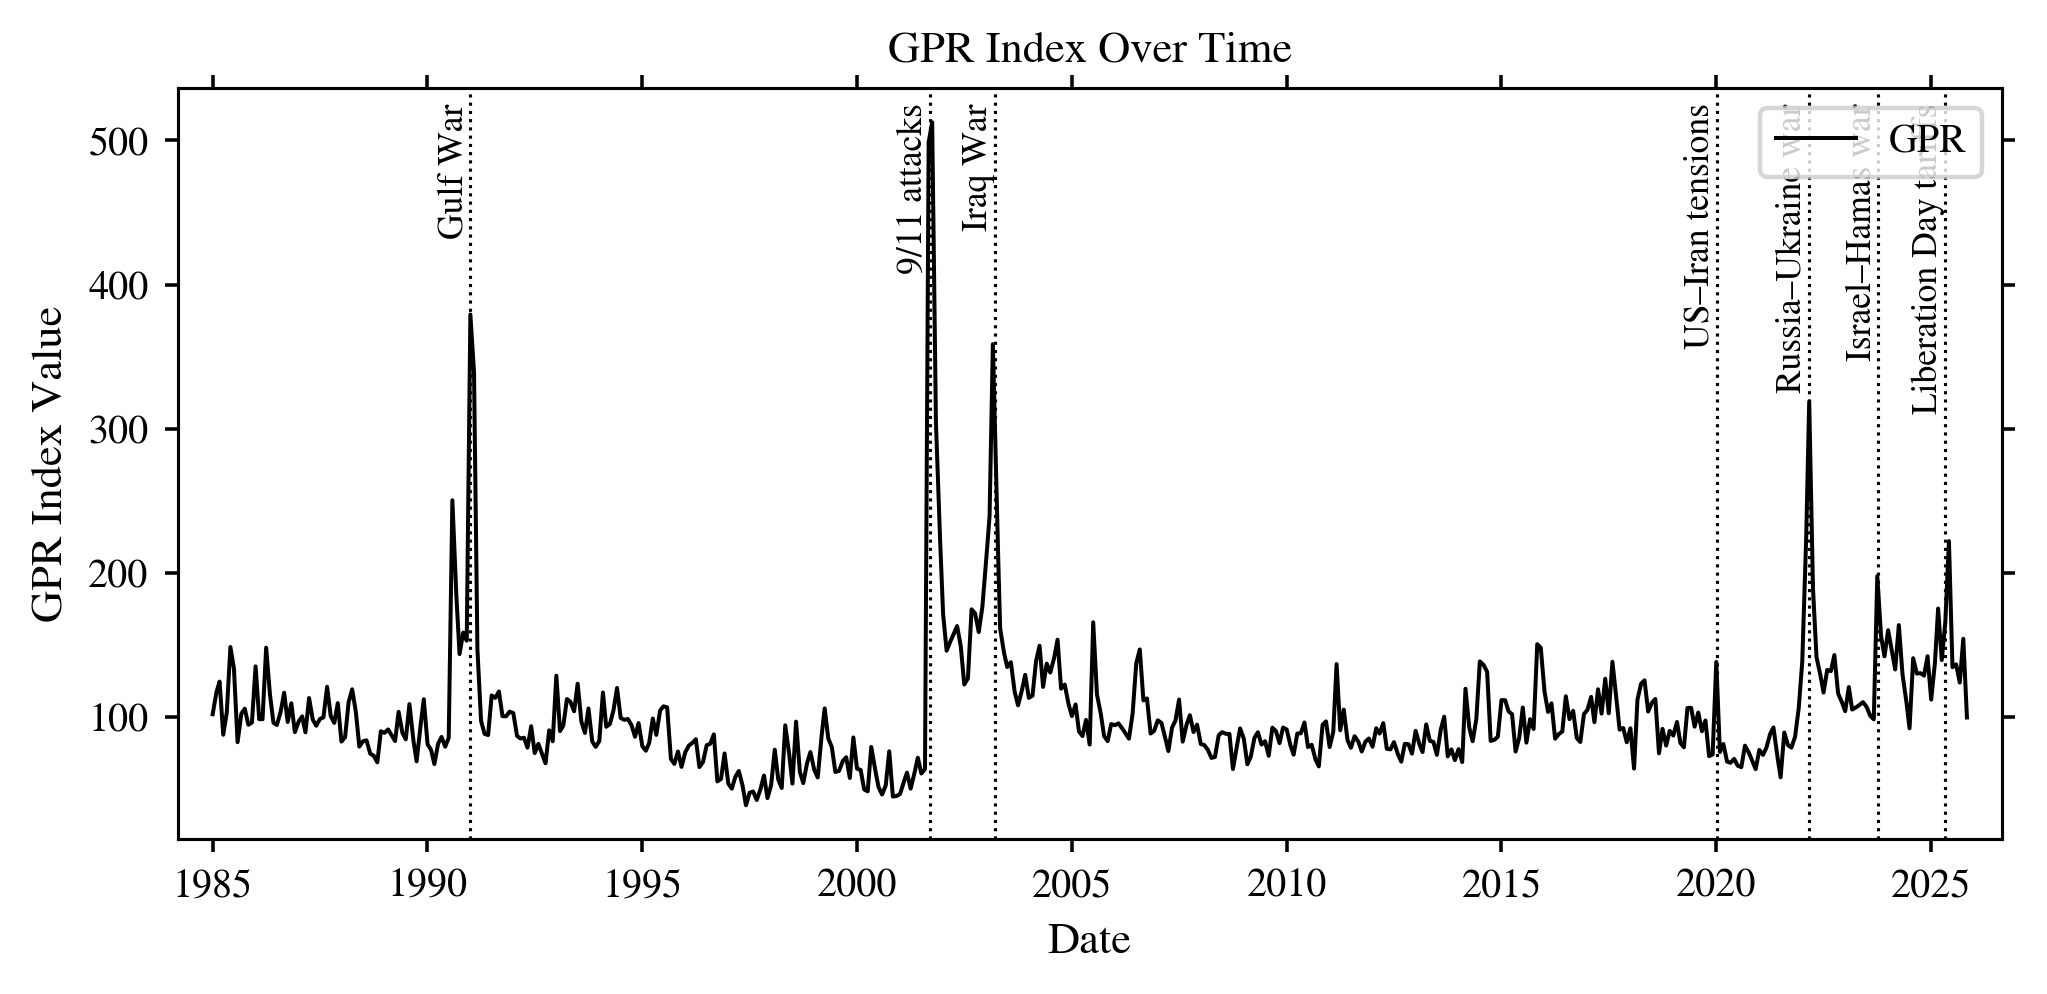

In [412]:
# Full-range GPR plot (1985–2025) with major geopolitical events
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(
    gpr_data.index,
    gpr_data.iloc[:, 0],
    color="black",
    label="GPR",
    linewidth=0.9
)

ax.set_title("GPR Index Over Time", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("GPR Index Value")

# Major geopolitical events (full-sample, only salient GPR-relevant shocks)
events = [
    ("Gulf War", "1991-01-02"),
    ("9/11 attacks", "2001-09-11"),
    ("Iraq War", "2003-03-20"),
    ("US–Iran tensions", "2020-01-03"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("Liberation Day tariffs", "2025-04-30"),
]

xmin, xmax = gpr_data.index.min(), gpr_data.index.max()

for label, date_str in events:
    dt = pd.Timestamp(date_str)
    if xmin <= dt <= xmax:
        ax.axvline(
            dt,
            color="black",
            linestyle=":",
            linewidth=0.7
        )
        ax.text(
            dt,
            0.98,
            label,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8
        )

ax.legend(loc="upper right", frameon=True)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
plt.show()


In [ ]:
# Helper to plot a zoomed GPR panel with event markers (exact dates, readable labels)
def plot_gpr_zoom(gpr_data, start, end, title, events):
    fig, ax = plt.subplots(figsize=FIG_FULL)

    gpr_win = gpr_data.loc[start:end].copy()
    series = gpr_win.iloc[:, 0].dropna()

    ax.plot(
        series.index,
        series.values,
        color="black",
        label="GPR",
        linewidth=0.9
    )

    ax.set_title(title, pad=6)
    ax.set_xlabel("Date")
    ax.set_ylabel("GPR Index Value")

    xmin, xmax = series.index.min(), series.index.max()

    for i, (label, date_str) in enumerate(events):
        dt = pd.Timestamp(date_str)
        if not (xmin <= dt <= xmax):
            continue

        ax.axvline(dt, color="black", linestyle=":", linewidth=0.7)

        # Stagger labels vertically to reduce overlap
        y_pos = 0.98 if i % 2 == 0 else 0.90

        ax.text(
            dt,
            y_pos,
            label,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.4,
                pad=0.6
            )
        )

    ax.legend(loc="upper right", frameon=True)
    ax.grid(False)
    ax.margins(x=0.02)

    fig.tight_layout()
    plt.show()

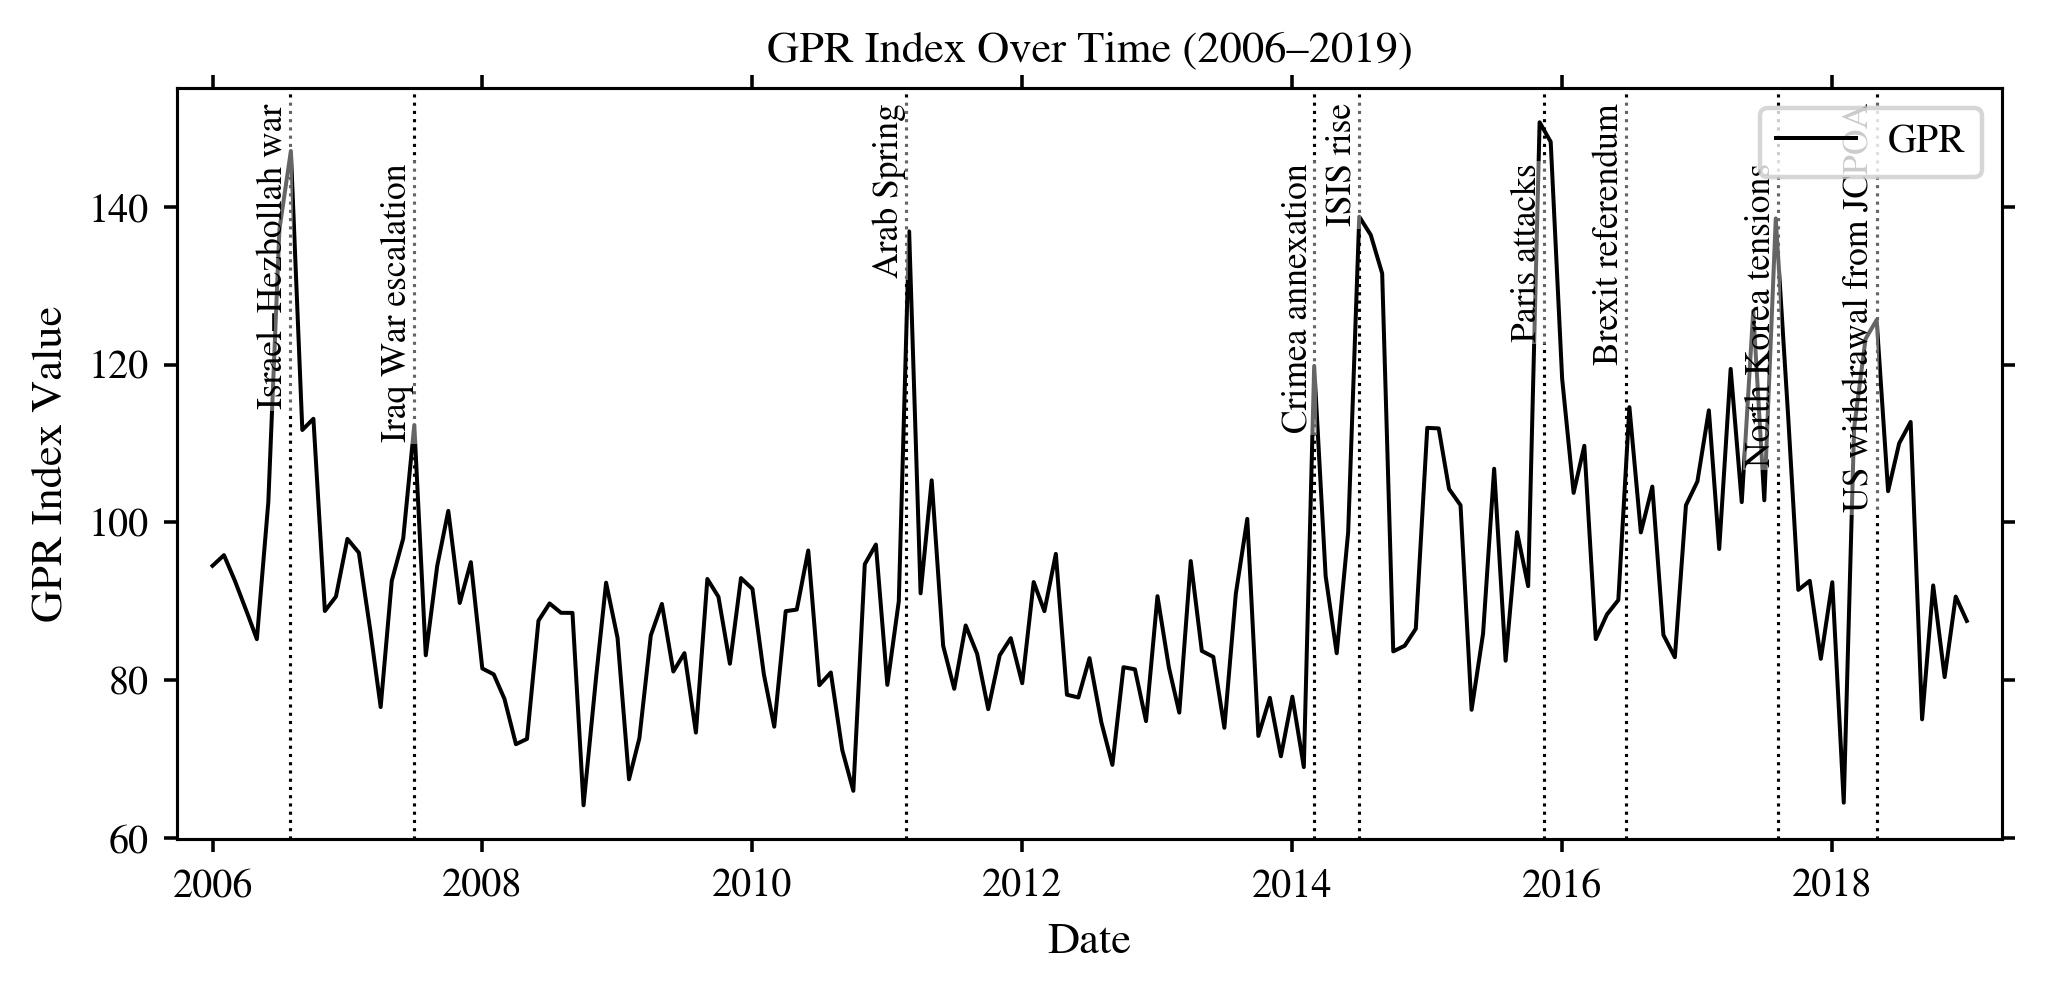

In [455]:
# 2006–2019
# =========================
events_2006_2019 = [
    ("Israel–Hezbollah war", "2006-07-30"),
    ("Iraq War escalation", "2007-07-01"),
    ("Arab Spring", "2011-02-20"),
    ("Crimea annexation", "2014-03-01"),
    ("ISIS rise", "2014-06-30"),
    ("Paris attacks", "2015-11-13"),
    ("Brexit referendum", "2016-06-23"),
    ("North Korea tensions", "2017-08-08"),
    ("US withdrawal from JCPOA", "2018-05-01"),
]

plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2006-01-01",
    end="2018-12-31",
    title="GPR Index Over Time (2006–2019)",
    events=events_2006_2019
)

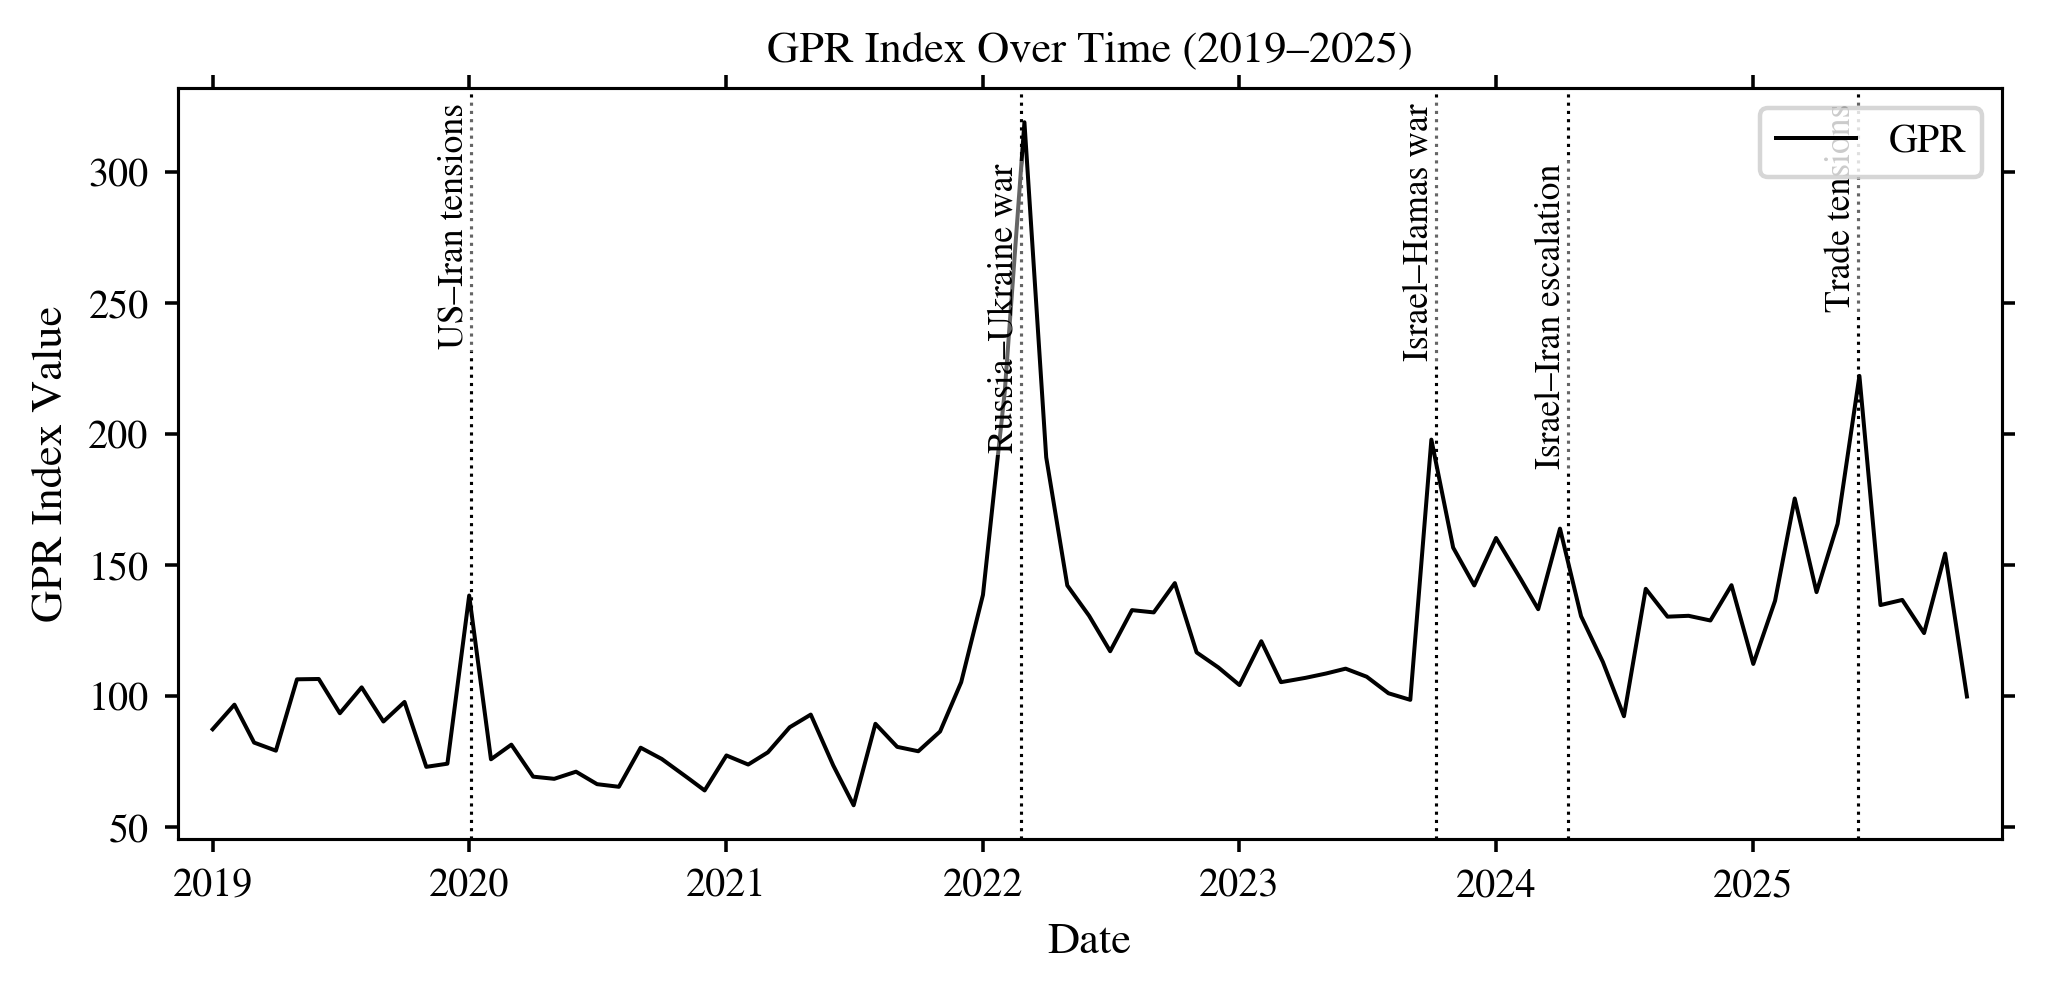

In [449]:
# 2019–2025
# =========================
events_2019_2025 = [
    ("US–Iran tensions", "2020-01-03"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("Israel–Iran escalation", "2024-04-13"),
    ("Trade tensions", "2025-05-30"),
]


plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2019-01-01",
    end="2025-12-31",
    title="GPR Index Over Time (2019–2025)",
    events=events_2019_2025
)

### Univariate GARCH(1,1) model fitting

Using the Python arch package

In [323]:
# Create an empty DataFrame to store conditional variances
cond_var_df_gsibs = pd.DataFrame(index=gsibs_returns.index, columns=gsibs_returns.columns)

# Fit GARCH(1,1) model for each asset in gsibs_returns and store conditional variances
for asset in gsibs_returns.columns:
    model = arch_model(gsibs_returns[asset], vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
    res = model.fit(disp='off')
    cond_var_df_gsibs[asset] = res.conditional_volatility ** 2

# Display the first 10 rows and 4 columns of the conditional variance DataFrame
print("Conditional Variances for GSIBs - Python arch package (first 10 rows and 4 columns):")
print(cond_var_df_gsibs.iloc[:10, :4])

Conditional Variances for GSIBs - Python arch package (first 10 rows and 4 columns):
            MSCI World  ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP
DATE                                                                     
2025-11-06        0.38                  0.52              0.76       1.46
2025-11-05        0.38                  0.54              0.65       1.58
2025-11-04        0.37                  0.50              0.59       1.67
2025-11-03        0.35                  0.46              0.52       1.98
2025-10-31        0.33                  0.54              0.89       1.86
2025-10-30        0.31                  0.57              0.75       1.76
2025-10-29        0.32                  0.57              0.67       1.65
2025-10-28        0.32                  0.53              0.63       1.57
2025-10-27        0.31                  0.83              0.81       1.60
2025-10-24        0.31                  0.74              0.82       1.54


Using R rugarch package

In [324]:
# Fit GARCH(1,1) model using rugarch for gsibs_returns and store results
rugarch_models_gsibs = {}
cond_var_r_df_gsibs = pd.DataFrame(index=gsibs_returns.index, columns=gsibs_returns.columns)

for asset in gsibs_returns.columns:
    with localconverter(ro.default_converter + pandas2ri.converter):
        returns_r = ro.conversion.py2rpy(gsibs_returns[asset].dropna())
    spec = rugarch.ugarchspec(
        variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1]), 'variance.targeting': False}),
        mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
        distribution_model='norm'
    )
    fit = rugarch.ugarchfit(spec, returns_r, solver='hybrid')
    rugarch_models_gsibs[asset] = fit
    cond_var_r_df_gsibs.loc[gsibs_returns[asset].dropna().index, asset] = np.array(rugarch.sigma(fit)).flatten()[::-1] ** 2

# Display the first 10 rows and 4 columns of the conditional variance DataFrame
print("Conditional Variances for GSIBs - R rugarch package (first 10 rows and 4 columns):")
print(cond_var_r_df_gsibs.iloc[:10, :4])

Conditional Variances for GSIBs - R rugarch package (first 10 rows and 4 columns):
           MSCI World ROYAL BANK OF CANADA TORONTO DOMINION UBS GROUP
DATE                                                                 
2025-11-06       0.45                 0.60             0.80      1.96
2025-11-05       0.46                 0.65             0.86      1.92
2025-11-04       0.49                 0.72             0.92      1.63
2025-11-03       0.53                 0.68             0.80      1.71
2025-10-31       0.58                 0.67             0.86      1.79
2025-10-30       0.61                 0.69             0.91      1.89
2025-10-29       0.65                 0.75             0.97      2.01
2025-10-28       0.71                 0.50             0.92      2.03
2025-10-27       0.76                 0.54             0.93      2.13
2025-10-24       0.74                 0.58             0.95      2.16


Compare the conditional variances from Python and R

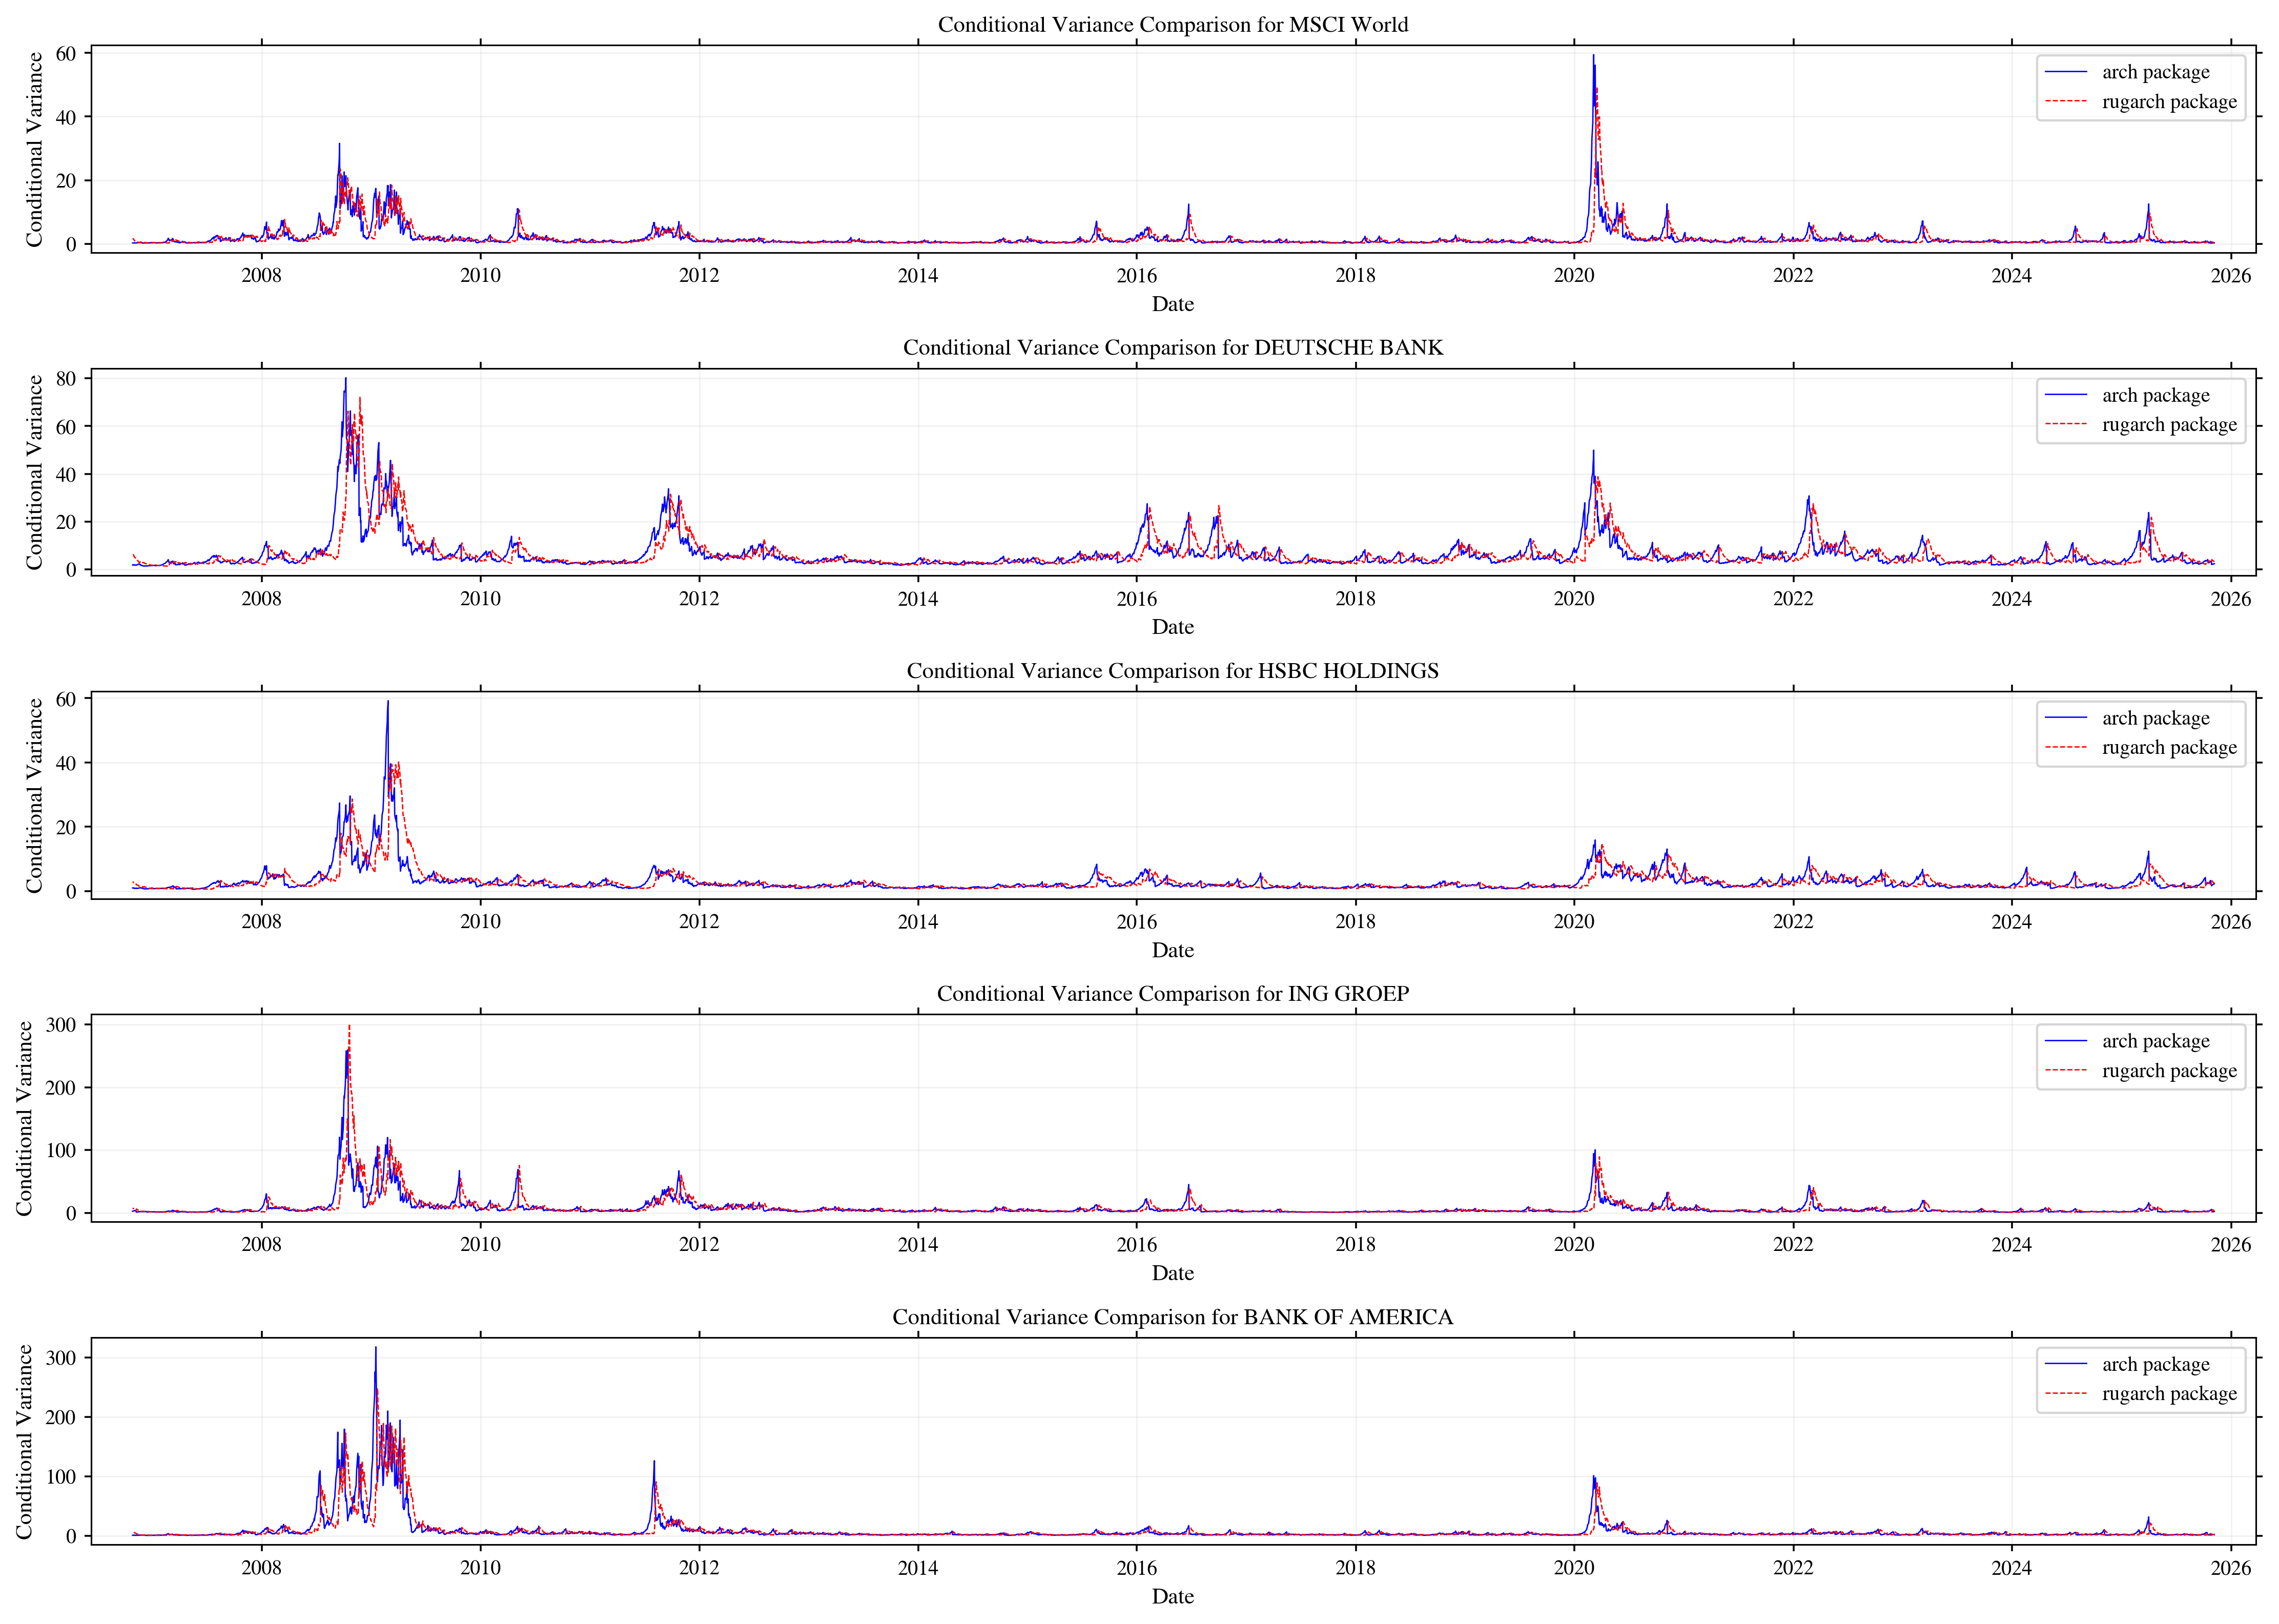

Correlation of conditional variances for MSCI World: 0.6266
Correlation of conditional variances for DEUTSCHE BANK: 0.6708
Correlation of conditional variances for HSBC HOLDINGS: 0.6500
Correlation of conditional variances for ING GROEP: 0.6460
Correlation of conditional variances for BANK OF AMERICA: 0.7261


In [325]:
# Define the columns to plot
columns_to_plot = [0, 8, 13, 19, 22]  # Adjusted for gsibs_returns

# Compare the conditional variances from arch and rugarch for the selected columns
plt.figure(figsize=(14, 10))
for i, col in enumerate(columns_to_plot, 1):
    asset = gsibs_returns.columns[col]
    plt.subplot(len(columns_to_plot), 1, i)
    plt.plot(cond_var_df_gsibs[asset], label='arch package', color='blue')
    plt.plot(cond_var_r_df_gsibs[asset], label='rugarch package', color='red', linestyle='--')
    plt.title(f'Conditional Variance Comparison for {asset}')
    plt.xlabel('Date')
    plt.ylabel('Conditional Variance')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

# Compare how much the conditional variances correlate for the selected columns
for col in columns_to_plot:
    asset = gsibs_returns.columns[col]
    corr = cond_var_df_gsibs[asset].corr(cond_var_r_df_gsibs[asset])
    print(f'Correlation of conditional variances for {asset}: {corr:.4f}')


Compute the diagonal matrix of conditional standard deviations $D_t$

In [326]:
# Calculate D matrices for the entire cond_var_r_df_gsibs dataframe
# Ensure all columns in cond_var_r_df_gsibs are numeric
cond_var_r_df_gsibs = cond_var_r_df_gsibs.apply(pd.to_numeric, errors='coerce')

# Calculate D matrices
gsibs_D_matrices = {date: np.diag(np.sqrt(cond_var_r_df_gsibs.loc[date])) for date in cond_var_r_df_gsibs.index}

# Flatten D matrices into a DataFrame for CSV export
gsibs_D_df = pd.DataFrame({
    'Date': cond_var_r_df_gsibs.index,
    **{f'D_{i+1}{i+1}': [gsibs_D_matrices[date][i, i] for date in cond_var_r_df_gsibs.index] for i in range(cond_var_r_df_gsibs.shape[1])}
}).set_index('Date')

# Save the D matrices to a CSV file
print("D Matrices DataFrame (first 5 rows):\n", gsibs_D_df.head())


D Matrices DataFrame (first 5 rows):
             D_11  D_22  D_33  D_44  D_55  D_66  D_77  D_88  D_99  D_1010  ...  \
Date                                                                      ...   
2025-11-06  0.67  0.78  0.90  1.40  1.21  1.46  1.30  1.20  1.80    1.69  ...   
2025-11-05  0.68  0.81  0.93  1.39  1.21  1.45  1.30  1.22  1.83    1.76  ...   
2025-11-04  0.70  0.85  0.96  1.28  1.26  1.49  1.33  1.23  1.85    1.83  ...   
2025-11-03  0.73  0.82  0.89  1.31  1.30  1.49  1.33  1.22  1.90    1.93  ...   
2025-10-31  0.76  0.82  0.93  1.34  1.08  1.31  1.21  1.19  1.92    2.04  ...   

            D_1919  D_2020  D_2121  D_2222  D_2323  D_2424  D_2525  D_2626  \
Date                                                                         
2025-11-06    1.79    1.77    1.17    1.55    1.54    1.44    1.17    1.47   
2025-11-05    1.59    1.86    1.20    1.59    1.52    1.48    1.19    1.47   
2025-11-04    1.53    1.96    1.23    1.66    1.41    1.53    1.21    1.52   
2025

### DCC estimation

To compute the time-varying conditional correlation matrix we use the DCC approach introduced by Engle (2002)

In [327]:
# Convert gsibs_returns dataframe to R
with localconverter(ro.default_converter + pandas2ri.converter):
    gsibs_returns_r = ro.conversion.py2rpy(gsibs_returns.dropna())

# Define univariate GARCH specs for each asset in gsibs_returns using rugarch
gsibs_uspec = rugarch.multispec([
    rugarch.ugarchspec(
        variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1])}),
        mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
        distribution_model='norm'
    ) for _ in range(gsibs_returns.shape[1])
])

# Define DCC spec for gsibs_returns
gsibs_dcc_spec = rmgarch.dccspec(uspec=gsibs_uspec, dccOrder=ro.IntVector([1, 1]), distribution='mvnorm')

# Fit the DCC model for gsibs_returns
gsibs_dcc_fit = rmgarch.dccfit(gsibs_dcc_spec, data=gsibs_returns_r)

# Extract R_t matrices for gsibs_returns
gsibs_Rt_array = rmgarch.rcor(gsibs_dcc_fit)

# Convert the full 3D array from R to NumPy for gsibs_returns
with localconverter(default_converter + numpy2ri.converter):
    gsibs_Rt_array_np = ro.conversion.rpy2py(gsibs_Rt_array)

# Create a DataFrame to store the R matrices for gsibs_returns
gsibs_R_matrices = {date: gsibs_Rt_array_np[:, :, i] for i, date in enumerate(gsibs_returns.index)}

# Flatten the R matrices into a DataFrame for CSV export
gsibs_R_df = pd.DataFrame({
    'Date': gsibs_returns.index,
    **{f'R_{row+1}{col+1}': [gsibs_R_matrices[date][row, col] for date in gsibs_returns.index] for row in range(gsibs_Rt_array_np.shape[0]) for col in range(gsibs_Rt_array_np.shape[1])}
}).set_index('Date')

# Save the R matrices for gsibs_returns to a CSV file
print("R Matrices DataFrame for gsibs_returns:\n", gsibs_R_df.head().to_string())

R Matrices DataFrame for gsibs_returns:
             R_11  R_12  R_13  R_14  R_15  R_16  R_17  R_18  R_19  R_110  R_111  R_112  R_113  R_114  R_115  R_116  R_117  R_118  R_119  R_120  R_121  R_122  R_123  R_124  R_125  R_126  R_127  R_128  R_21  R_22  R_23  R_24  R_25  R_26  R_27  R_28  R_29  R_210  R_211  R_212  R_213  R_214  R_215  R_216  R_217  R_218  R_219  R_220  R_221  R_222  R_223  R_224  R_225  R_226  R_227  R_228  R_31  R_32  R_33  R_34  R_35  R_36  R_37  R_38  R_39  R_310  R_311  R_312  R_313  R_314  R_315  R_316  R_317  R_318  R_319  R_320  R_321  R_322  R_323  R_324  R_325  R_326  R_327  R_328  R_41  R_42  R_43  R_44  R_45  R_46  R_47  R_48  R_49  R_410  R_411  R_412  R_413  R_414  R_415  R_416  R_417  R_418  R_419  R_420  R_421  R_422  R_423  R_424  R_425  R_426  R_427  R_428  R_51  R_52  R_53  R_54  R_55  R_56  R_57  R_58  R_59  R_510  R_511  R_512  R_513  R_514  R_515  R_516  R_517  R_518  R_519  R_520  R_521  R_522  R_523  R_524  R_525  R_526  R_527  R_528  R_61  R_62  

Next, we compute the time-varying conditional covariance matrix $H_t$ decomposed as $H_t = D_t R_t D_t$.

In [328]:
# Compute matrices H_t = D_t * R_t * D_t for G-SIBs and save to CSV
gsibs_H_matrices = {}
for date in gsibs_returns.index:
    D_t = gsibs_D_matrices[date]
    R_t = gsibs_R_matrices[date]
    H_t = D_t @ R_t @ D_t
    gsibs_H_matrices[date] = H_t

# Flatten H matrices into a DataFrame for CSV export
gsibs_H_df = pd.DataFrame({
    'Date': gsibs_returns.index,
    **{f'H_{row+1}{col+1}': [gsibs_H_matrices[date][row, col] for date in gsibs_returns.index] for row in range(gsibs_Rt_array_np.shape[0]) for col in range(gsibs_Rt_array_np.shape[1])}
}).set_index('Date')

# Save the H matrices for G-SIBs to a CSV file
print("H Matrices DataFrame for G-SIBs:\n", gsibs_H_df.head().to_string())

H Matrices DataFrame for G-SIBs:
             H_11  H_12  H_13  H_14  H_15  H_16  H_17  H_18  H_19  H_110  H_111  H_112  H_113  H_114  H_115  H_116  H_117  H_118  H_119  H_120  H_121  H_122  H_123  H_124  H_125  H_126  H_127  H_128  H_21  H_22  H_23  H_24  H_25  H_26  H_27  H_28  H_29  H_210  H_211  H_212  H_213  H_214  H_215  H_216  H_217  H_218  H_219  H_220  H_221  H_222  H_223  H_224  H_225  H_226  H_227  H_228  H_31  H_32  H_33  H_34  H_35  H_36  H_37  H_38  H_39  H_310  H_311  H_312  H_313  H_314  H_315  H_316  H_317  H_318  H_319  H_320  H_321  H_322  H_323  H_324  H_325  H_326  H_327  H_328  H_41  H_42  H_43  H_44  H_45  H_46  H_47  H_48  H_49  H_410  H_411  H_412  H_413  H_414  H_415  H_416  H_417  H_418  H_419  H_420  H_421  H_422  H_423  H_424  H_425  H_426  H_427  H_428  H_51  H_52  H_53  H_54  H_55  H_56  H_57  H_58  H_59  H_510  H_511  H_512  H_513  H_514  H_515  H_516  H_517  H_518  H_519  H_520  H_521  H_522  H_523  H_524  H_525  H_526  H_527  H_528  H_61  H_62  H_63  H

### Time-varying Betas

The conditional beta of asset i with respect to the market at time t is defined as: $\beta_{i,t} = \frac{Cov_t(r_{i,t}, r_{m,t})}{Var_t(r_{m,t})} = \frac{h_{im,t}}{h_{m,t}}$ where $h_{im,t}$ is the (i, m)-th element of the conditional covariance matrix $H_t$.

In [329]:
# Initialize list to store H_t matrices for G-SIBs
gsibs_Ht_list = [gsibs_H_matrices[date] for date in gsibs_H_matrices.keys()]

# Compute conditional betas for G-SIBs: beta_{i,t} = h_{im,t} / h_{m,t}
gsibs_market_index = 0
gsibs_bank_indices = list(range(1, len(gsibs_returns.columns)))  # Exclude the market index
gsibs_bank_names = gsibs_returns.columns[1:]  # Exclude the market column

GSIBs_beta = pd.DataFrame(index=gsibs_returns.index, columns=gsibs_bank_names)

for t, H_t in enumerate(gsibs_Ht_list):
    h_mm_t = H_t[gsibs_market_index, gsibs_market_index]
    for i, bank_idx in enumerate(gsibs_bank_indices):
        h_im_t = H_t[bank_idx, gsibs_market_index]
        GSIBs_beta.iloc[t, i] = h_im_t / h_mm_t if h_mm_t != 0 else np.nan

# Convert to float
GSIBs_beta = GSIBs_beta.astype(float)

# Save the beta DataFrame to a CSV file
GSIBs_beta.to_csv('./Outputs/Dataframes/GSIBs_beta.csv')

Plot the dynamic betas

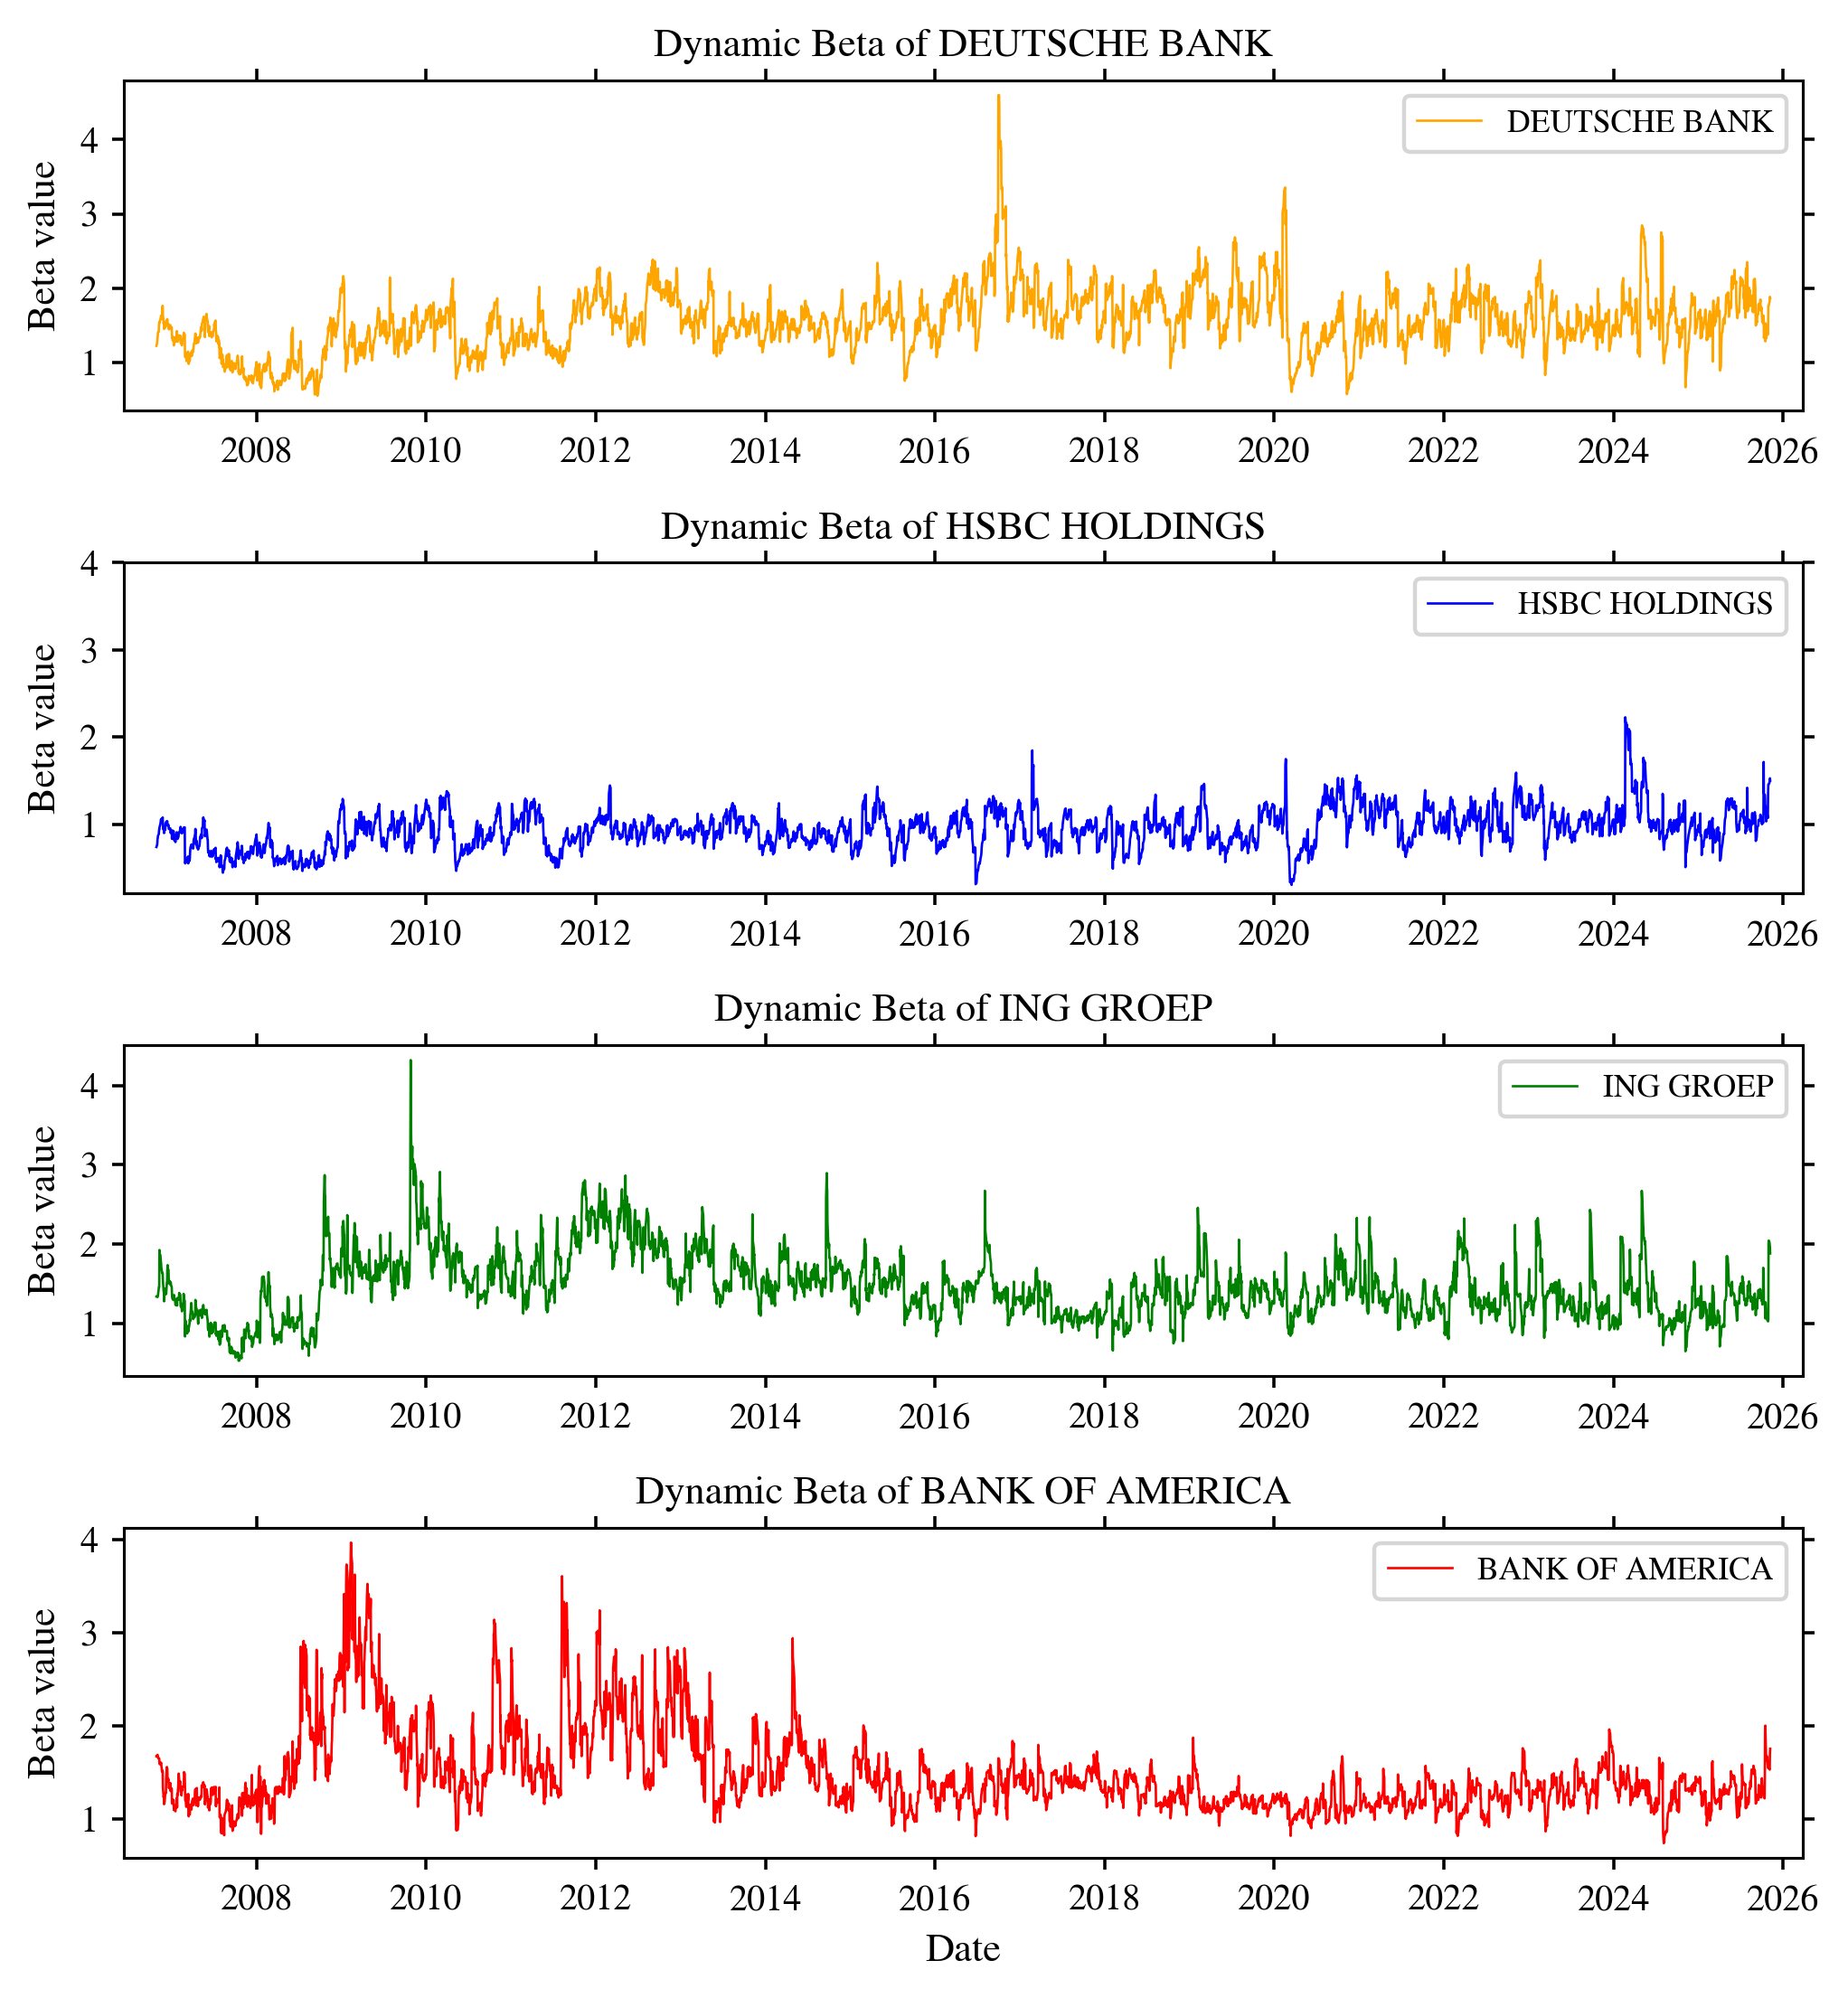

In [330]:
# Select the columns to plot selected bank betas
columns_to_plot = [7, 12, 18, 21]  # 0-based indexing
selected_banks = GSIBs_beta.columns[columns_to_plot]

colors = ["orange", "blue", "green", "red"]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),     # 4 stacked panels
    sharex=False
)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(
        GSIBs_beta.index,
        GSIBs_beta[bank],
        color=color,
        label=bank
    )

    ax.set_title(f"Dynamic Beta of {bank}", pad=6)
    ax.set_ylabel("Beta value")

    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)          # clean for stacked panels
    ax.margins(x=0.02)

# Show x tick labels on all panels
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_yticks([1, 2, 3, 4])

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / "Dynamic_betas.pdf")
plt.show()

Plot the GPR index into the conditional betas

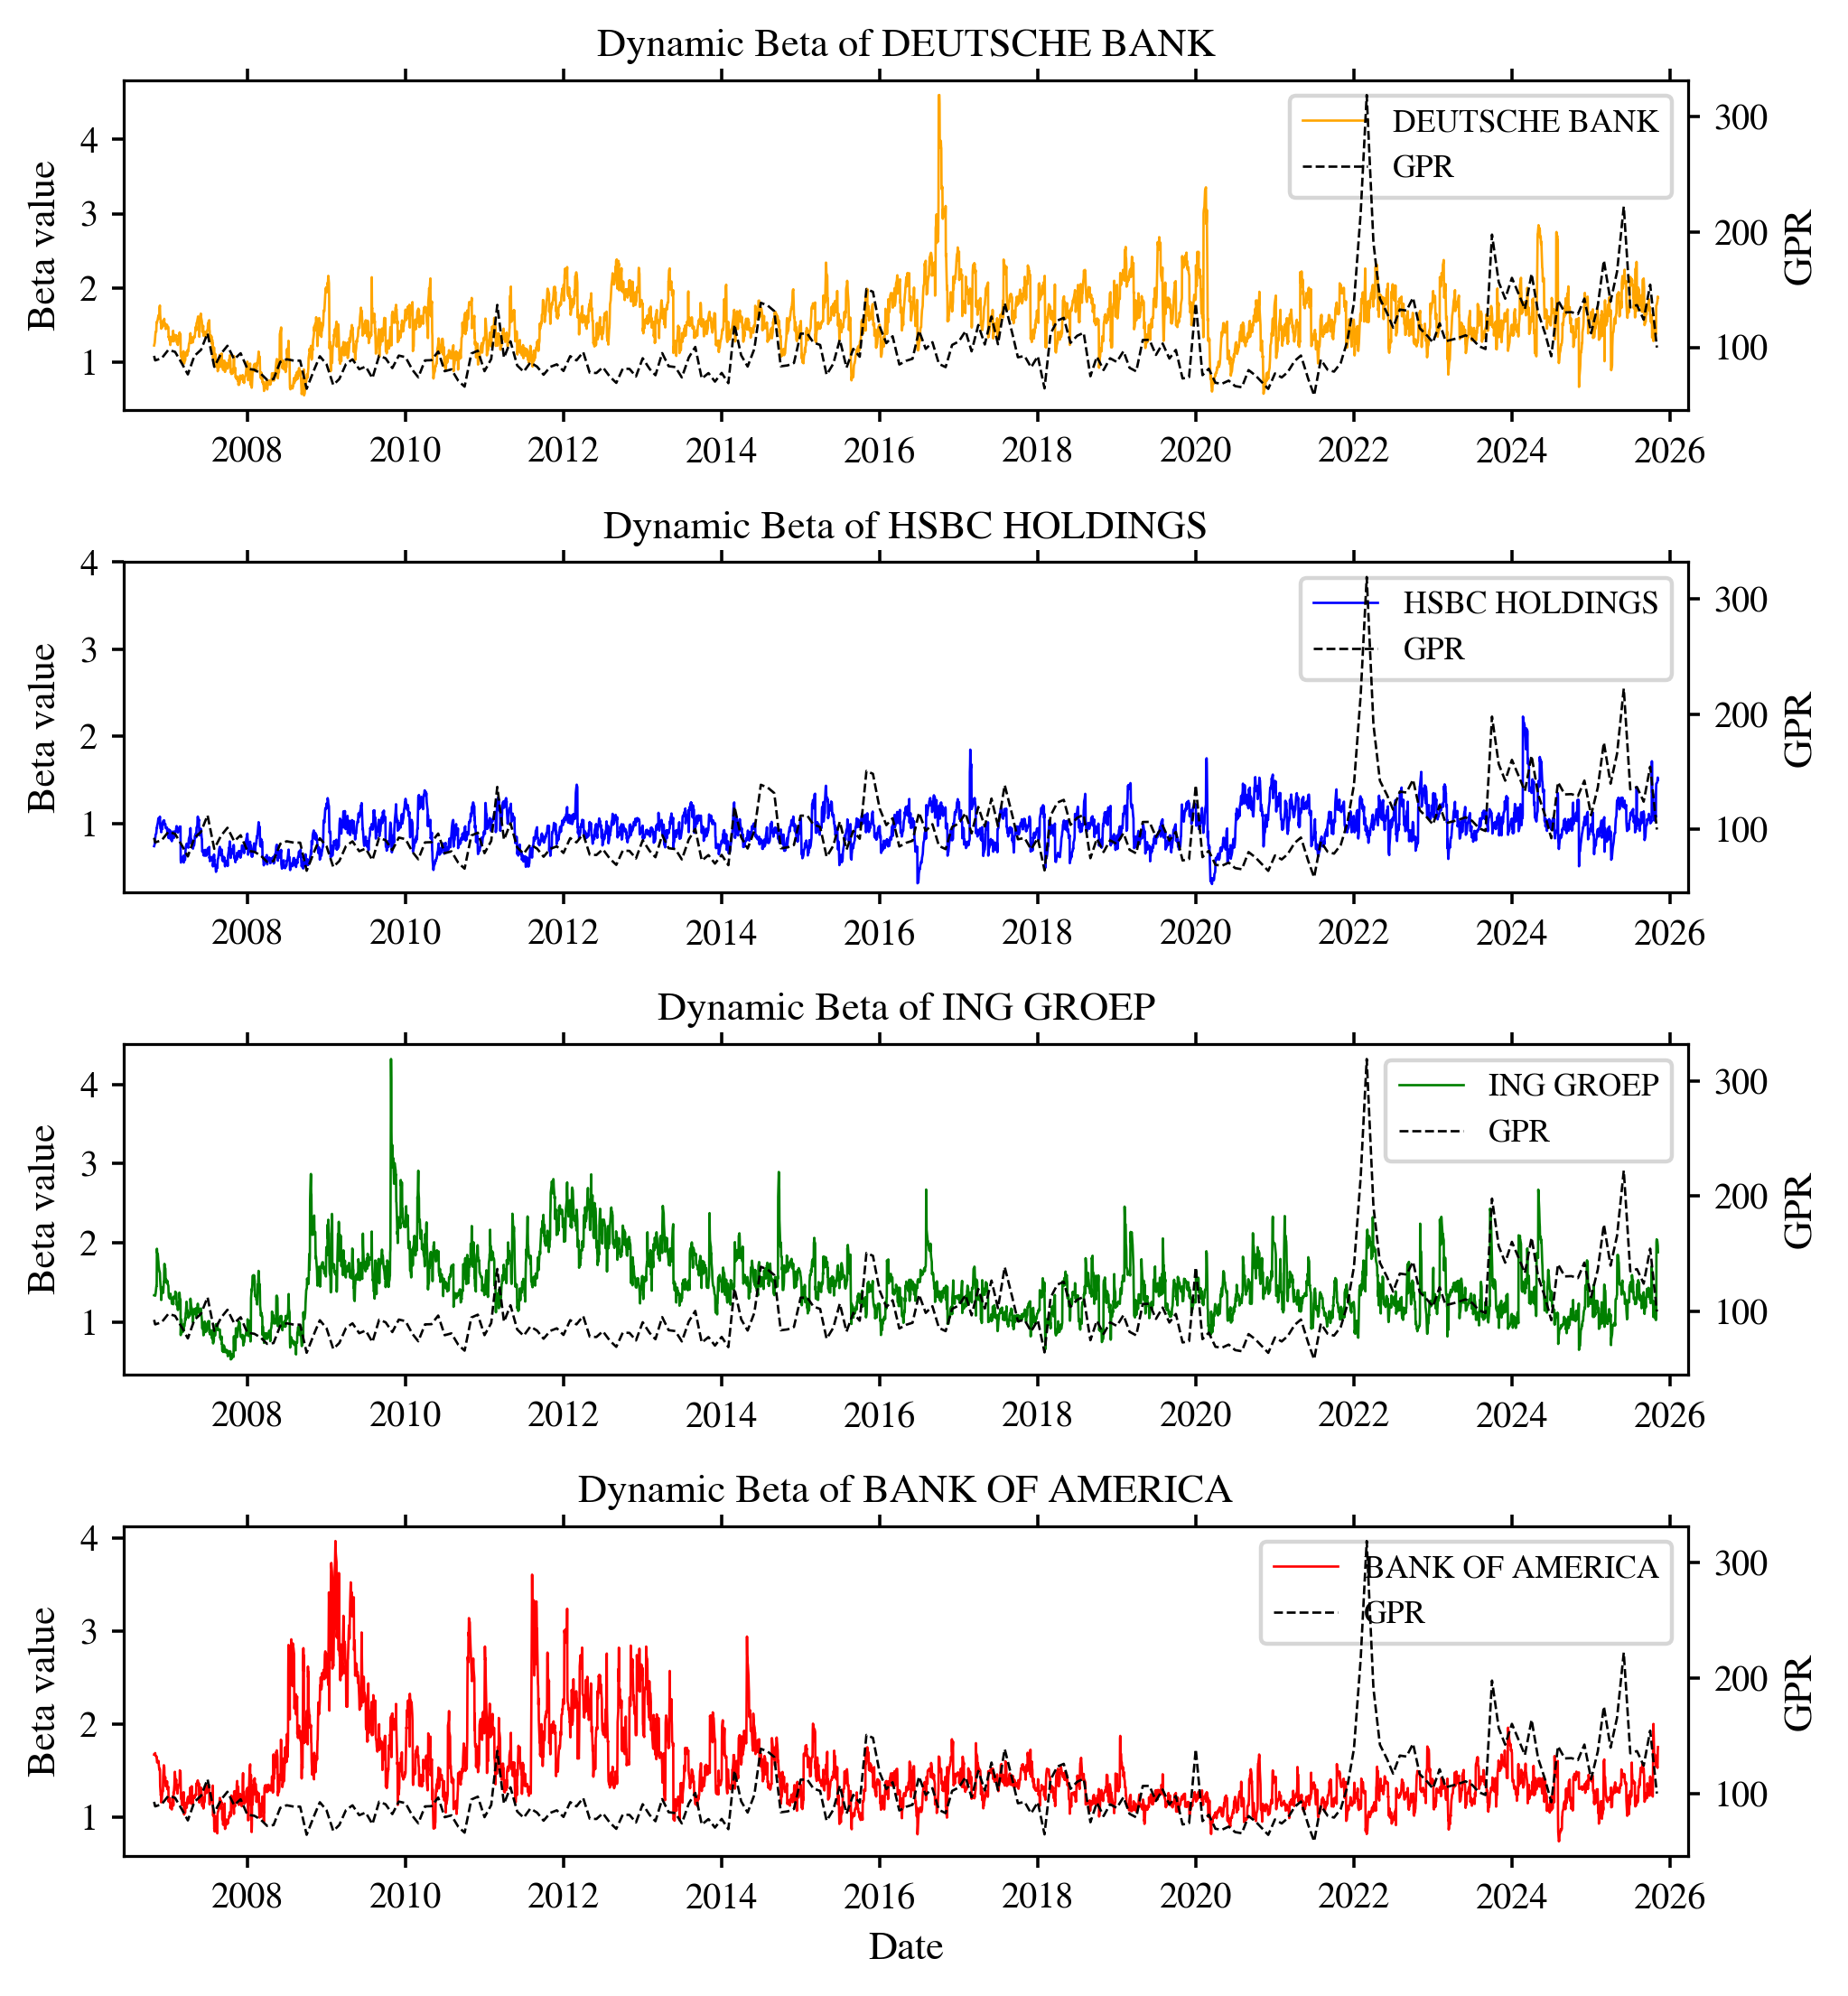

In [331]:
# Ensure no dates fall outside of the range of gsibs_returns
gpr_data = gpr_data[
    (gpr_data.index >= gsibs_returns.index.min())
    & (gpr_data.index <= gsibs_returns.index.max())
]

# Select the columns to plot selected bank betas
columns_to_plot = [7, 12, 18, 21]  # 0-based indexing
selected_banks = GSIBs_beta.columns[columns_to_plot]

colors = ["orange", "blue", "green", "red"]

# 4 stacked panels
fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

for ax, bank, color in zip(axes, selected_banks, colors):

    # Left axis: beta
    beta_line, = ax.plot(
        GSIBs_beta.index,
        GSIBs_beta[bank],
        color=color,
        label=bank
    )

    ax.set_title(f"Dynamic Beta of {bank}", pad=6)
    ax.set_ylabel("Beta value")
    ax.set_yticks([1, 2, 3, 4])
    ax.margins(x=0.02)
    ax.grid(False)

    # Right axis: GPR
    ax_gpr = ax.twinx()
    gpr_line, = ax_gpr.plot(
        gpr_data.index,
        gpr_data["GPR"],
        color="black",
        linestyle="--",
        label="GPR"
    )

    ax_gpr.set_ylabel("GPR")
    ax_gpr.tick_params(axis="y")

    # Combined legend (order: beta first, GPR second)
    ax.legend(
        handles=[beta_line, gpr_line],
        loc="upper right",
        frameon=True,
        fontsize=8
    )

# X-axis formatting
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / "Dynamic_betas_with_gpr.pdf")
plt.show()


Correlation between GPR and betas

In [332]:
# Calculate correlation between GPR index and conditional betas for selected banks
for bank in selected_banks:
    merged_data = pd.merge(GSIBs_beta[[bank]], gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data[bank].corr(merged_data['GPR'])
    print(f'Correlation between GPR index and beta of {bank}: {corr:.4f}')

Correlation between GPR index and beta of DEUTSCHE BANK: 0.1650
Correlation between GPR index and beta of HSBC HOLDINGS: 0.1857
Correlation between GPR index and beta of ING GROEP: -0.1546
Correlation between GPR index and beta of BANK OF AMERICA: -0.2172


# SRISK

First we want to match the dates of the market value of equity $E_t$ and the book value of the liabilities $D_t$ with the betas.

In [333]:
# Make sure the GSIBs_equity dataframe has the same indices as GSIBs_beta
GSIBs_equity = GSIBs_equity.reindex(GSIBs_beta.index)

# Validate alignment
assert GSIBs_equity.index.equals(GSIBs_beta.index), "Indices are not aligned after reindexing!"
print("Indices are aligned after reindexing GSIBs_equity.")

Indices are aligned after reindexing GSIBs_equity.


In [334]:
# Adjust the date format for GSIBs_liabilities and GSIBs_assets to match date format of GSIBs_equity
def date_only_index(df, index_name="DATE"):
    df = df.copy()
    df.index = pd.to_datetime(df.index).normalize()  # strips hh:mm:ss and nanoseconds
    df.index.name = index_name
    return df

GSIBs_liabilities = date_only_index(GSIBs_liabilities, "PERIOD")
GSIBs_assets      = date_only_index(GSIBs_assets, "PERIOD")
OSIIs_liabilities = date_only_index(OSIIs_liabilities, "PERIOD")
OSIIs_assets      = date_only_index(OSIIs_assets, "PERIOD")

# Since quarters are repeats, take one value per year 
def to_yearly_start(df):
    yearly = df.resample("Y").last()
    yearly.index = yearly.index.to_period("Y").to_timestamp("Y").normalize()
    yearly.index = yearly.index - pd.offsets.YearBegin(1)
    return yearly

GSIBs_liabilities = to_yearly_start(GSIBs_liabilities)
GSIBs_assets  = to_yearly_start(GSIBs_assets)
OSIIs_liabilities = to_yearly_start(OSIIs_liabilities)
OSIIs_assets  = to_yearly_start(OSIIs_assets)

# Reverse the dataframes to have the most recent dates first
GSIBs_liabilities = GSIBs_liabilities.iloc[::-1]
GSIBs_assets = GSIBs_assets.iloc[::-1]
OSIIs_liabilities = OSIIs_liabilities.iloc[::-1]
OSIIs_assets = OSIIs_assets.iloc[::-1]

C:\Users\Asus\AppData\Local\Temp\ipykernel_12884\597051300.py:15: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_12884\597051300.py:15: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_12884\597051300.py:15: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_12884\597051300.py:15: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()


In [335]:
# Check the first few rows of the adjusted liabilities dataframe
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print("Adjusted GSIBs_liabilities DataFrame (first 5 rows):")
    print(GSIBs_liabilities.head())
    print("Adjusted GSIBs_assets DataFrame (first 5 rows):")
    print(GSIBs_assets.head())

Adjusted GSIBs_liabilities DataFrame (first 5 rows):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  \
PERIOD                                                                         
2025-01-01                   NaN               NaN        NaN            NaN   
2024-01-01             2,040,062         1,941,654  1,331,766     32,335,607   
2023-01-01             1,884,786         1,840,957  1,363,977     29,880,150   
2022-01-01             1,807,572         1,803,952    959,925     26,526,049   
2021-01-01             1,605,550         1,626,589    955,141     24,520,638   

            CHINA CON.BANK  INDL&COML.BOC.  BANK OF COMMS.  DEUTSCHE BANK  \
PERIOD                                                                      
2025-01-01             NaN             NaN             NaN            NaN   
2024-01-01      37,206,699      44,934,163      13,832,212      1,311,456   
2023-01-01      35,171,516      41,035,539      13,050,481      1,238,309   
2

Now we want to reindex to the trading-day index from yearly, and interpolate by time by forward-filling

In [336]:
# Align GSIBs_liabilities and GSIBs_assets to GSIBs_beta index with forward-fill
target_idx = pd.to_datetime(GSIBs_beta.index).normalize()
target_idx_asc = target_idx.sort_values()

common_cols = [c for c in GSIBs_beta.columns
               if c in GSIBs_liabilities.columns and c in GSIBs_assets.columns]

def reindex_to_beta_and_ffill(df, target_idx_asc, cols):
    df2 = df.loc[:, cols].copy()

    # clean index + sort
    df2.index = pd.to_datetime(df2.index).normalize()
    df2 = df2.sort_index()

    # IMPORTANT: keep anchor dates even if not trading days
    union_idx = target_idx_asc.union(df2.index).sort_values()

    # forward-fill on the union, then take only beta dates
    out = df2.reindex(union_idx).ffill()
    out = out.reindex(target_idx_asc)

    # return aligned to the original beta index order (usually already sorted)
    return out.reindex(pd.to_datetime(GSIBs_beta.index).normalize())

GSIBs_liabilities = reindex_to_beta_and_ffill(GSIBs_liabilities, target_idx_asc, common_cols)
GSIBs_assets      = reindex_to_beta_and_ffill(GSIBs_assets,      target_idx_asc, common_cols)

print("GSIBs_liabilities aligned:", GSIBs_liabilities.shape,
      "index matches beta:", GSIBs_liabilities.index.equals(pd.to_datetime(GSIBs_beta.index).normalize()))
print("GSIBs_assets aligned:", GSIBs_assets.shape,
      "index matches beta:", GSIBs_assets.index.equals(pd.to_datetime(GSIBs_beta.index).normalize()))

GSIBs_liabilities aligned: (4965, 27) index matches beta: True
GSIBs_assets aligned: (4965, 27) index matches beta: True


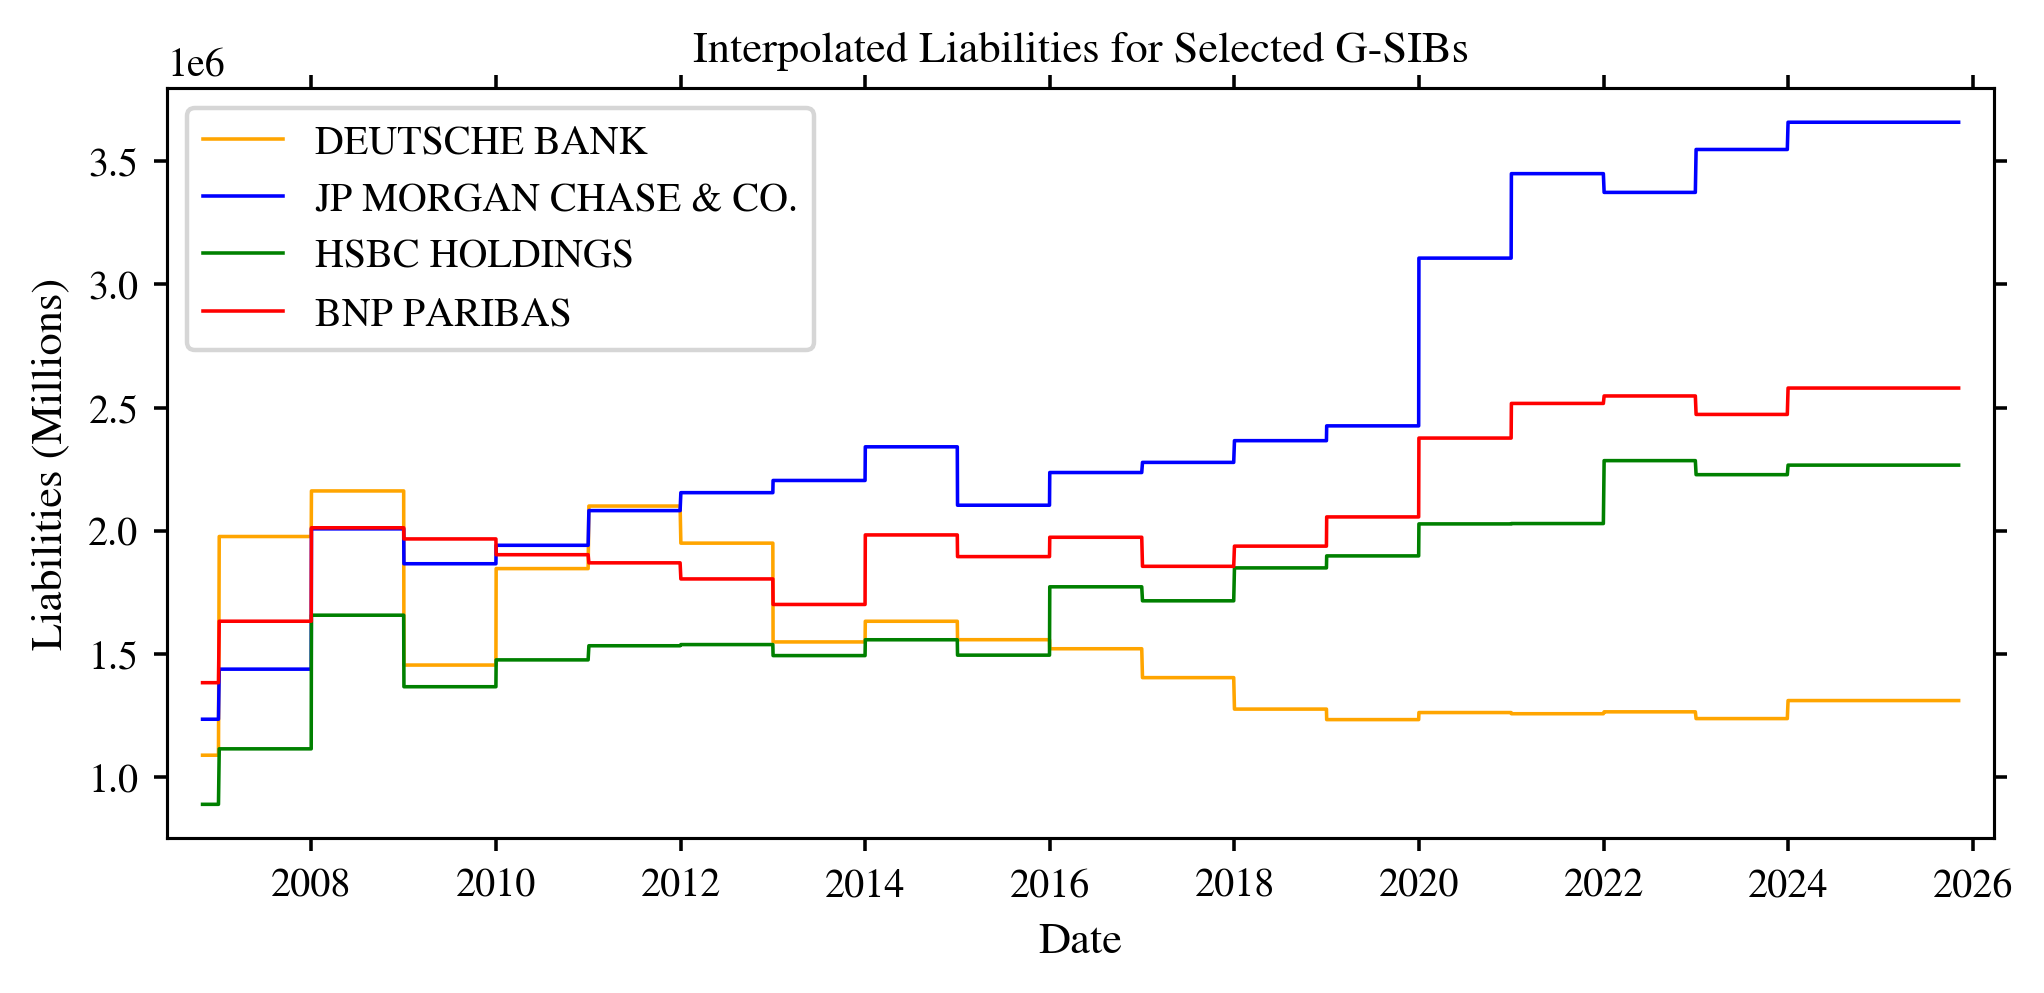

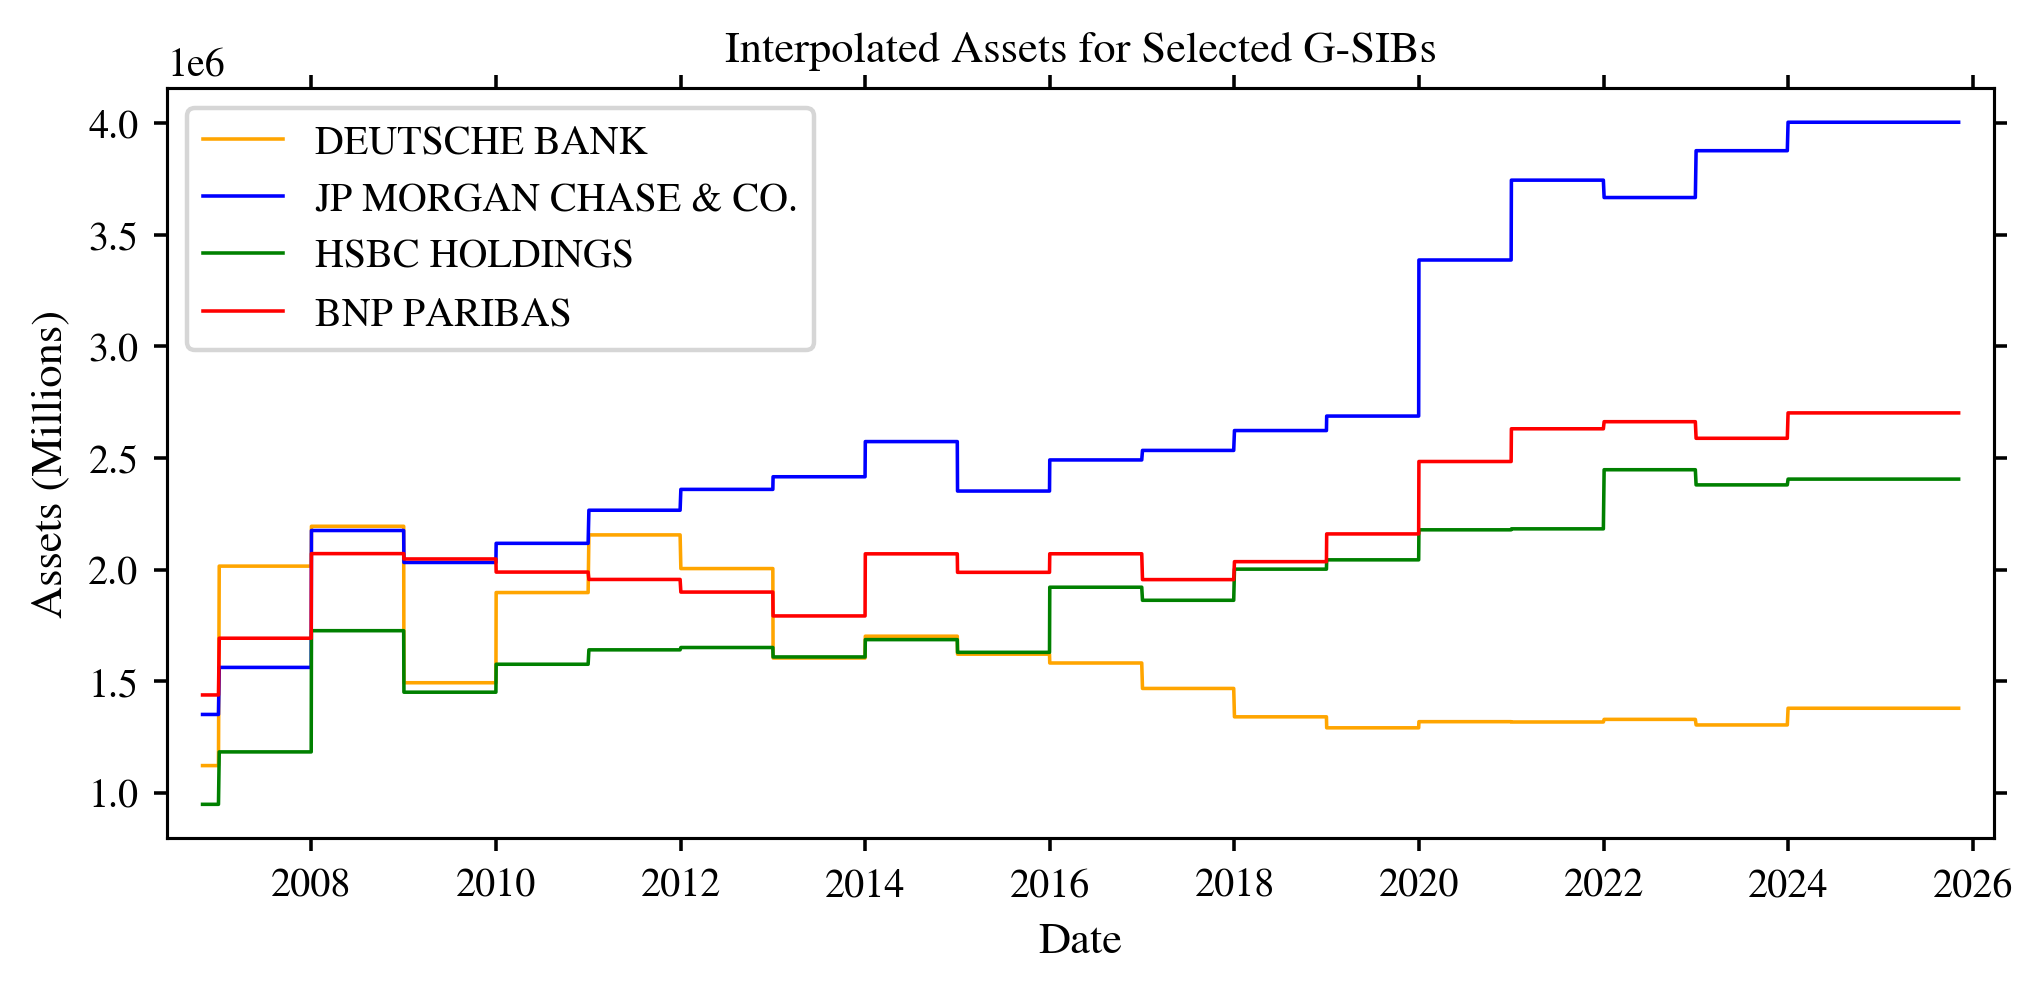

In [337]:
# Plot the interpolated data for visual inspection
# Select a few banks to plot their interpolated liabilities

# Banks to plot
banks_to_plot = [
    "DEUTSCHE BANK",
    "JP MORGAN CHASE & CO.",
    "HSBC HOLDINGS",
    "BNP PARIBAS",
]

colors = ["orange", "blue", "green", "red"]

fig, ax = plt.subplots(figsize=FIG_FULL)

for bank, color in zip(banks_to_plot, colors):
    if bank in GSIBs_liabilities.columns:
        ax.plot(
            GSIBs_liabilities.index,
            GSIBs_liabilities[bank],
            label=bank,
            color=color,
            linewidth=0.8
        )

ax.set_title("Interpolated Liabilities for Selected G-SIBs", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Liabilities (Millions)")

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
plt.show()

# Similarly, plot the interpolated data for assets
fig, ax = plt.subplots(figsize=FIG_FULL)

for bank, color in zip(banks_to_plot, colors):
    if bank in GSIBs_assets.columns:
        ax.plot(
            GSIBs_assets.index,
            GSIBs_assets[bank],
            label=bank,
            color=color,
            linewidth=0.8
        )

ax.set_title("Interpolated Assets for Selected G-SIBs", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Assets (Millions)")

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
plt.show()

In [338]:
# Print the first few rows of the adjusted dataframes
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print("Adjusted GSIBs_liabilities DataFrame (first 5 rows):")
    print(GSIBs_liabilities.head())
    print("Adjusted GSIBs_assets DataFrame (first 5 rows):")
    print(GSIBs_assets.head())

Adjusted GSIBs_liabilities DataFrame (first 5 rows):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  \
DATE                                                                           
2025-11-06             2,040,062         1,941,654  1,331,766     32,335,607   
2025-11-05             2,040,062         1,941,654  1,331,766     32,335,607   
2025-11-04             2,040,062         1,941,654  1,331,766     32,335,607   
2025-11-03             2,040,062         1,941,654  1,331,766     32,335,607   
2025-10-31             2,040,062         1,941,654  1,331,766     32,335,607   

            CHINA CON.BANK  INDL&COML.BOC.  BANK OF COMMS.  DEUTSCHE BANK  \
DATE                                                                        
2025-11-06      37,206,699      44,934,163      13,832,212      1,311,456   
2025-11-05      37,206,699      44,934,163      13,832,212      1,311,456   
2025-11-04      37,206,699      44,934,163      13,832,212      1,311,456   
2

### LRMES

In [339]:
# Approximate LRMES for G-SIBs using the conditional betas and a market decline of 40%
market_decline = -0.4

GSIBs_LRMES = 1 - np.exp(GSIBs_beta * market_decline)

# Print the first 10 rows and 4 columns of the G-SIBs LRMES DataFrame
print("LRMES for G-SIBs (first 10 rows and 4 columns):")
print(GSIBs_LRMES.iloc[:5, :4])
# Print the last 10 rows and 4 columns of the G-SIBs LRMES DataFrame
print("LRMES for G-SIBs (last 10 rows and 4 columns):")
print(GSIBs_LRMES.iloc[-5:, :4])

# Save the G-SIBs LRMES DataFrame to a CSV file
GSIBs_LRMES.to_csv('./Outputs/Dataframes/GSIBs_LRMES.csv')

LRMES for G-SIBs (first 10 rows and 4 columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2025-11-06                  0.24              0.27       0.43           0.19
2025-11-05                  0.25              0.28       0.43           0.19
2025-11-04                  0.25              0.28       0.39           0.19
2025-11-03                  0.24              0.25       0.38           0.19
2025-10-31                  0.22              0.25       0.38           0.15
LRMES for G-SIBs (last 10 rows and 4 columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2006-11-02                  0.23              0.23       0.43           0.12
2006-11-01                  0.20              0.20       0.43           0.12
2006-10-31                  0.19              0.20       0

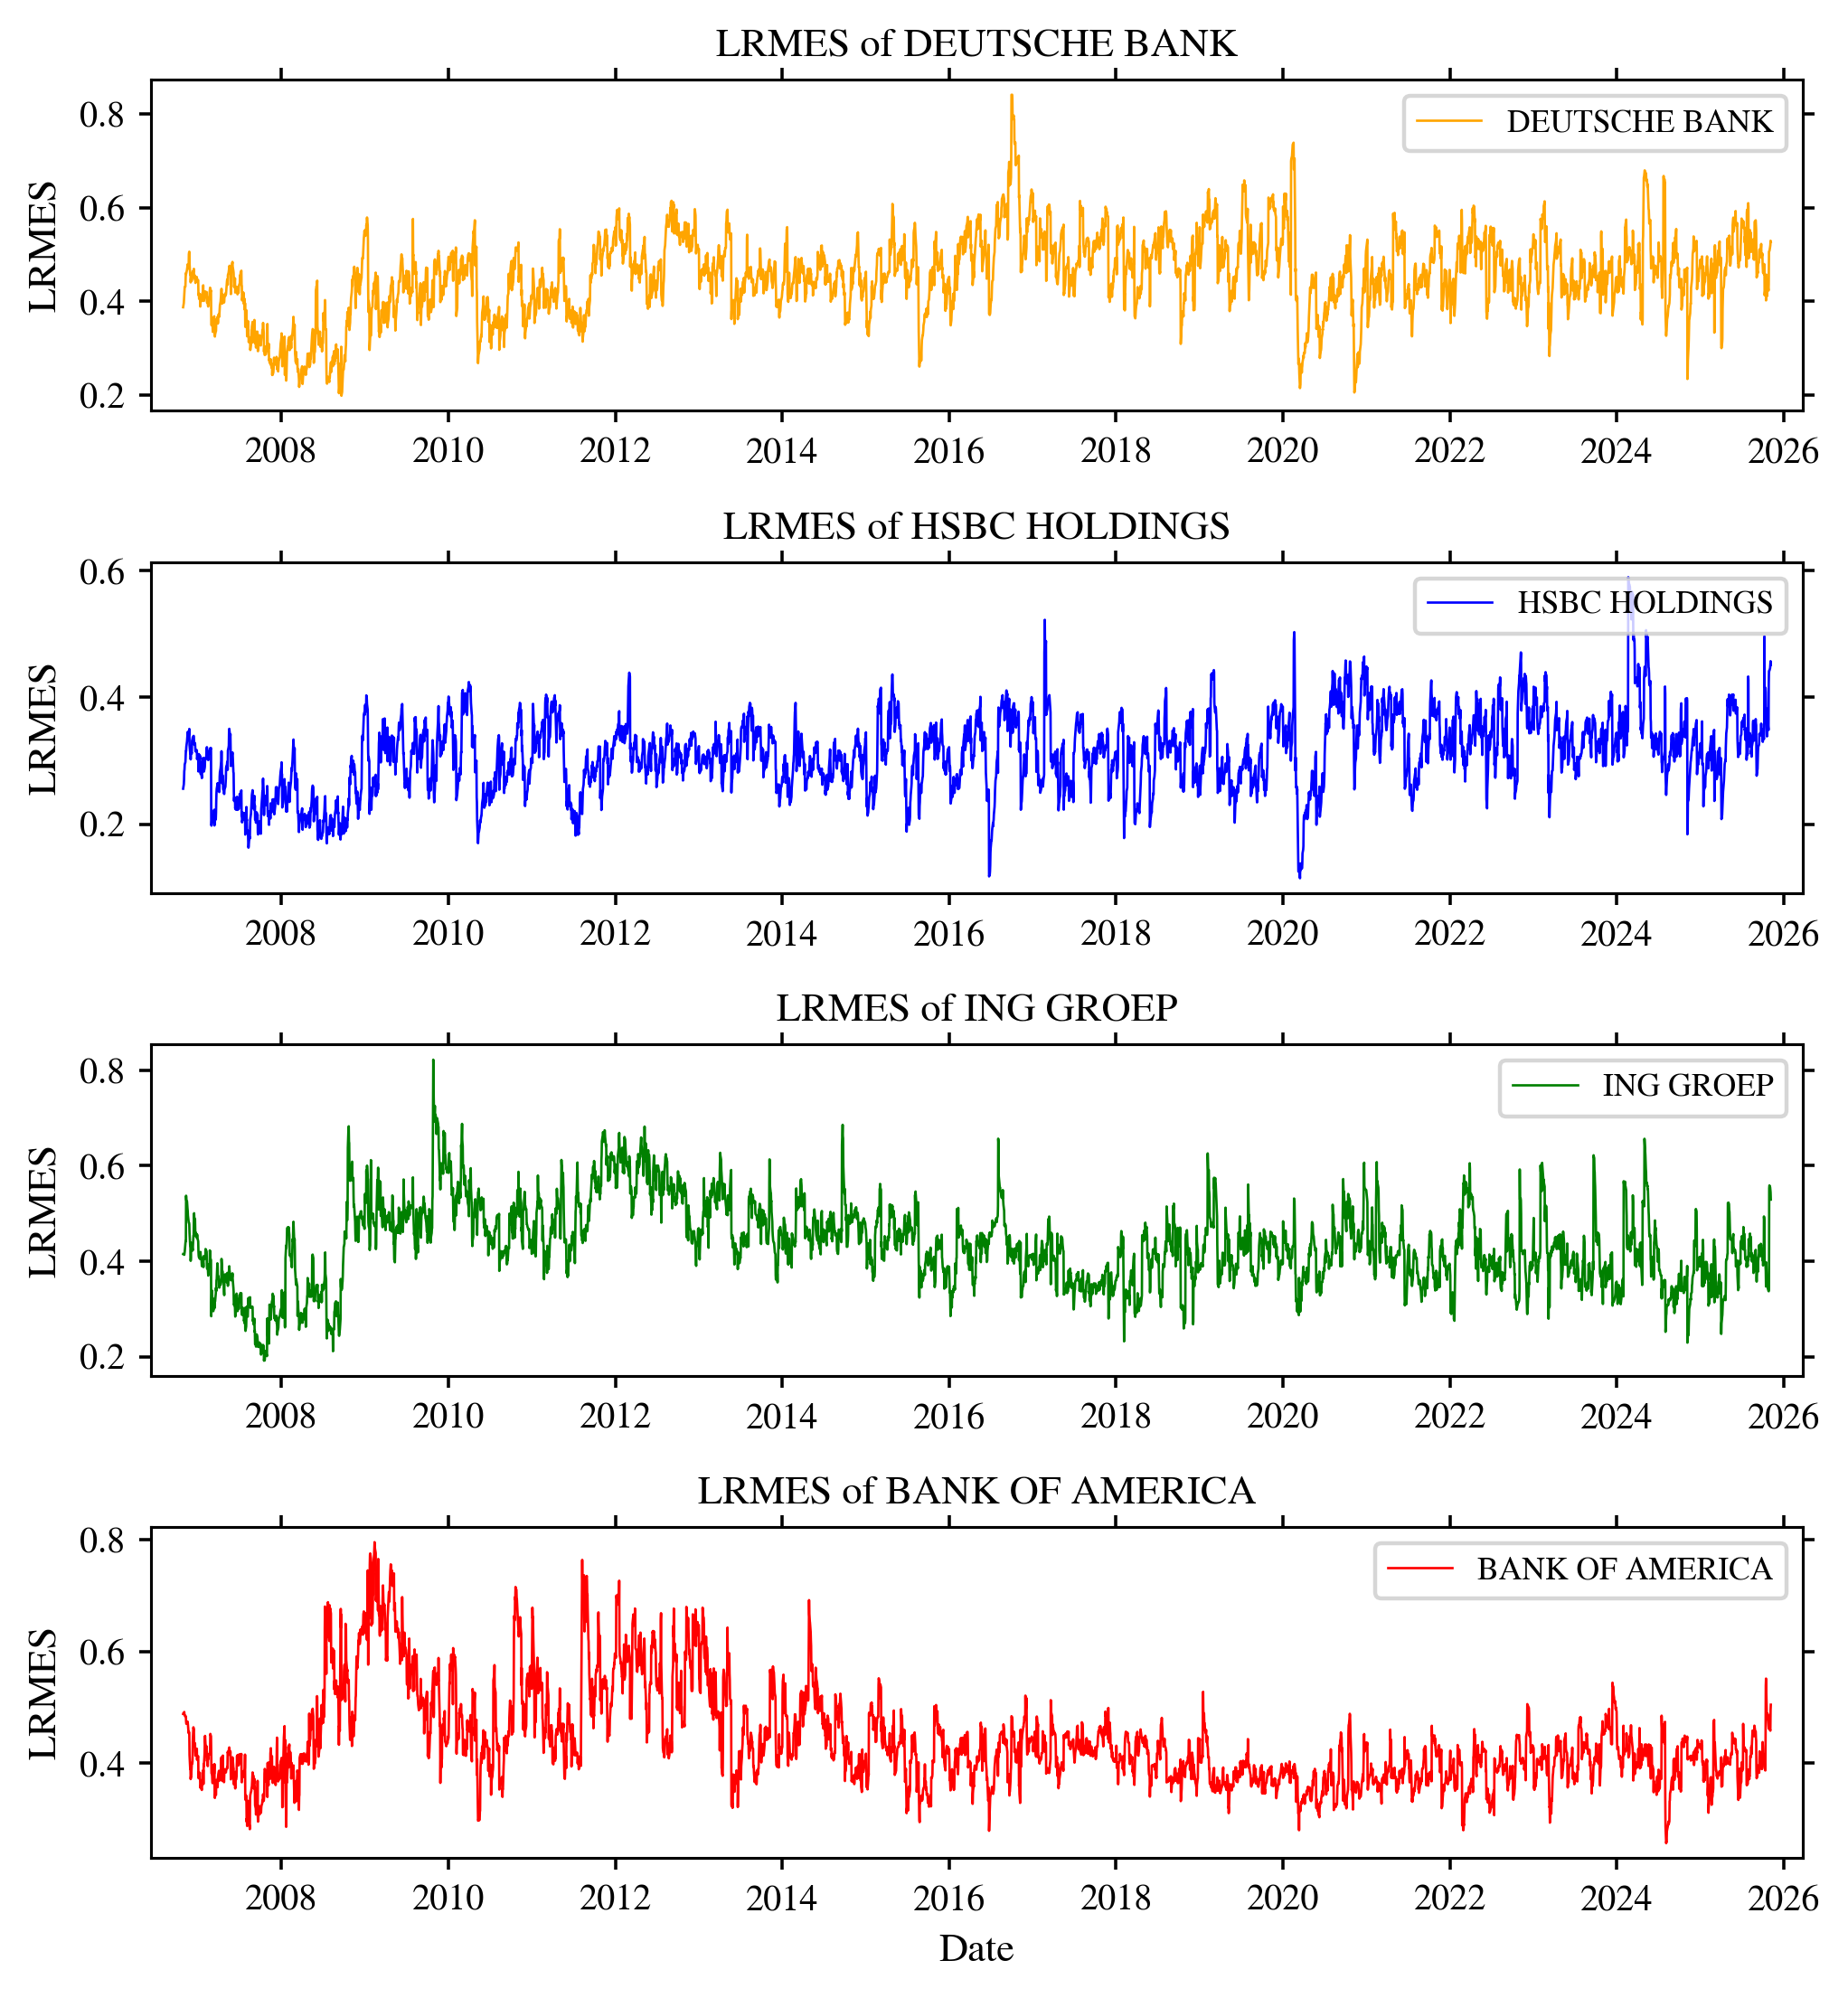

In [340]:
# Select the columns to plot selected bank LRMES
columns_to_plot = [7, 12, 18, 21]  # 0-based indexing
selected_banks = GSIBs_LRMES.columns[columns_to_plot]

colors = ["orange", "blue", "green", "red"]

# 4 stacked panels
fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),     # consistent with beta figures
    sharex=False
)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(
        GSIBs_LRMES.index,
        GSIBs_LRMES[bank],
        color=color,
        label=bank
    )

    ax.set_title(f"LRMES of {bank}", pad=6)
    ax.set_ylabel("LRMES")

    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

# X-axis ticks on all panels
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / "LRMES.pdf")
plt.show()


Correlate LRMES with GPR index

In [341]:
# Calculate correlation between GPR index and LRMES for selected banks
for bank in selected_banks:
    merged_data = pd.merge(GSIBs_LRMES[[bank]], gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data[bank].corr(merged_data['GPR'])
    print(f'Correlation between GPR index and LRMES of {bank}: {corr:.4f}')

Correlation between GPR index and LRMES of DEUTSCHE BANK: 0.1906
Correlation between GPR index and LRMES of HSBC HOLDINGS: 0.1888
Correlation between GPR index and LRMES of ING GROEP: -0.1504
Correlation between GPR index and LRMES of BANK OF AMERICA: -0.2133


Finally we are ready to apply the SRISK formula

In [342]:
# Set a capital ratio
k = 0.08

# Apply the SRISK formula, without max function because negative values are interesting as well for analysis with absorption capacity
GSIBs_SRISK = k * (GSIBs_liabilities + GSIBs_equity) - (1 - GSIBs_LRMES) * GSIBs_equity

# Print the first 10 rows and all columns of the G-SIBs SRISK DataFrame
print("SRISK for G-SIBs (first 10 rows and all columns):")
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print(GSIBs_SRISK.iloc[:10, :])

# Save the G-SIBs SRISK DataFrame to a CSV file
GSIBs_SRISK.to_csv('./Outputs/Dataframes/GSIBs_SRISK.csv')

SRISK for G-SIBs (first 10 rows and all columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  \
DATE                                                                           
2025-11-06               -32,568            30,382     56,610      2,307,533   
2025-11-05               -31,227            30,985     55,257      2,309,727   
2025-11-04               -30,499            31,205     52,132      2,310,039   
2025-11-03               -36,059            24,535     51,546      2,310,681   
2025-10-31               -38,260            23,785     50,942      2,304,393   
2025-10-30               -37,644            24,491     51,045      2,297,688   
2025-10-29               -37,377            25,054     51,162      2,297,756   
2025-10-28               -53,560            20,795     49,366      2,296,528   
2025-10-27               -53,161            20,423     49,362      2,296,894   
2025-10-24               -50,060            22,565     50,645      2,2

Plot SRISK (still in local currency)

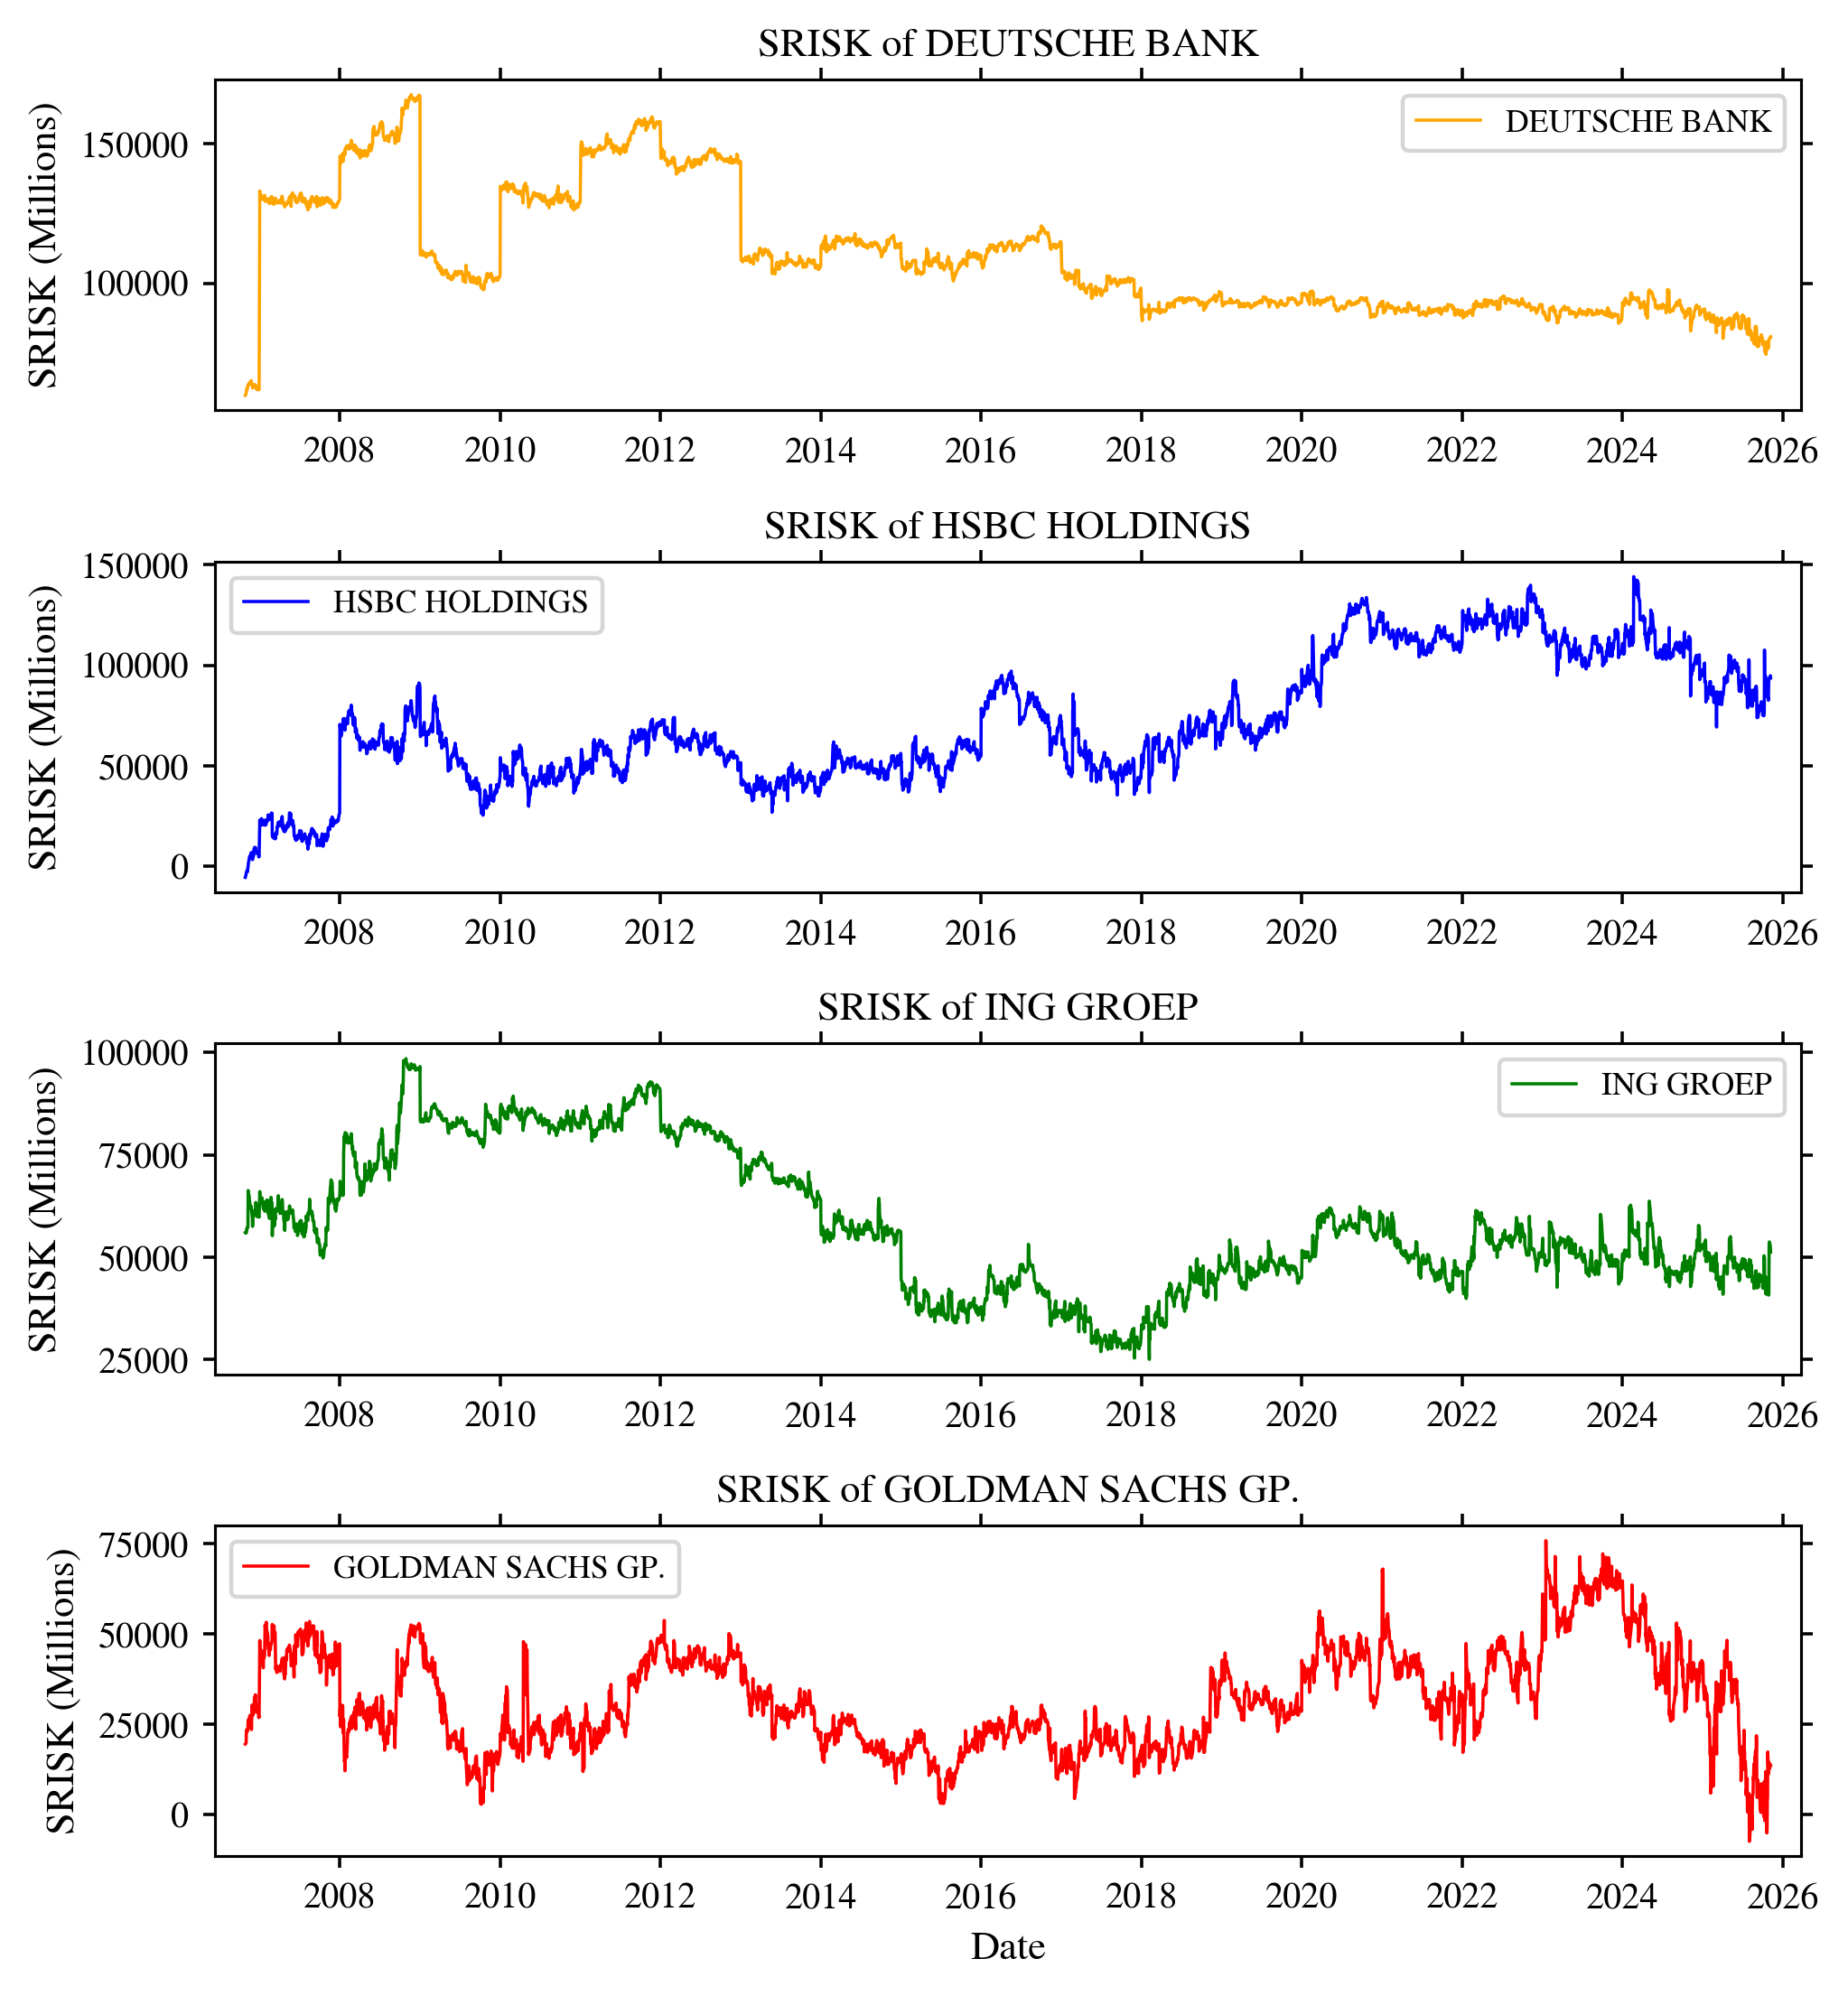

In [347]:
# Plot SRISK for selected G-SIBs in local currencies
# Select the columns to plot selected bank SRISK
columns_to_plot = [7, 12, 18, 22]  # 0-based indexing
selected_banks = GSIBs_SRISK.columns[columns_to_plot]

colors = ["orange", "blue", "green", "red"]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(
        GSIBs_SRISK.index,
        GSIBs_SRISK[bank],
        color=color,
        linewidth=0.8,
        label=bank
    )

    ax.set_title(f"SRISK of {bank}", pad=6)
    ax.set_ylabel("SRISK (Millions)")
    ax.margins(x=0.02)
    ax.grid(False)

    ax.legend(loc="best", frameon=True, fontsize=8)

# X-axis formatting
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
plt.show()


Converting all inputs to USD using exchange rates for better comparison

In [348]:
# Define start and end dates based on GSIBs_prices index
start_date = "2006-10-27"
end_date   = "2025-11-06"

# Define currency columns based on bank names
cad_cols = ['ROYAL BANK OF CANADA', 'TORONTO DOMINION']
chf_cols = ['UBS GROUP']
cny_cols = ['BANK OF CHINA', 'CHINA CON.BANK', 'INDL&COML.BOC.', 'BANK OF COMMS.']
jpy_cols = ['MITSUBISHI UFJ FINL.GP.', 'MIZUHO FINL.GP.', 'SUMITOMO MITSUI FINL.GP.']
eur_cols = ['DEUTSCHE BANK', 'BANCO SANTANDER', 'BNP PARIBAS', 'CREDIT AGRICOLE', 'SOCIETE GENERALE', 'ING GROEP']
gbp_cols = ['HSBC HOLDINGS', 'BARCLAYS', 'STANDARD CHARTERED']

# Extract exchange rates data via pandas_datareader
series = [
    "DEXCAUS",  # CAD per 1 USD
    "DEXUSEU",  # USD per 1 EUR
    "DEXUSUK",  # USD per 1 GBP
    "DEXSZUS",  # CHF per 1 USD
    "DEXCHUS",  # CNY per 1 USD
    "DEXJPUS",  # JPY per 1 USD
]
exchange_rates = web.DataReader(series, "fred", start_date, end_date)

# Align FX dates robustly (fill in chronological time, then restore your ordering)
idx = GSIBs_liabilities.index  # or union with assets/equity if you want: .union(GSIBs_assets.index).union(GSIBs_equity.index)

fx = (
    exchange_rates
    .sort_index()                      # ascending dates (old -> new)
    .reindex(idx.sort_values())        # align to ascending version of your index
    .ffill()                           # fill using most recent past FX rate
    .reindex(idx)                      # back to your original (descending) index order
)

# Print the first and last few rows of the exchange rates dataframe
print("Exchange Rates Data (first 5 rows):")
print(exchange_rates.head())
print("Exchange Rates Data (last 5 rows):")
print(exchange_rates.tail())

# Convert GSIBs_equity to USD
GSIBs_equity_usd = GSIBs_equity.copy()
GSIBs_equity_usd[cad_cols] = GSIBs_equity_usd[cad_cols].div(fx["DEXCAUS"], axis=0)
GSIBs_equity_usd[chf_cols] = GSIBs_equity_usd[chf_cols].div(fx["DEXSZUS"], axis=0)
GSIBs_equity_usd[cny_cols] = GSIBs_equity_usd[cny_cols].div(fx["DEXCHUS"], axis=0)
GSIBs_equity_usd[jpy_cols] = GSIBs_equity_usd[jpy_cols].div(fx["DEXJPUS"], axis=0)
GSIBs_equity_usd[eur_cols] = GSIBs_equity_usd[eur_cols].mul(fx["DEXUSEU"], axis=0)
GSIBs_equity_usd[gbp_cols] = GSIBs_equity_usd[gbp_cols].mul(fx["DEXUSUK"], axis=0)

# Convert GSIBs_liabilities to USD
GSIBs_liabilities_usd = GSIBs_liabilities.copy()
GSIBs_liabilities_usd[cad_cols] = GSIBs_liabilities_usd[cad_cols].div(fx["DEXCAUS"], axis=0)
GSIBs_liabilities_usd[chf_cols] = GSIBs_liabilities_usd[chf_cols].div(fx["DEXSZUS"], axis=0)
GSIBs_liabilities_usd[cny_cols] = GSIBs_liabilities_usd[cny_cols].div(fx["DEXCHUS"], axis=0)
GSIBs_liabilities_usd[jpy_cols] = GSIBs_liabilities_usd[jpy_cols].div(fx["DEXJPUS"], axis=0)
GSIBs_liabilities_usd[eur_cols] = GSIBs_liabilities_usd[eur_cols].mul(fx["DEXUSEU"], axis=0)
GSIBs_liabilities_usd[gbp_cols] = GSIBs_liabilities_usd[gbp_cols].mul(fx["DEXUSUK"], axis=0)

# Convert GSIBs_assets to USD
GSIBs_assets_usd = GSIBs_assets.copy()
GSIBs_assets_usd[cad_cols] = GSIBs_assets_usd[cad_cols].div(fx["DEXCAUS"], axis=0)
GSIBs_assets_usd[chf_cols] = GSIBs_assets_usd[chf_cols].div(fx["DEXSZUS"], axis=0)
GSIBs_assets_usd[cny_cols] = GSIBs_assets_usd[cny_cols].div(fx["DEXCHUS"], axis=0)
GSIBs_assets_usd[jpy_cols] = GSIBs_assets_usd[jpy_cols].div(fx["DEXJPUS"], axis=0)
GSIBs_assets_usd[eur_cols] = GSIBs_assets_usd[eur_cols].mul(fx["DEXUSEU"], axis=0)
GSIBs_assets_usd[gbp_cols] = GSIBs_assets_usd[gbp_cols].mul(fx["DEXUSUK"], axis=0)

# Print the first 10 rows and all columns of the converted dataframes
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print("GSIBs_liabilities in USD (first 10 rows and all columns):")
    print(GSIBs_liabilities_usd.iloc[:10, :])
    print("GSIBs_assets in USD (first 10 rows and all columns):")
    print(GSIBs_assets_usd.iloc[:10, :])



Exchange Rates Data (first 5 rows):
            DEXCAUS  DEXUSEU  DEXUSUK  DEXSZUS  DEXCHUS  DEXJPUS
DATE                                                            
2006-10-27     1.12     1.27     1.90     1.25     7.89   117.61
2006-10-30     1.12     1.27     1.90     1.25     7.87   117.38
2006-10-31     1.12     1.28     1.91     1.24     7.88   116.82
2006-11-01     1.13     1.28     1.91     1.24     7.87   117.01
2006-11-02     1.14     1.28     1.91     1.24     7.87   117.12
Exchange Rates Data (last 5 rows):
            DEXCAUS  DEXUSEU  DEXUSUK  DEXSZUS  DEXCHUS  DEXJPUS
DATE                                                            
2025-10-31     1.40     1.15     1.31     0.80     7.12   154.05
2025-11-03     1.40     1.15     1.31     0.81     7.12   154.13
2025-11-04     1.41     1.15     1.30     0.81     7.13   153.55
2025-11-05     1.41     1.15     1.31     0.81     7.13   154.11
2025-11-06     1.41     1.15     1.31     0.81     7.12   152.97
GSIBs_liabilities i

# SRISK in USD

Now that we have everything in the same currency, we can actually start comparing G-SIBs and looking at nSRISK and try to find other interesting statistics.

In [366]:
# Compute SRISK in USD for three different capital ratios, with and without the max operator

k_values = [0.055, 0.08, 0.10]

# Version without max (as in the original code)
GSIBs_SRISK_no_max = {}
for k in k_values:
    GSIBs_SRISK_no_max[k] = k * (GSIBs_liabilities_usd + GSIBs_equity_usd) - (1 - GSIBs_LRMES) * GSIBs_equity_usd
    GSIBs_SRISK_no_max[k].to_csv(f'./Outputs/Dataframes/SRISK_usd_no_max_k{k:.3f}.csv')

# Version with max operator (standard SRISK)
GSIBs_SRISK_with_max = {}
for k in k_values:
    GSIBs_SRISK_with_max[k] = np.maximum(0, k * (GSIBs_liabilities_usd + GSIBs_equity_usd) - (1 - GSIBs_LRMES) * GSIBs_equity_usd)
    GSIBs_SRISK_with_max[k].to_csv(f'./Outputs/Dataframes/SRISK_usd_with_max_k{k:.3f}.csv')

Aggregate SRISK, when we do this we do like to have the max{0,...} operator

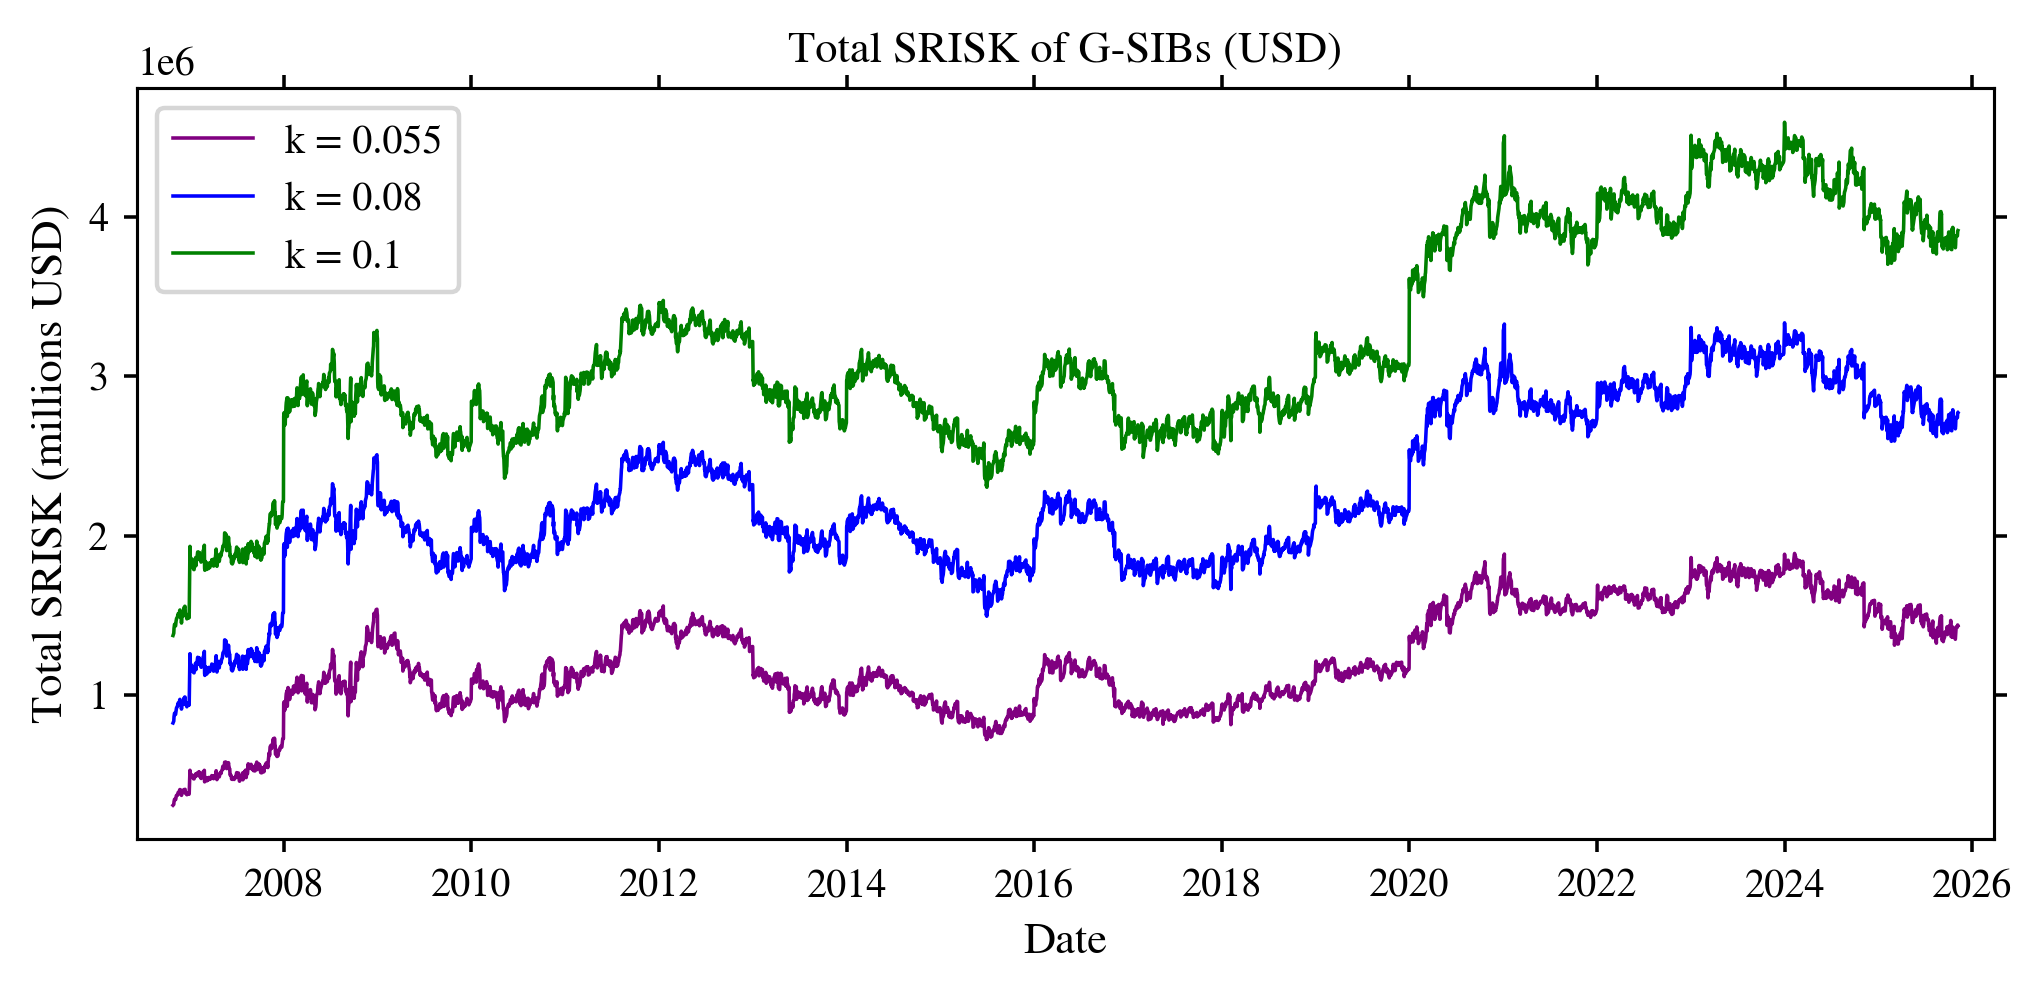

In [367]:
# Aggregate SRISK across all G-SIBs in USD
GSIBs_SRISK_total_usd = {
    k: GSIBs_SRISK_with_max[k].sum(axis=1)
    for k in k_values
}

colors = ["purple", "blue", "green"]

fig, ax = plt.subplots(figsize=FIG_FULL)

for k, color in zip(k_values, colors):
    ax.plot(
        GSIBs_SRISK_total_usd[k].index,
        GSIBs_SRISK_total_usd[k],
        label=f"k = {k}",
        linewidth=0.8,
        color=color
    )

ax.set_title("Total SRISK of G-SIBs (USD)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Total SRISK (millions USD)")

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_total_srisk_gsibs_usd.pdf")
plt.show()

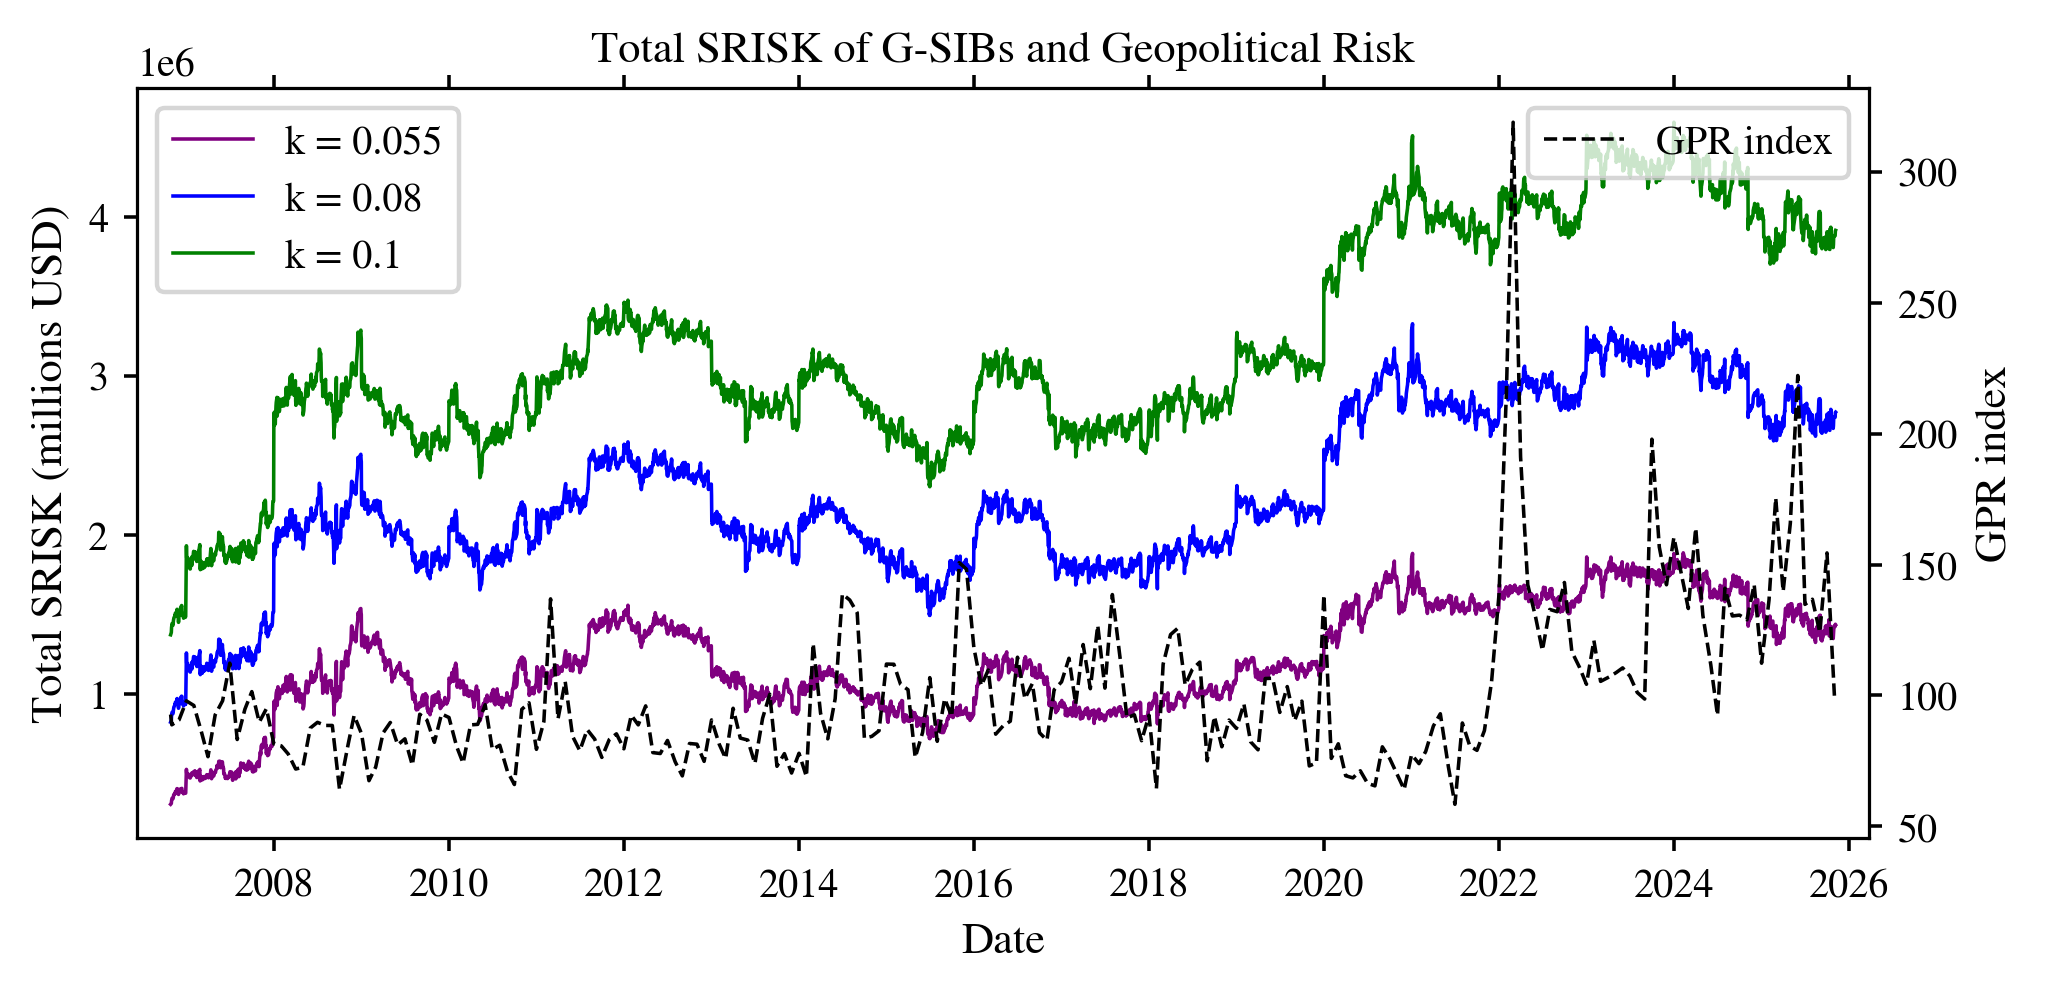

In [368]:
# Plot the aggregate SRISK for different capital ratios with GPR index on double axis
colors = ["purple", "blue", "green"]

fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()

# Left axis: total SRISK
for k, color in zip(k_values, colors):
    ax1.plot(
        GSIBs_SRISK_total_usd[k].index,
        GSIBs_SRISK_total_usd[k],
        label=f"k = {k}",
        color=color,
        linewidth=0.8
    )

# Right axis: GPR index
ax2.plot(
    gpr_data.index,
    gpr_data["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR index"
)

ax1.set_title("Total SRISK of G-SIBs and Geopolitical Risk", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("Total SRISK (millions USD)")
ax2.set_ylabel("GPR index")

# Legends (kept separate for clarity)
ax1.legend(loc="upper left", frameon=True, fontsize=9)
ax2.legend(loc="upper right", frameon=True, fontsize=9)

ax1.grid(False)
ax1.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_total_srisk_gsibs_with_gpr.pdf")
plt.show()


In [369]:
# Check the correlations between aggregate SRISK and GPR index for each k
for k in k_values:
    merged_data = pd.merge(GSIBs_SRISK_total_usd[k].rename('Total_SRISK'), gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data['Total_SRISK'].corr(merged_data['GPR'])
    print(f'Correlation between total SRISK (k={k}) of G-SIBs and GPR index: {corr:.4f}')
    
# Check the correlations between aggregate SRISK for different capital ratios
for i in range(len(k_values)):
    for j in range(i + 1, len(k_values)):
        k1 = k_values[i]
        k2 = k_values[j]
        corr = GSIBs_SRISK_total_usd[k1].corr(GSIBs_SRISK_total_usd[k2])
        print(f'Correlation between total SRISK (k={k1}) and total SRISK (k={k2}): {corr:.4f}')
    

Correlation between total SRISK (k=0.055) of G-SIBs and GPR index: 0.2890
Correlation between total SRISK (k=0.08) of G-SIBs and GPR index: 0.3376
Correlation between total SRISK (k=0.1) of G-SIBs and GPR index: 0.3763
Correlation between total SRISK (k=0.055) and total SRISK (k=0.08): 0.9890
Correlation between total SRISK (k=0.055) and total SRISK (k=0.1): 0.9736
Correlation between total SRISK (k=0.08) and total SRISK (k=0.1): 0.9949


Compute a table of the SRISK in descending order for certain years

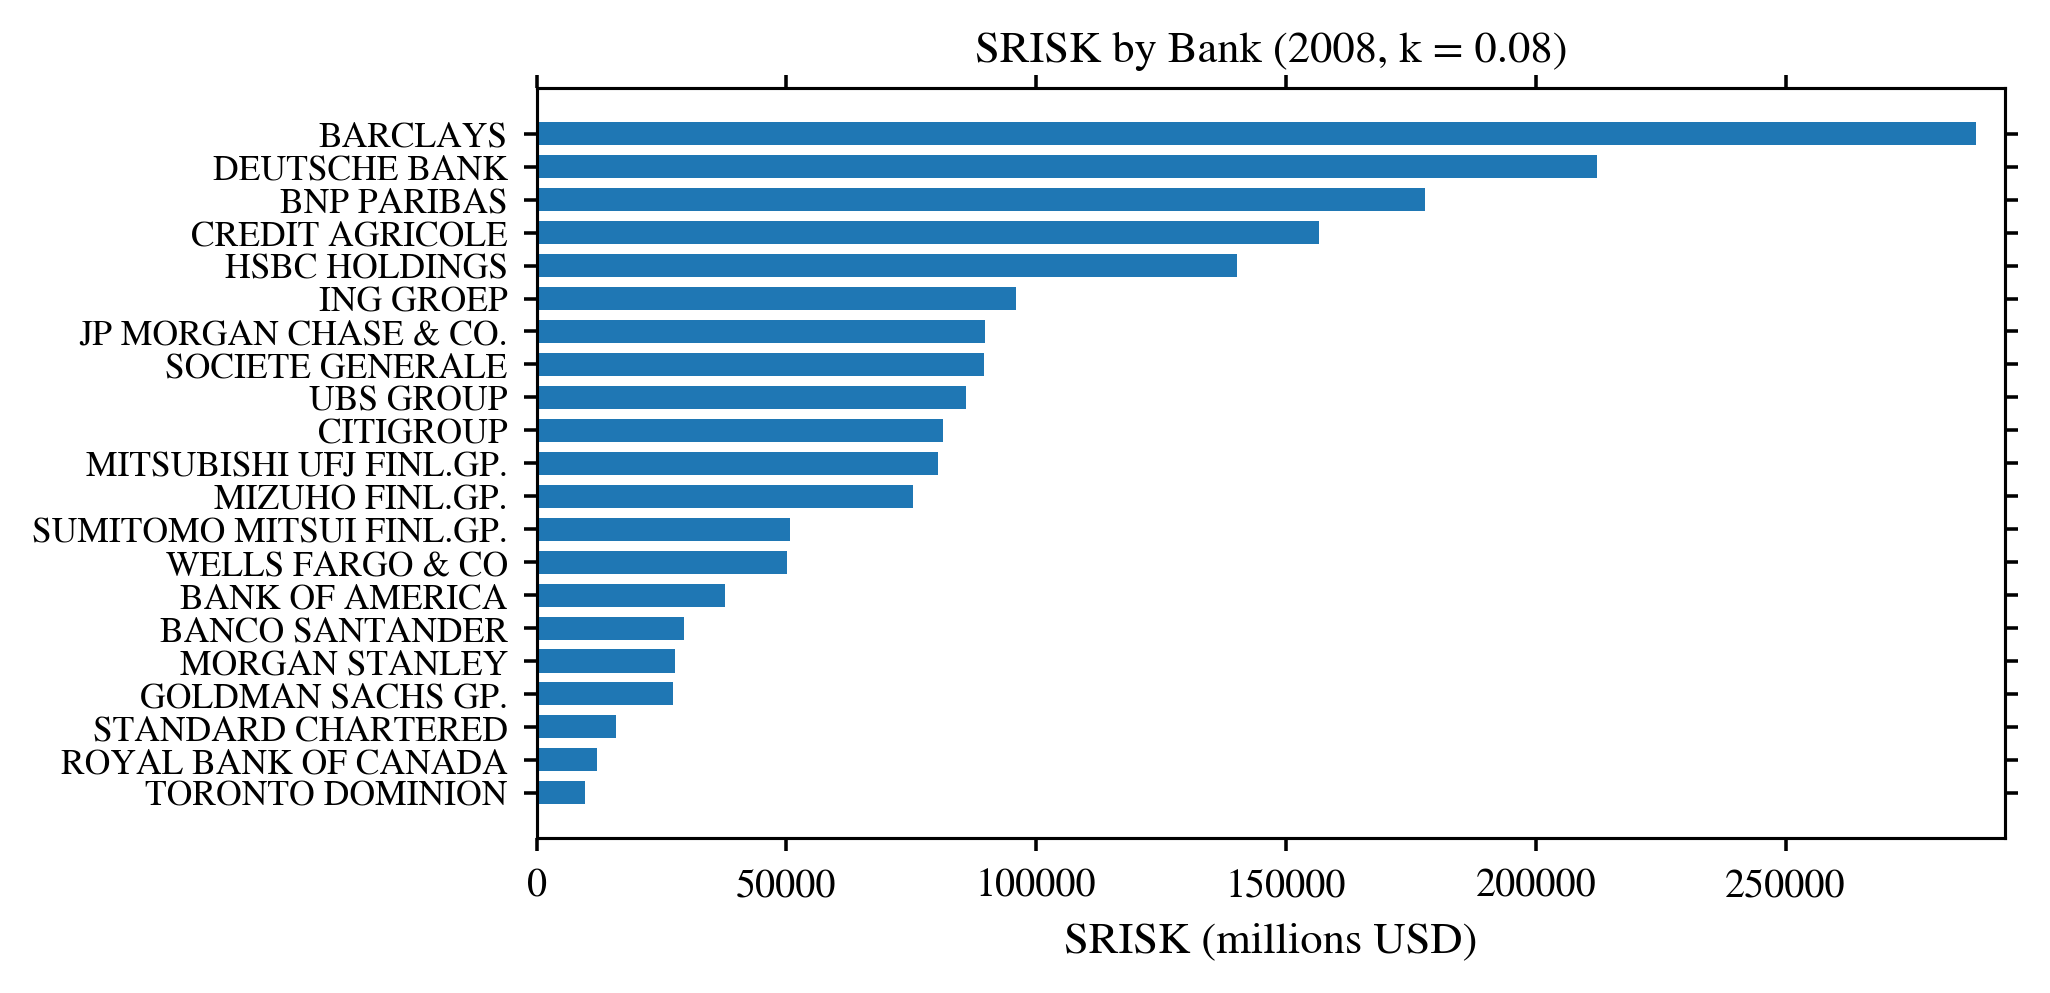

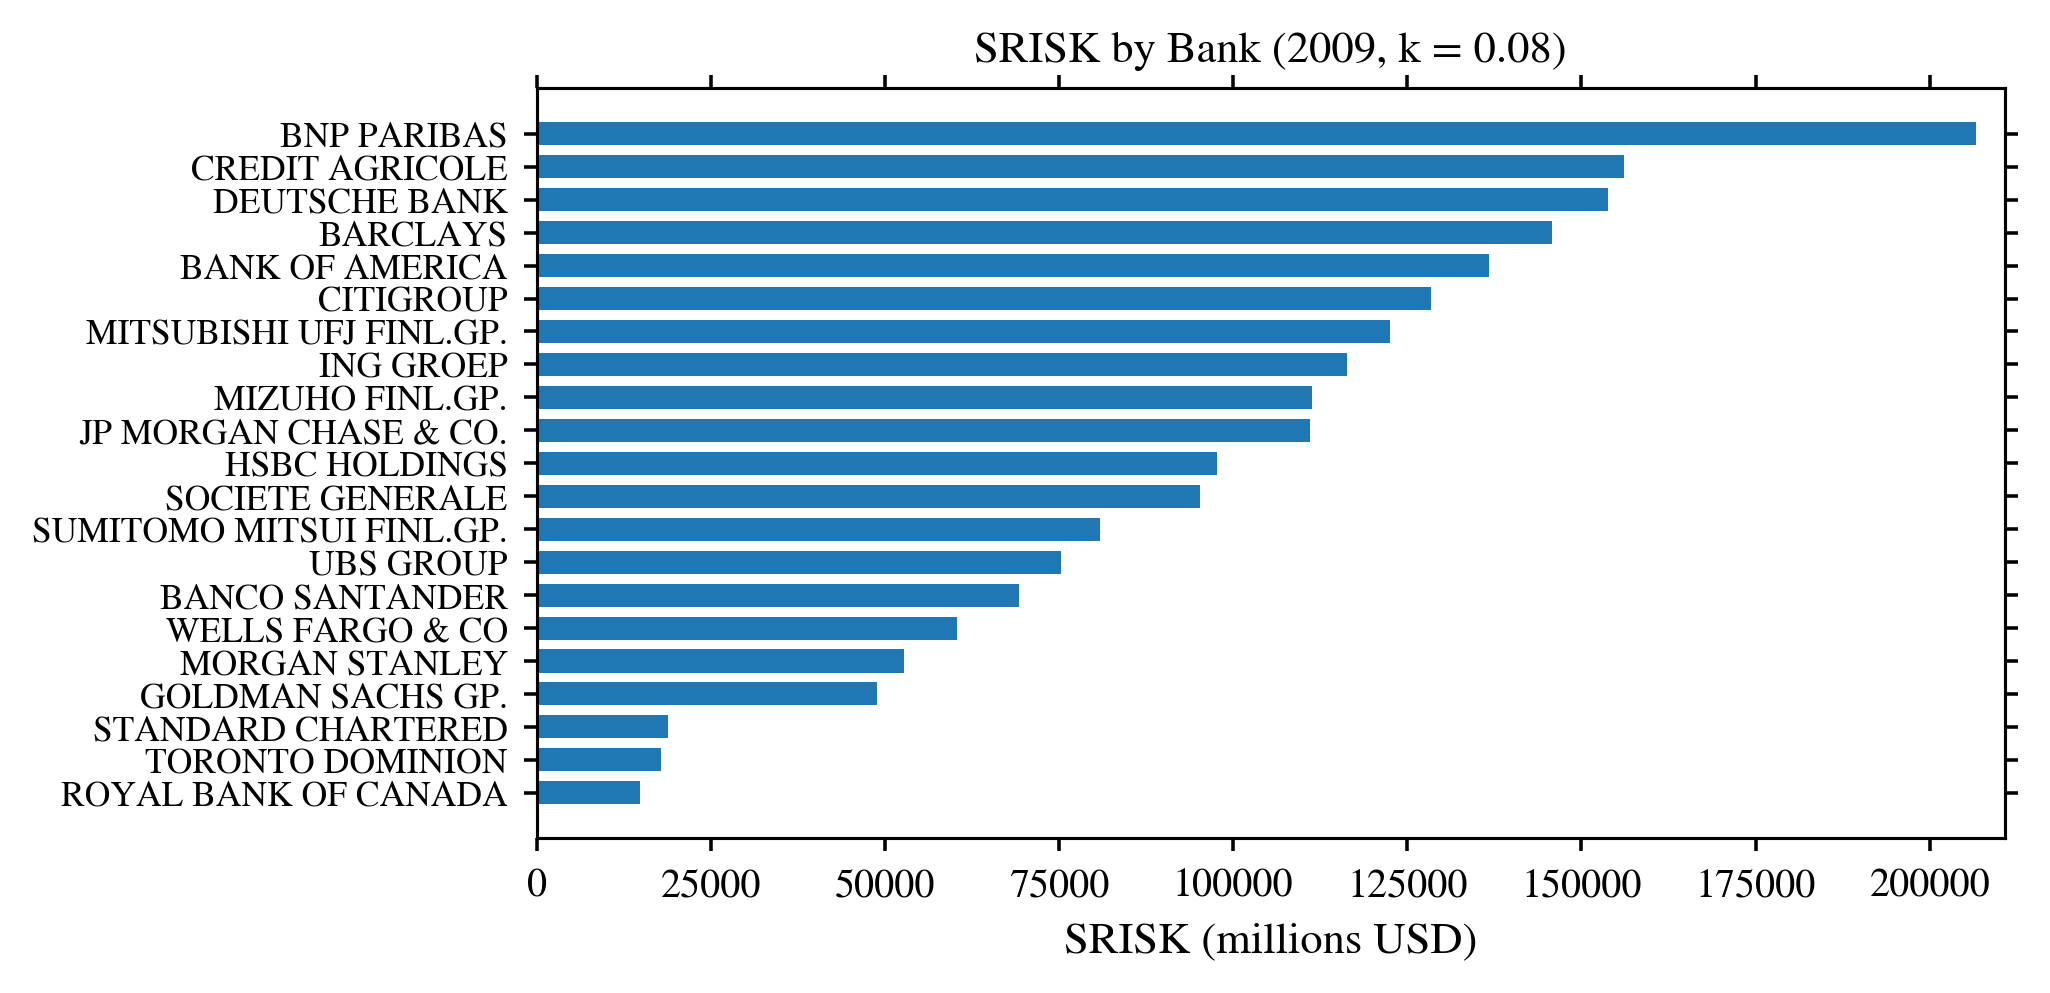

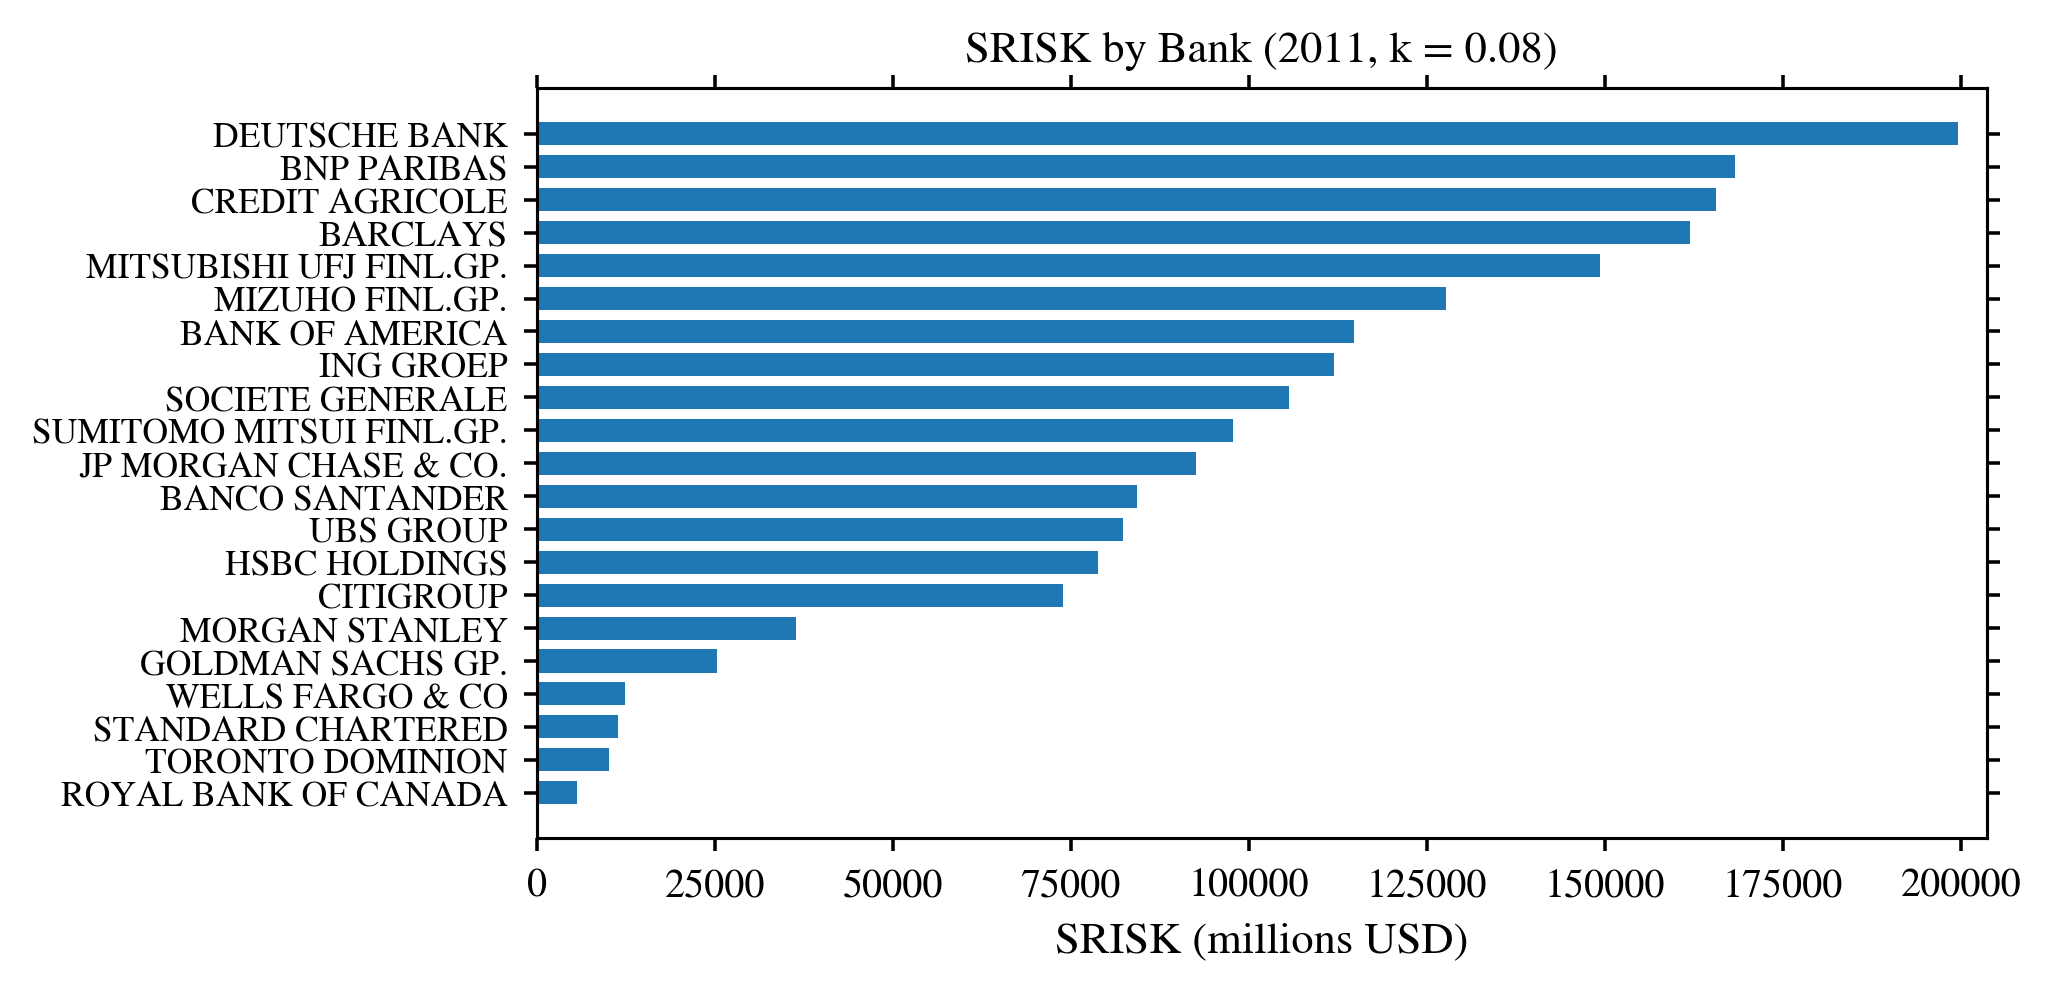

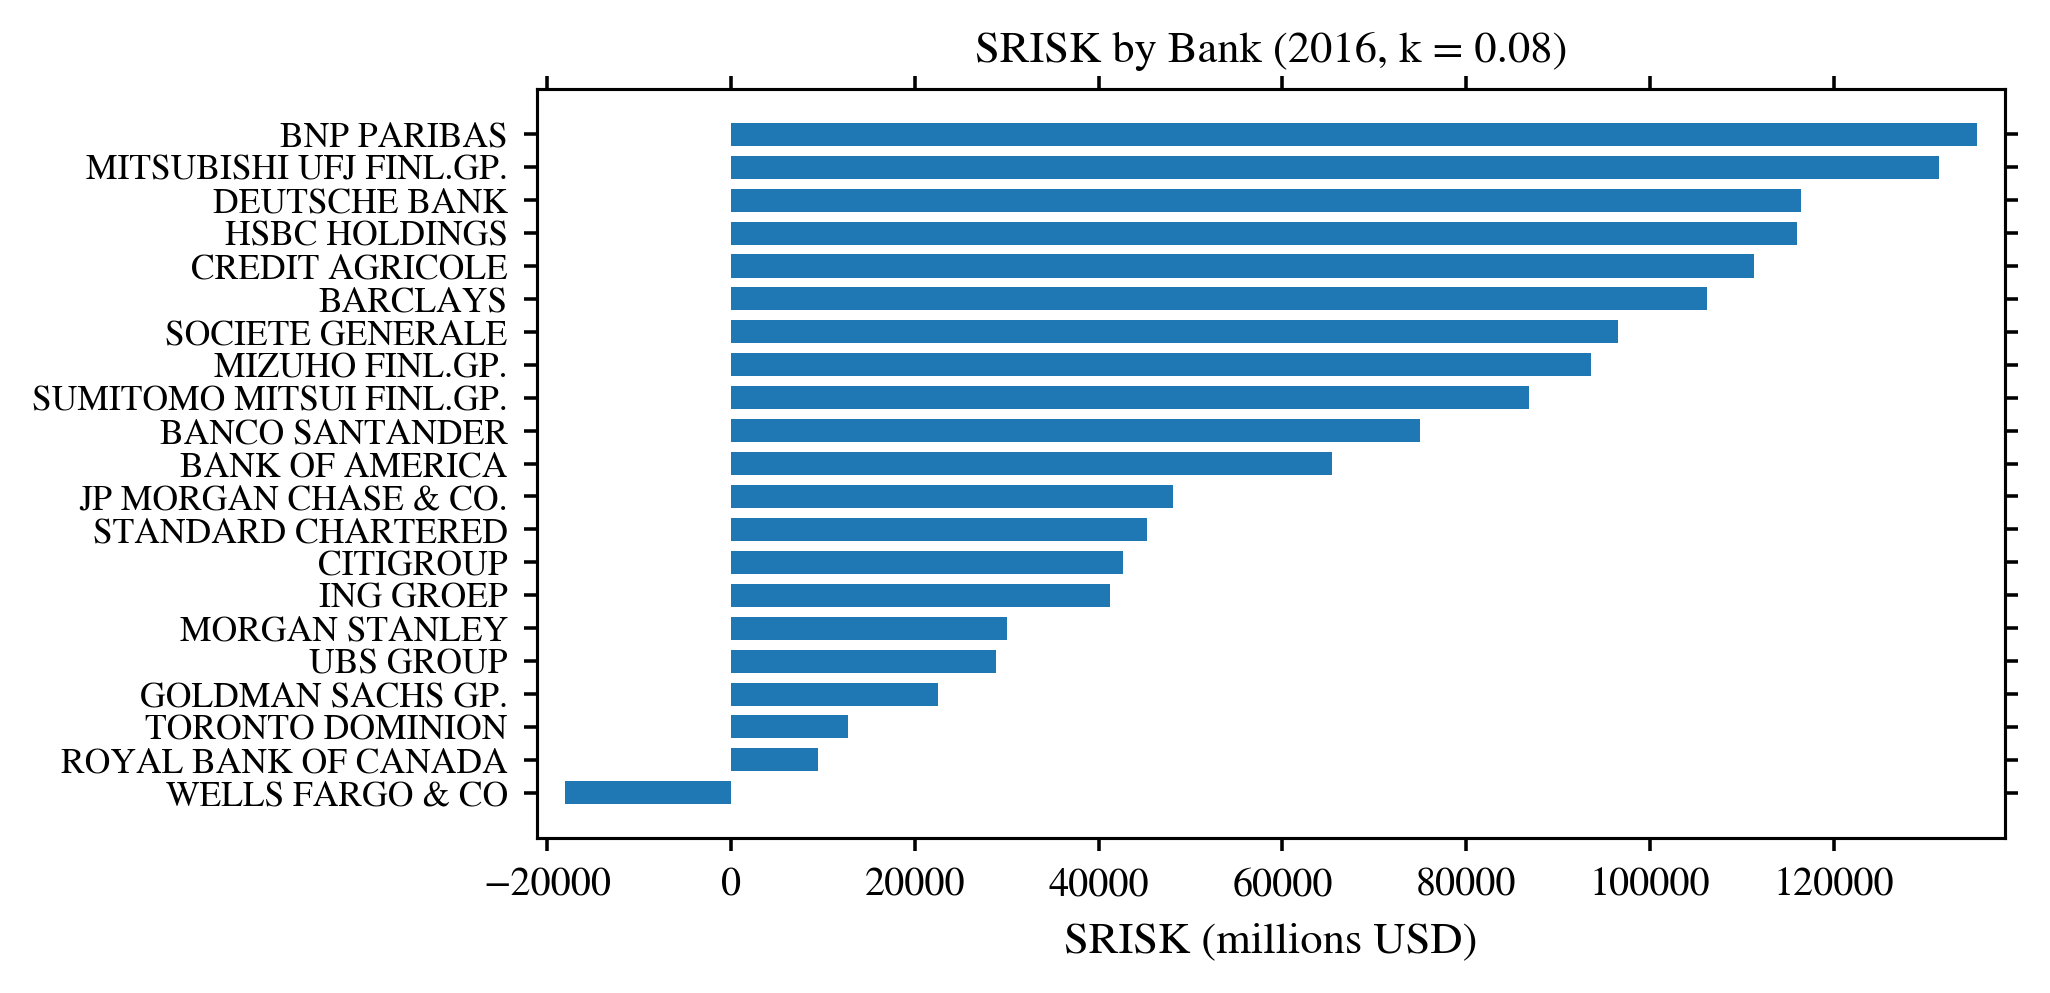

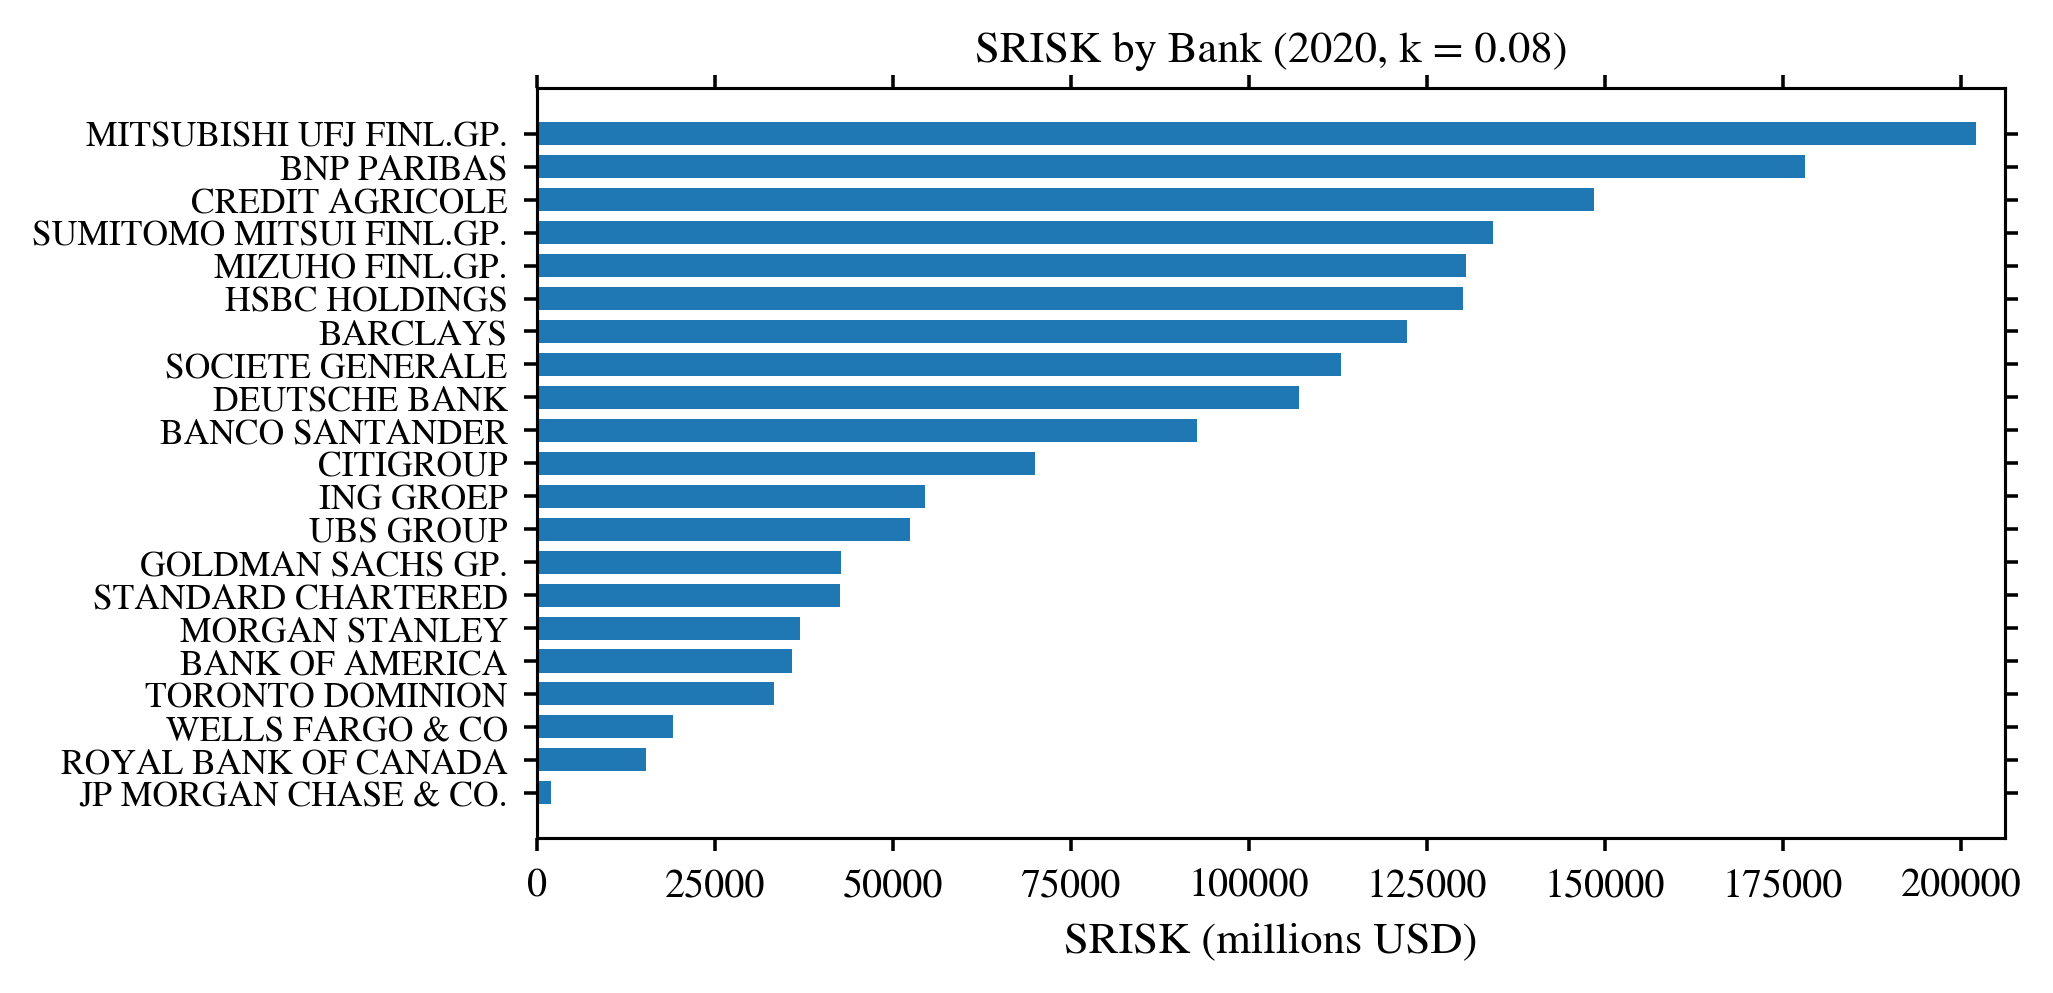

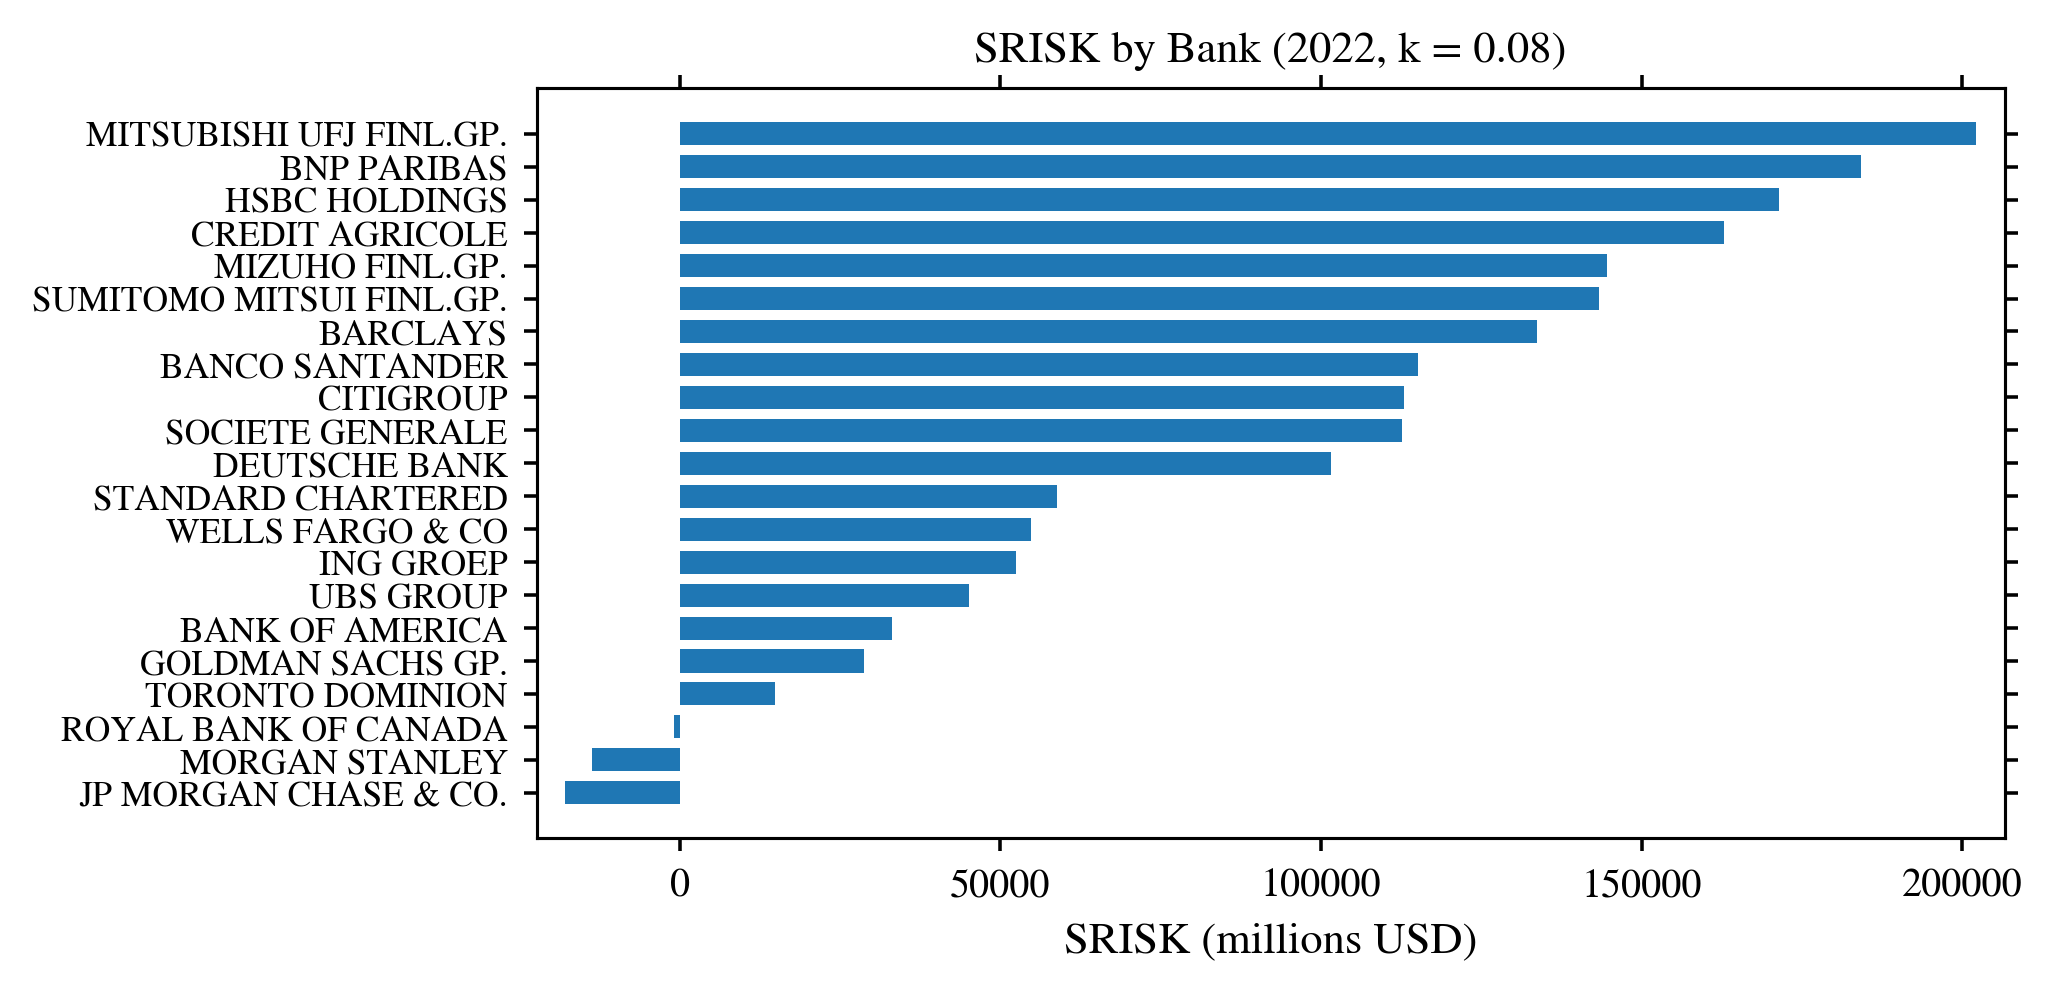

In [ ]:
# Plot horizontal bar charts of SRISK by bank for selected years
years_of_interest = [2008, 2009, 2011, 2016, 2020, 2022]

# excluded_banks = ["STATE STREET","BANK OF NEW YORK MELLON","BANK OF COMMS.","BANK OF CHINA",
#     "CHINA CON.BANK",
#     "INDL&COML.BOC.",
# ]

k_bar = 0.08  # pick which capital ratio you want for the bar charts

# Optional cap for readability (data are in "millions")
# 1e6 millions = 1 trillion
cap_millions = 1e6  # set None to disable

srisk_df = GSIBs_SRISK_[k_bar].copy()
srisk_df.index = pd.to_datetime(srisk_df.index)

for year in years_of_interest:
    year_mask = srisk_df.index.year == year
    if not year_mask.any():
        print(f"No SRISK data available for the year {year}.\n")
        continue

    # Take last available observation in that calendar year
    srisk_for_year = srisk_df.loc[year_mask].iloc[-1].dropna()

    # Exclude specified banks
    srisk_for_year = srisk_for_year.drop(labels=excluded_banks, errors="ignore")

    # Optional: cap extreme outliers
    if cap_millions is not None:
        srisk_for_year = srisk_for_year[srisk_for_year < cap_millions]

    # Sort (largest at top in a horizontal bar chart)
    srisk_sorted = srisk_for_year.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=FIG_FULL)
    ax.barh(srisk_sorted.index, srisk_sorted.values, height=0.7)

    ax.set_title(f"SRISK by Bank ({year}, k = {k_bar})", pad=6)
    ax.set_xlabel("SRISK (millions USD)")
    ax.set_ylabel("")

    ax.grid(False)
    ax.margins(x=0.02)
    ax.tick_params(axis="y", labelsize=8)

    fig.tight_layout()
    plt.show()

